# Dyad-Specific Multimodal Affective Dynamics — Analysis Notebook


## 1. Setup and data


In [ ]:
#@title Install dependencies and Seamless Interaction package
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/seamless_interaction_repo')
if not REPO.exists():
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        'https://github.com/facebookresearch/seamless_interaction.git',
        str(REPO),
    ])

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO)])
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib',
    'tqdm', 'joblib', 'soundfile', 'requests', 'huggingface_hub',
])

SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


fs_file = SRC / 'seamless_interaction' / 'fs.py'
if fs_file.exists():
    text = fs_file.read_text(encoding='utf-8')
    old = 'data = np.load(tmp_file_path)'
    new = 'data = np.load(tmp_file_path, allow_pickle=True)'
    if old in text and new not in text:
        fs_file.write_text(text.replace(old, new), encoding='utf-8')
        print('Patched the official loader for trusted object arrays.')

print('Installation ready.')


Patched the official loader for trusted object arrays.
Installation ready.


In [ ]:
#@title Imports and global configuration
from __future__ import annotations

import copy, json, math, random, re, shutil, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist, jensenshannon
from scipy.stats import wilcoxon, binomtest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    silhouette_score, adjusted_rand_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from seamless_interaction.fs import SeamlessInteractionFS, DatasetConfig

warnings.filterwarnings('ignore', category=RuntimeWarning)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

@dataclass
class Config:

    label: str = 'improvised'
    split: str = 'dev'
    n_pairs: int = 30
    preferred_vendors_only: bool = True
    num_workers: int = 1


    assumed_fps: float = 30.0
    window_seconds: float = 2.0
    stride_seconds: float = 0.5
    min_valid_fraction: float = 0.70


    selected_k: int = 3
    crossfit_folds: int = 5
    primary_group_column: str = 'pair_id'


    pmci_k: int = 16
    pmci_tau: float = 0.25
    pmci_hidden: int = 96
    pmci_embed: int = 96
    pmci_epochs: int = 12
    pmci_batch_size: int = 64
    pmci_lr: float = 1e-3
    pmci_weight_decay: float = 1e-4
    pmci_window_frames: int = 12
    pmci_stride_frames: int = 12
    pmci_test_fraction: float = 0.30


    precursor_seconds: tuple = (2.0, 4.0, 6.0, 8.0)
    min_event_separation_seconds: float = 8.0
    bootstrap_iterations: int = 5000


    run_naturalistic_transfer: bool = True
    transfer_label: str = 'naturalistic'
    transfer_split: str = 'dev'
    transfer_n_pairs: int = 20

    random_state: int = SEED

CFG = Config()

ROOT = Path('/content/article3_q1_additional_experiments')
DATA_ROOT = ROOT / 'data_improvised'
TRANSFER_ROOT = ROOT / 'data_naturalistic'
PROCESSED = ROOT / 'processed'
RESULTS = ROOT / 'results'
MODELS = ROOT / 'models'
FIGURES = ROOT / 'figures'
for p in [ROOT, DATA_ROOT, TRANSFER_ROOT, PROCESSED, RESULTS, MODELS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(json.dumps(asdict(CFG), indent=2, default=list))
print('Device:', DEVICE)
print('Outputs:', ROOT)


{
  "label": "improvised",
  "split": "dev",
  "n_pairs": 30,
  "preferred_vendors_only": true,
  "num_workers": 1,
  "assumed_fps": 30.0,
  "window_seconds": 2.0,
  "stride_seconds": 0.5,
  "min_valid_fraction": 0.7,
  "selected_k": 3,
  "crossfit_folds": 5,
  "primary_group_column": "pair_id",
  "pmci_k": 16,
  "pmci_tau": 0.25,
  "pmci_hidden": 96,
  "pmci_embed": 96,
  "pmci_epochs": 12,
  "pmci_batch_size": 64,
  "pmci_lr": 0.001,
  "pmci_weight_decay": 0.0001,
  "pmci_window_frames": 12,
  "pmci_stride_frames": 12,
  "pmci_test_fraction": 0.3,
  "precursor_seconds": [
    2.0,
    4.0,
    6.0,
    8.0
  ],
  "min_event_separation_seconds": 8.0,
  "bootstrap_iterations": 5000,
  "run_naturalistic_transfer": true,
  "transfer_label": "naturalistic",
  "transfer_split": "dev",
  "transfer_n_pairs": 20,
  "random_state": 42
}
Device: cuda
Outputs: /content/article3_q1_additional_experiments


In [ ]:
#@title Official data downloader
def download_complete_pairs(label: str, split: str, n_pairs: int, root: Path, seed: int):
    config = DatasetConfig(
        label=label,
        split=split,
        preferred_vendors_only=CFG.preferred_vendors_only,
        local_dir=root,
        seed=seed,
        num_workers=CFG.num_workers,
    )
    fs = SeamlessInteractionFS(config=config)
    pairs = fs.get_interaction_pairs(num_pairs=n_pairs)
    if not pairs:
        raise RuntimeError(f'No interaction pairs found for {label}/{split}.')

    ok, failed = [], []
    file_ids = [fid for pair in pairs for fid in pair]
    for fid in tqdm(file_ids, desc=f'Download {label}/{split}'):
        try:
            fs.gather_file_id_data_from_s3(
                fid, num_workers=CFG.num_workers, local_dir=root
            )
            ok.append(fid)
        except Exception as exc:
            failed.append({'file_id': fid, 'error': f'{type(exc).__name__}: {exc}'})

    print(f'{label}/{split}: requested={len(file_ids)}, downloaded={len(ok)}, failed={len(failed)}')
    if failed:
        display(pd.DataFrame(failed).head(20))
    return fs, pairs, pd.DataFrame(failed)

primary_fs, primary_pairs, primary_download_failures = download_complete_pairs(
    CFG.label, CFG.split, CFG.n_pairs, DATA_ROOT, CFG.random_state
)


Download improvised/dev:   0%|          | 0/60 [00:00<?, ?it/s]

ERROR:seamless_interaction.fs:Failed to download https://dl.fbaipublicfiles.com/seamless_interaction/improvised/dev/movement_v4/emotion_arousal/V00_S2025_I00001082_P1282A.npy: <urlopen error [Errno 104] Connection reset by peer>


improvised/dev: requested=60, downloaded=60, failed=0


In [ ]:
#@title Manifest and identity helpers
def find_local_file(file_id: str, suffix: str, root: Path) -> Optional[Path]:
    matches = list(root.rglob(f'{file_id}{suffix}'))
    return matches[0] if matches else None


def interaction_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:-1])


def participant_id_from_file_id(file_id: str) -> str:
    match = re.search(r'_(P[^_]+)$', file_id)
    if match is None:
        raise ValueError(f'Cannot parse participant ID from {file_id}')
    return match.group(1)


def session_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:2])


def prompt_id_from_file_id(file_id: str) -> str:
    parts = file_id.split('_')
    return parts[2] if len(parts) >= 3 else 'unknown'


def canonical_pair_id(participants) -> str:
    return '__'.join(sorted({str(x) for x in participants if pd.notna(x)}))


def build_raw_manifest(pairs, root: Path, label: str, split: str) -> pd.DataFrame:
    rows = []
    for pair_idx, pair in enumerate(pairs):
        pair_id = canonical_pair_id(participant_id_from_file_id(fid) for fid in pair)
        for fid in pair:
            row = {
                'pair_idx': pair_idx,
                'dataset_label': label,
                'dataset_split': split,
                'interaction_key': interaction_key_from_file_id(fid),
                'recording_session_id': session_key_from_file_id(fid),
                'interaction_prompt_id': prompt_id_from_file_id(fid),
                'participant_id': participant_id_from_file_id(fid),
                'pair_id': pair_id,
                'file_id': fid,
            }
            for suffix, name in [('.npz','npz_path'),('.json','json_path'),('.mp4','mp4_path'),('.wav','wav_path')]:
                path = find_local_file(fid, suffix, root)
                row[name] = str(path) if path else None
            rows.append(row)
    return pd.DataFrame(rows)

manifest_all = build_raw_manifest(primary_pairs, DATA_ROOT, CFG.label, CFG.split)
display(manifest_all.head())


,pair_idx,dataset_label,dataset_split,interaction_key,recording_session_id,interaction_prompt_id,participant_id,pair_id,file_id,npz_path,json_path,mp4_path,wav_path
0,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0799,P0299A__P0799,V00_S0644_I00000770_P0799,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
1,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0299A,P0299A__P0799,V00_S0644_I00000770_P0299A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
2,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1316,P1316__P1317,V01_S0172_I00001224_P1316,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
3,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1317,P1316__P1317,V01_S0172_I00001224_P1317,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
4,2,improvised,dev,V00_S2025_I00001082,V00_S2025,I00001082,P1281A,P1281A__P1282A,V00_S2025_I00001082_P1281A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...


In [ ]:
#@title Feature inventory and identity graph
FACE_KEYS = [
    'movement_v4:FAUValue', 'movement:FAUValue',
    'movement_v4:expression', 'movement:expression',
    'movement_v4:frame_latent', 'movement:frame_latent',
]
BODY_KEYS = ['boxes_and_keypoints:keypoints', 'smplh:body_pose']
AFFECT_SCORE_KEYS = ['movement_v4:emotion_scores', 'movement:emotion_scores']
VALENCE_KEYS = ['movement_v4:emotion_valence', 'movement:emotion_valence']
AROUSAL_KEYS = ['movement_v4:emotion_arousal', 'movement:emotion_arousal']
VALID_KEYS = ['movement_v4:is_valid', 'movement:is_valid', 'boxes_and_keypoints:is_valid_box']


def safe_numeric_array(npz, key):
    if key not in npz.files:
        return None
    try:
        arr = np.asarray(npz[key])
        if arr.size == 0 or arr.dtype == object:
            return None
        return arr
    except Exception:
        return None


def first_existing_numeric(npz, candidates):
    for key in candidates:
        arr = safe_numeric_array(npz, key)
        if arr is not None:
            return key, arr
    return None, None


class UnionFind:
    def __init__(self): self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.parent[rb] = ra


def prepare_identity_manifest(manifest_raw: pd.DataFrame):
    feature_rows = []
    for _, row in tqdm(manifest_raw.iterrows(), total=len(manifest_raw), desc='Feature inventory'):
        result = {'file_id': row.file_id, 'usable': False}
        if not row.npz_path:
            feature_rows.append(result); continue
        try:
            with np.load(row.npz_path, allow_pickle=True) as npz:
                face_key, face = first_existing_numeric(npz, FACE_KEYS)
                body_key, body = first_existing_numeric(npz, BODY_KEYS)
                affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
                valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
                arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
                valid_key, _ = first_existing_numeric(npz, VALID_KEYS)
            has_affect = affect is not None or (valence is not None and arousal is not None)
            result.update({
                'face_key': face_key, 'body_key': body_key, 'affect_key': affect_key,
                'valence_key': valence_key, 'arousal_key': arousal_key, 'valid_key': valid_key,
                'face_shape': None if face is None else str(face.shape),
                'body_shape': None if body is None else str(body.shape),
                'usable': face is not None and body is not None and has_affect,
            })
        except Exception as exc:
            result['error'] = f'{type(exc).__name__}: {exc}'
        feature_rows.append(result)

    inventory = pd.DataFrame(feature_rows)
    usable = manifest_raw[manifest_raw.file_id.isin(set(inventory.loc[inventory.usable, 'file_id']))].copy()
    counts = usable.groupby('interaction_key').agg(n_files=('file_id','nunique'), n_participants=('participant_id','nunique'))
    complete = counts.query('n_files == 2 and n_participants == 2').index
    manifest = usable[usable.interaction_key.isin(complete)].copy()

    verified_pairs = manifest.groupby('interaction_key')['participant_id'].agg(canonical_pair_id)
    manifest['pair_id'] = manifest.interaction_key.map(verified_pairs)

    uf = UnionFind()
    for _, g in manifest.groupby('interaction_key'):
        ids = sorted(g.participant_id.unique())
        if len(ids) == 2: uf.union(ids[0], ids[1])
    roots = {p: uf.find(p) for p in manifest.participant_id.unique()}
    root_names = {r: f'C{i:03d}' for i, r in enumerate(sorted(set(roots.values())))}
    manifest['participant_component'] = manifest.participant_id.map({p: root_names[r] for p,r in roots.items()})

    session_identity = manifest.groupby('interaction_key', as_index=False).agg(
        pair_id=('pair_id','first'),
        participant_component=('participant_component','first'),
        participant_A=('participant_id','min'), participant_B=('participant_id','max'),
        dataset_label=('dataset_label','first'), dataset_split=('dataset_split','first'),
    )
    return manifest, inventory, session_identity

manifest, feature_inventory, session_identity = prepare_identity_manifest(manifest_all)
if manifest.empty:
    raise RuntimeError('No complete usable sessions remain.')

identity_audit = pd.DataFrame([{
    'complete_sessions': manifest.interaction_key.nunique(),
    'unique_pairs': manifest.pair_id.nunique(),
    'unique_participants': manifest.participant_id.nunique(),
    'participant_components': manifest.participant_component.nunique(),
    'pairs_with_repeated_sessions': int((session_identity.groupby('pair_id').size() > 1).sum()),
}])
display(identity_audit)
display(session_identity.groupby('pair_id', as_index=False).agg(n_sessions=('interaction_key','nunique')).sort_values('n_sessions', ascending=False))

manifest.to_csv(PROCESSED/'primary_manifest.csv', index=False)
feature_inventory.to_csv(PROCESSED/'primary_feature_inventory.csv', index=False)
session_identity.to_csv(PROCESSED/'primary_session_identity.csv', index=False)


Feature inventory:   0%|          | 0/60 [00:00<?, ?it/s]

,complete_sessions,unique_pairs,unique_participants,participant_components,pairs_with_repeated_sessions
0,24,12,17,5,9


,pair_id,n_sessions
1,P0299A__P0801,3
11,P1346A__P1347A,3
9,P1281A__P1282A,3
2,P0383__P0731,2
8,P1275A__P1277A,2
6,P0844A__P0852,2
4,P0844A__P0845,2
5,P0844A__P0847,2
10,P1282A__P1347A,2
0,P0299A__P0799,1


In [ ]:
#@title Feature preprocessing and loader
def flatten_time_features(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1: x = x[:, None]
    elif x.ndim > 2: x = x.reshape(x.shape[0], -1)
    return x


def prepare_keypoints(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3 and x.shape[-1] >= 2:
        coords = x[..., :2]
        center = np.nanmedian(coords, axis=1, keepdims=True)
        coords = coords - center
        scale = np.nanmedian(np.linalg.norm(coords, axis=-1), axis=1, keepdims=True)
        scale = np.where(scale < 1e-6, 1.0, scale)
        coords = coords / scale[:, :, None]
        return coords.reshape(coords.shape[0], -1)
    return flatten_time_features(x)


def robust_standardize(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.nanmedian(x, axis=0, keepdims=True)
    mad = np.nanmedian(np.abs(x-med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return np.nan_to_num((x-med)/mad)


def align_min_length(**arrays):
    lengths = [len(a) for a in arrays.values() if a is not None]
    if not lengths: return arrays
    n = min(lengths)
    return {k: None if v is None else v[:n] for k,v in arrays.items()}


class SeamlessFeatureLoader:
    def load(self, npz_path: str) -> dict:
        with np.load(npz_path, allow_pickle=True) as npz:
            face_key, face = first_existing_numeric(npz, FACE_KEYS)
            body_key, body = first_existing_numeric(npz, BODY_KEYS)
            affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
            valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
            arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
            valid_key, valid = first_existing_numeric(npz, VALID_KEYS)
        if face is None or body is None:
            raise ValueError(f'Missing face/body features in {npz_path}')
        aligned = align_min_length(
            face=flatten_time_features(face), body=prepare_keypoints(body),
            affect=None if affect is None else flatten_time_features(affect),
            valence=None if valence is None else flatten_time_features(valence),
            arousal=None if arousal is None else flatten_time_features(arousal),
            valid=None if valid is None else flatten_time_features(valid),
        )
        aligned['keys'] = {'face':face_key,'body':body_key,'affect':affect_key,'valence':valence_key,'arousal':arousal_key,'valid':valid_key}
        return aligned

loader = SeamlessFeatureLoader()
print('Feature loader ready.')


Feature loader ready.


In [ ]:
#@title PMCI model and pair-disjoint training
class PMCIModel(nn.Module):
    def __init__(self, face_dim, body_dim, hidden=96, embed=96, K=16, tau=0.25):
        super().__init__(); self.K=int(K); self.tau=float(tau)
        self.face_gru = nn.GRU(face_dim, hidden, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden, batch_first=True)
        self.face_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.body_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.prototypes = nn.Parameter(torch.randn(self.K, embed)*0.05)

    def encode(self, face, body):
        _, hf = self.face_gru(face); _, hb = self.body_gru(body)
        return F.normalize(self.face_proj(hf[-1]),dim=-1), F.normalize(self.body_proj(hb[-1]),dim=-1)

    def prototype_probabilities(self, face, body):
        zf, zb = self.encode(face, body)
        proto = F.normalize(self.prototypes, dim=-1)
        return F.softmax((zf@proto.T)/self.tau,dim=-1), F.softmax((zb@proto.T)/self.tau,dim=-1)

    def score(self, face, body):
        p,q = self.prototype_probabilities(face, body); m=0.5*(p+q); eps=1e-8
        jsd=0.5*(torch.sum(p*(torch.log(p+eps)-torch.log(m+eps)),dim=-1)+torch.sum(q*(torch.log(q+eps)-torch.log(m+eps)),dim=-1))
        return (1-jsd/math.log(2.0)).clamp(0,1)


def make_pmci_windows(manifest_df, window_frames, stride_frames):
    faces,bodies,groups,file_ids=[],[],[],[]
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc='PMCI windows'):
        try: data=loader.load(row.npz_path)
        except Exception as exc:
            print('Skip',row.file_id,type(exc).__name__,exc); continue
        face,body,valid=data['face'],data['body'],data.get('valid')
        n=min(len(face),len(body))
        for start in range(0,n-window_frames+1,stride_frames):
            end=start+window_frames
            if valid is not None and float(np.nanmean(valid[start:end])) < CFG.min_valid_fraction: continue
            fw,bw=face[start:end],body[start:end]
            if not np.isfinite(fw).all() or not np.isfinite(bw).all(): continue
            faces.append(fw); bodies.append(bw); groups.append(row.pair_id); file_ids.append(row.file_id)
    if not faces: raise RuntimeError('No PMCI windows were produced.')
    return {'face':np.stack(faces).astype('float32'),'body':np.stack(bodies).astype('float32'),'groups':np.asarray(groups),'file_ids':np.asarray(file_ids)}


def fit_standardizer(x):
    flat=x.reshape(-1,x.shape[-1]); mean=flat.mean(0,keepdims=True); std=flat.std(0,keepdims=True); std=np.where(std<1e-6,1,std)
    return mean.astype('float32'),std.astype('float32')


def apply_standardizer(x,mean,std): return ((x-mean[None,:,:])/std[None,:,:]).astype('float32')


def make_balanced_pairs(face, body, seed):
    rng=np.random.default_rng(seed); n=len(face); idx=np.arange(n); neg=rng.permutation(n)
    same=neg==idx
    if same.any(): neg[same]=np.roll(neg,1)[same]
    pf=np.concatenate([face,face]); pb=np.concatenate([body,body[neg]]); y=np.concatenate([np.ones(n),np.zeros(n)]).astype('float32')
    order=rng.permutation(len(y)); return pf[order],pb[order],y[order]


pmci_data = make_pmci_windows(manifest, CFG.pmci_window_frames, CFG.pmci_stride_frames)
indices=np.arange(len(pmci_data['face']))
splitter=GroupShuffleSplit(n_splits=1,test_size=CFG.pmci_test_fraction,random_state=CFG.random_state)
train_idx,test_idx=next(splitter.split(indices,groups=pmci_data['groups']))
assert set(pmci_data['groups'][train_idx]).isdisjoint(set(pmci_data['groups'][test_idx]))

face_mean,face_std=fit_standardizer(pmci_data['face'][train_idx]); body_mean,body_std=fit_standardizer(pmci_data['body'][train_idx])
face_all=apply_standardizer(pmci_data['face'],face_mean,face_std); body_all=apply_standardizer(pmci_data['body'],body_mean,body_std)
trf,trb,try_=make_balanced_pairs(face_all[train_idx],body_all[train_idx],CFG.random_state)
tef,teb,tey=make_balanced_pairs(face_all[test_idx],body_all[test_idx],CFG.random_state+100)

train_loader=DataLoader(TensorDataset(torch.from_numpy(trf),torch.from_numpy(trb),torch.from_numpy(try_)),batch_size=CFG.pmci_batch_size,shuffle=True)
pmci_model=PMCIModel(face_all.shape[-1],body_all.shape[-1],CFG.pmci_hidden,CFG.pmci_embed,CFG.pmci_k,CFG.pmci_tau).to(DEVICE)
optimizer=torch.optim.AdamW(pmci_model.parameters(),lr=CFG.pmci_lr,weight_decay=CFG.pmci_weight_decay)
best_state,best_loss=None,float('inf')
for epoch in range(1,CFG.pmci_epochs+1):
    pmci_model.train(); losses=[]
    for bf,bb,by in train_loader:
        bf,bb,by=bf.to(DEVICE),bb.to(DEVICE),by.to(DEVICE)
        score=pmci_model.score(bf,bb); loss=F.binary_cross_entropy(score.clamp(1e-5,1-1e-5),by)
        optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(pmci_model.parameters(),1.0); optimizer.step(); losses.append(float(loss.detach().cpu()))
    epoch_loss=float(np.mean(losses)); print(f'Epoch {epoch:02d}/{CFG.pmci_epochs}: loss={epoch_loss:.4f}')
    if epoch_loss<best_loss: best_loss=epoch_loss; best_state=copy.deepcopy(pmci_model.state_dict())
if best_state is not None: pmci_model.load_state_dict(best_state)
pmci_model.eval()

@torch.no_grad()
def pmci_predict(model,face,body,batch=256):
    out=[]
    for start in range(0,len(face),batch):
        f=torch.from_numpy(np.ascontiguousarray(face[start:start+batch])).to(DEVICE)
        b=torch.from_numpy(np.ascontiguousarray(body[start:start+batch])).to(DEVICE)
        out.append(model.score(f,b).cpu().numpy())
    return np.concatenate(out)

test_scores=pmci_predict(pmci_model,tef,teb)
pmci_metrics=pd.DataFrame([{
    'roc_auc':roc_auc_score(tey,test_scores),'pr_auc':average_precision_score(tey,test_scores),
    'accuracy':accuracy_score(tey,(test_scores>=.5).astype(int)),'f1':f1_score(tey,(test_scores>=.5).astype(int)),
    'matched_mean':float(test_scores[tey==1].mean()),'shuffled_mean':float(test_scores[tey==0].mean()),
    'train_pairs':len(set(pmci_data['groups'][train_idx])),'test_pairs':len(set(pmci_data['groups'][test_idx])),
}])
display(pmci_metrics.round(4))

PMCI_CHECKPOINT=MODELS/'pmci_K16_pair_disjoint.pt'
torch.save({'model_state_dict':pmci_model.state_dict(),'face_dim':face_all.shape[-1],'body_dim':body_all.shape[-1],
            'hidden':CFG.pmci_hidden,'embed':CFG.pmci_embed,'K':CFG.pmci_k,'tau':CFG.pmci_tau,
            'window_frames':CFG.pmci_window_frames,'face_mean':face_mean,'face_std':face_std,'body_mean':body_mean,'body_std':body_std,
            'metrics':pmci_metrics.iloc[0].to_dict()},PMCI_CHECKPOINT)
pmci_metrics.to_csv(RESULTS/'pmci_pair_disjoint_metrics.csv',index=False)
print('Saved:',PMCI_CHECKPOINT)


PMCI windows:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01/12: loss=0.5778
Epoch 02/12: loss=0.4571
Epoch 03/12: loss=0.4151
Epoch 04/12: loss=0.3892
Epoch 05/12: loss=0.3760
Epoch 06/12: loss=0.3651
Epoch 07/12: loss=0.3560
Epoch 08/12: loss=0.3496
Epoch 09/12: loss=0.3429
Epoch 10/12: loss=0.3371
Epoch 11/12: loss=0.3293
Epoch 12/12: loss=0.3248


,roc_auc,pr_auc,accuracy,f1,matched_mean,shuffled_mean,train_pairs,test_pairs
0,0.6876,0.6766,0.6484,0.6654,0.6722,0.4739,8,4


Saved: /content/article3_q1_additional_experiments/models/pmci_K16_pair_disjoint.pt


In [ ]:
#@title PMCI split audit
_pmci_file_to_participant = manifest.set_index("file_id")["participant_id"].astype(str).to_dict()
train_pmci_files = set(pmci_data["file_ids"][train_idx].astype(str))
test_pmci_files = set(pmci_data["file_ids"][test_idx].astype(str))
train_pmci_participants = {_pmci_file_to_participant.get(x, participant_id_from_file_id(x)) for x in train_pmci_files}
test_pmci_participants = {_pmci_file_to_participant.get(x, participant_id_from_file_id(x)) for x in test_pmci_files}
participant_overlap = sorted(train_pmci_participants & test_pmci_participants)

pmci_split_audit = pd.DataFrame([{
    "split_group": "pair_id",
    "n_train_pairs": len(set(pmci_data["groups"][train_idx])),
    "n_test_pairs": len(set(pmci_data["groups"][test_idx])),
    "n_train_participants": len(train_pmci_participants),
    "n_test_participants": len(test_pmci_participants),
    "n_participants_in_both_splits": len(participant_overlap),
    "strictly_participant_disjoint": len(participant_overlap) == 0,
}])

display(pmci_split_audit)
pmci_split_audit.to_csv(RESULTS / "pmci_split_independence_audit.csv", index=False)
if participant_overlap:
    print("NOTE: PMCI validation is pair-disjoint but NOT participant-disjoint.")
    print("Do not describe this split as participant-disjoint. Overlap count:", len(participant_overlap))
else:
    print("PMCI split is pair-disjoint and, empirically for this sample, also participant-disjoint.")


,split_group,n_train_pairs,n_test_pairs,n_train_participants,n_test_participants,n_participants_in_both_splits,strictly_participant_disjoint
0,pair_id,8,4,13,7,3,False


NOTE: PMCI validation is pair-disjoint but NOT participant-disjoint.
Do not describe this split as participant-disjoint. Overlap count: 3


## 2. CIAS–PMCI trajectories and state model


In [ ]:
#@title PMCI adapter and dynamic window generator
def resample_sequence(sequence,target_length):
    x=np.asarray(sequence,dtype='float32')
    if x.ndim!=2: x=x.reshape(x.shape[0],-1)
    if len(x)==target_length: return np.nan_to_num(x)
    if len(x)<2: return np.repeat(x[:1],target_length,axis=0)
    old=np.linspace(0,1,len(x)); new=np.linspace(0,1,target_length); out=np.empty((target_length,x.shape[1]),dtype='float32')
    for j in range(x.shape[1]):
        v=x[:,j]; finite=np.isfinite(v)
        out[:,j]=np.interp(new,old[finite],v[finite]) if finite.sum()>=2 else (np.nanmean(v) if finite.any() else 0.0)
    return np.nan_to_num(out)


class LearnedPMCIWindowCalculator:
    def __init__(self,model,input_frames,face_mean,face_std,body_mean,body_std):
        self.model=model; self.input_frames=input_frames
        self.face_mean=face_mean.reshape(1,-1); self.face_std=np.where(face_std.reshape(1,-1)<1e-6,1,face_std.reshape(1,-1))
        self.body_mean=body_mean.reshape(1,-1); self.body_std=np.where(body_std.reshape(1,-1)<1e-6,1,body_std.reshape(1,-1))
    @torch.no_grad()
    def score(self,face_window,body_window):
        f=(resample_sequence(face_window,self.input_frames)-self.face_mean)/self.face_std
        b=(resample_sequence(body_window,self.input_frames)-self.body_mean)/self.body_std
        ft=torch.from_numpy(np.ascontiguousarray(f[None],dtype='float32')).to(DEVICE)
        bt=torch.from_numpy(np.ascontiguousarray(b[None],dtype='float32')).to(DEVICE)
        return float(self.model.score(ft,bt).cpu().item())

learned_pmci=LearnedPMCIWindowCalculator(pmci_model,CFG.pmci_window_frames,face_mean,face_std,body_mean,body_std)


class Article3WindowGenerator:
    def __init__(self):
        self.window_frames=int(round(CFG.window_seconds*CFG.assumed_fps)); self.stride_frames=int(round(CFG.stride_seconds*CFG.assumed_fps))
    def transform(self,row,data):
        n=min(len(data['face']),len(data['body'])); rows=[]
        for start in range(0,n-self.window_frames+1,self.stride_frames):
            end=start+self.window_frames; fw=np.asarray(data['face'][start:end],dtype='float32'); bw=np.asarray(data['body'][start:end],dtype='float32')
            valid_fraction=1.0 if data['valid'] is None else float(np.nanmean(data['valid'][start:end]))
            if not np.isfinite(valid_fraction) or valid_fraction<CFG.min_valid_fraction: continue
            fw=np.nan_to_num(fw); bw=np.nan_to_num(bw)
            rows.append({'session_id':row.interaction_key,'file_id':row.file_id,'participant_id':row.participant_id,'pair_id':row.pair_id,
                         'participant_component':row.participant_component,'time_sec':start/CFG.assumed_fps,
                         'cias':cias_calculator.score(fw,bw),'pmci':learned_pmci.score(fw,bw),'valid_fraction':valid_fraction})
        return pd.DataFrame(rows)

article3_generator=Article3WindowGenerator()


In [ ]:
#@title Primary dyadic state space
def build_dynamic_state_space(manifest_df: pd.DataFrame, description='Trajectories'):
    parts=[]; failures=[]
    for _,row in tqdm(manifest_df.iterrows(),total=len(manifest_df),desc=description):
        try:
            data=loader.load(row.npz_path); part=article3_generator.transform(row,data)
            if not part.empty: parts.append(part)
        except Exception as exc: failures.append({'file_id':row.file_id,'error':f'{type(exc).__name__}: {exc}'})
    if not parts: raise RuntimeError('No trajectories were produced.')
    long=pd.concat(parts,ignore_index=True)

    mapped=[]
    for session_id,g in long.groupby('session_id'):
        ids=sorted(g.participant_id.unique())
        if len(ids)!=2: continue
        temp=g.copy(); temp['participant']=temp.participant_id.map({ids[0]:'A',ids[1]:'B'}); mapped.append(temp)
    long=pd.concat(mapped,ignore_index=True).sort_values(['session_id','participant','time_sec']).reset_index(drop=True)
    long['d_cias']=long.groupby(['session_id','participant']).cias.diff(); long['d_pmci']=long.groupby(['session_id','participant']).pmci.diff()

    score_cols=['cias','pmci','valid_fraction','d_cias','d_pmci']
    a=long[long.participant=='A'].rename(columns={c:f'{c}_A' for c in score_cols})
    b=long[long.participant=='B'].rename(columns={c:f'{c}_B' for c in score_cols})
    dyad=a[['session_id','pair_id','participant_component','time_sec']+[f'{c}_A' for c in score_cols]].merge(
        b[['session_id','time_sec']+[f'{c}_B' for c in score_cols]],on=['session_id','time_sec'],how='inner')
    dyad=dyad.sort_values(['session_id','time_sec']).reset_index(drop=True)
    dyad['joint_consistency']=dyad[['cias_A','pmci_A','cias_B','pmci_B']].mean(axis=1)
    dyad['state_asymmetry']=np.sqrt((dyad.cias_A-dyad.cias_B)**2+(dyad.pmci_A-dyad.pmci_B)**2)
    dyad['joint_velocity']=np.sqrt(dyad[['d_cias_A','d_pmci_A','d_cias_B','d_pmci_B']].fillna(0).pow(2).sum(axis=1))
    return long,dyad,pd.DataFrame(failures)

scores_long,dyad,trajectory_failures=build_dynamic_state_space(manifest,'Primary CIAS–PMCI trajectories')
print('Participant windows:',len(scores_long),'Dyadic windows:',len(dyad),'Sessions:',dyad.session_id.nunique(),'Pairs:',dyad.pair_id.nunique())
display(dyad.head())
scores_long.to_csv(PROCESSED/'primary_scores_long.csv',index=False)
dyad.to_csv(PROCESSED/'primary_dyadic_state_space.csv',index=False)


Primary CIAS–PMCI trajectories:   0%|          | 0/48 [00:00<?, ?it/s]

Participant windows: 20144 Dyadic windows: 9903 Sessions: 24 Pairs: 12


,session_id,pair_id,participant_component,time_sec,cias_A,pmci_A,valid_fraction_A,d_cias_A,d_pmci_A,cias_B,pmci_B,valid_fraction_B,d_cias_B,d_pmci_B,joint_consistency,state_asymmetry,joint_velocity
0,V00_S0644_I00000770,P0299A__P0799,C000,65.5,0.540411,0.909524,0.750000,0.012788,0.065215,0.500000,0.176179,0.733333,NaN,NaN,0.531529,0.734457,0.066457
1,V00_S0644_I00000770,P0299A__P0799,C000,69.0,0.557783,0.850779,0.933333,0.017372,-0.058745,0.458981,0.868326,1.000000,-0.080099,0.217353,0.683967,0.100348,0.239606
2,V00_S0644_I00000770,P0299A__P0799,C000,69.5,0.421145,0.882375,0.950000,-0.136638,0.031596,0.634238,0.920868,1.000000,0.175257,0.052541,0.714656,0.216541,0.230529
3,V00_S0644_I00000770,P0299A__P0799,C000,70.0,0.484249,0.877209,1.000000,0.063104,-0.005167,0.449541,0.880386,1.000000,-0.184697,-0.040482,0.672846,0.034853,0.199401
4,V00_S0644_I00000770,P0299A__P0799,C000,70.5,0.539053,0.881641,1.000000,0.054804,0.004432,0.437738,0.701030,1.000000,-0.011802,-0.179356,0.639865,0.207087,0.187966


In [ ]:
#@title Statistical helpers
def bh_adjust(p_values):
    p=np.asarray(p_values,dtype=float); out=np.full(len(p),np.nan); valid=np.where(np.isfinite(p))[0]
    if len(valid)==0: return out
    vals=p[valid]; order=np.argsort(vals); ranked=vals[order]; adj=ranked*len(ranked)/np.arange(1,len(ranked)+1); adj=np.minimum.accumulate(adj[::-1])[::-1]
    out[valid[order]]=np.clip(adj,0,1); return out


def bootstrap_mean_ci(values,n_boot=5000,seed=42):
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if len(x)==0: return np.nan,np.nan,np.nan
    rng=np.random.default_rng(seed); boot=np.array([rng.choice(x,len(x),replace=True).mean() for _ in range(n_boot)])
    return float(x.mean()),float(np.quantile(boot,.025)),float(np.quantile(boot,.975))


def infer_stride(frame):
    diffs=frame.sort_values(['session_id','time_sec']).groupby('session_id').time_sec.diff().dropna()
    return float(diffs.median()) if len(diffs) else CFG.stride_seconds


In [ ]:
#@title Cross-fitted regime utilities
def crossfit_regimes(frame,feature_cols,group_col='pair_id',k=3,n_splits=5,seed=42,label_col='regime_cf'):
    data=frame.copy().reset_index(drop=True); groups=data[group_col].astype(str); unique=groups.nunique()
    if unique<2: raise RuntimeError(f'Need at least 2 {group_col} groups.')
    n_splits=max(2,min(n_splits,unique)); splitter=GroupKFold(n_splits=n_splits)
    labels=np.full(len(data),-1,dtype=int); fold_ids=np.full(len(data),-1,dtype=int); margins=np.full(len(data),np.nan)
    fold_rows=[]; ref_centers=None

    X=data[feature_cols].to_numpy(float)
    for fold,(train_idx,test_idx) in enumerate(splitter.split(X,groups=groups)):
        scaler=StandardScaler().fit(X[train_idx]); Xtr=scaler.transform(X[train_idx]); Xte=scaler.transform(X[test_idx])
        km=KMeans(n_clusters=k,n_init=50,max_iter=500,random_state=seed+fold).fit(Xtr)
        local=km.predict(Xte)


        fold_centers_z=km.cluster_centers_.copy()
        if ref_centers is None:
            ref_centers=fold_centers_z.copy(); mapping={i:i for i in range(k)}
        else:
            rows,cols=linear_sum_assignment(cdist(fold_centers_z,ref_centers)); mapping={int(r):int(c) for r,c in zip(rows,cols)}
        labels[test_idx]=np.array([mapping[int(x)] for x in local]); fold_ids[test_idx]=fold
        distances=cdist(Xte,km.cluster_centers_); sorted_d=np.sort(distances,axis=1); margins[test_idx]=sorted_d[:,1]-sorted_d[:,0]
        sil=np.nan
        if len(np.unique(local))>1 and len(local)>k:
            sample=min(5000,len(local)); sil=silhouette_score(Xte,local,sample_size=sample,random_state=seed)
        fold_rows.append({'fold':fold,'train_groups':groups.iloc[train_idx].nunique(),'test_groups':groups.iloc[test_idx].nunique(),'test_rows':len(test_idx),'silhouette_test':sil})

    if np.any(labels<0): raise AssertionError('Some rows did not receive cross-fitted labels.')
    data[label_col]=labels; data[f'{label_col}_fold']=fold_ids; data[f'{label_col}_boundary_margin']=margins
    return data,pd.DataFrame(fold_rows)


In [ ]:
#@title Temporal segmentation utilities
def dwell_age(labels):
    labels=np.asarray(labels); ages=np.ones(len(labels),dtype=int)
    for i in range(1,len(labels)): ages[i]=ages[i-1]+1 if labels[i]==labels[i-1] else 1
    return ages


def strict_precursor_analysis(frame,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),
                              pair_col='pair_id',boundary_col=None,boundary_weight=0.0):
    stride=infer_stride(frame); max_steps=max(2,int(round(max(pre_seconds)/stride)))
    min_sep=max(2*max_steps,int(round(CFG.min_event_separation_seconds/stride)))
    rows=[]; matches=[]
    for session_id,g in frame.groupby('session_id',sort=False):
        g=g.sort_values('time_sec').reset_index(drop=True); labels=g[label_col].to_numpy(int); ages=dwell_age(labels)
        transitions=np.where(labels[1:]!=labels[:-1])[0]+1; filtered=[]
        for idx in transitions:
            if idx<max_steps: continue
            if not filtered or idx-filtered[-1]>=min_sep: filtered.append(int(idx))
        used=set()
        for event_id,idx in enumerate(filtered):
            source=int(labels[idx-1]); event_age=int(ages[idx-1]); event_boundary=float(g[boundary_col].iloc[idx-1]) if boundary_col else np.nan
            candidates=[]
            for cidx in range(max_steps,len(g)):
                if cidx in used or int(labels[cidx-1])!=source: continue
                local=labels[cidx-max_steps:cidx+1]
                if len(local)<max_steps+1 or not np.all(local==source): continue
                if len(transitions) and np.min(np.abs(transitions-cidx))<max_steps: continue
                cage=int(ages[cidx-1]); cost=abs(cage-event_age)/max(event_age,1)+0.10*abs(cidx-idx)/max(len(g),1)
                if boundary_col and np.isfinite(event_boundary):
                    cb=float(g[boundary_col].iloc[cidx-1]); scale=max(np.nanstd(g[boundary_col]),1e-6); cost+=boundary_weight*abs(cb-event_boundary)/scale
                candidates.append((cost,cidx,cage))
            if not candidates: continue
            _,cidx,cage=min(candidates,key=lambda x:x[0]); used.add(cidx)
            matches.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'event_index':idx,'control_index':cidx,'source_regime':source})
            for seconds in pre_seconds:
                steps=max(2,int(round(seconds/stride)))
                for signal in signals:
                    ev=g[signal].iloc[idx-steps:idx].to_numpy(float); ct=g[signal].iloc[cidx-steps:cidx].to_numpy(float)
                    if len(ev)<steps or len(ct)<steps: continue
                    rows.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'signal':signal,'pre_seconds':float(seconds),
                                 'transition_variance':float(np.nanvar(ev,ddof=1)),'control_variance':float(np.nanvar(ct,ddof=1))})
    events=pd.DataFrame(rows); matches=pd.DataFrame(matches)
    if events.empty: return events,pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),matches
    events['variance_difference']=events.transition_variance-events.control_variance
    session_effects=events.groupby(['session_id',pair_col,'signal','pre_seconds'],as_index=False).agg(n_events=('event_id','nunique'),mean_effect=('variance_difference','mean'))
    pair_effects=session_effects.groupby([pair_col,'signal','pre_seconds'],as_index=False).agg(n_sessions=('session_id','nunique'),n_events=('n_events','sum'),mean_effect=('mean_effect','mean'))
    summaries=[]
    for (signal,seconds),g in pair_effects.groupby(['signal','pre_seconds']):
        v=g.mean_effect.dropna().to_numpy(float); mean,lo,hi=bootstrap_mean_ci(v,CFG.bootstrap_iterations,CFG.random_state)
        stat,p=(wilcoxon(v) if len(v)>=5 and not np.allclose(v,0) else (np.nan,np.nan)); nz=v[v!=0]; pos=int((nz>0).sum())
        signp=binomtest(pos,len(nz),.5,alternative='greater').pvalue if len(nz) else np.nan
        summaries.append({'signal':signal,'pre_seconds':seconds,'n_pairs':len(v),'n_sessions':int(g.n_sessions.sum()),'n_events':int(g.n_events.sum()),
                          'mean_effect':mean,'bootstrap_ci_low':lo,'bootstrap_ci_high':hi,'n_positive_pairs':int((v>0).sum()),'wilcoxon_p':p,'sign_test_p':signp})
    summary=pd.DataFrame(summaries); summary['p_fdr_bh']=bh_adjust(summary.wilcoxon_p)
    return events,session_effects,pair_effects,summary,matches


In [ ]:
#@title Cross-fitted joint CIAS–PMCI regimes
STATE_COLUMNS=['cias_A','pmci_A','cias_B','pmci_B']
regime_data,main_fold_metrics=crossfit_regimes(
    dyad,STATE_COLUMNS,group_col=CFG.primary_group_column,k=CFG.selected_k,n_splits=CFG.crossfit_folds,seed=CFG.random_state,label_col='regime_cf'
)
main_events,main_session_effects,main_pair_effects,main_precursor_summary,main_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry','joint_velocity'),pre_seconds=CFG.precursor_seconds,
    pair_col='pair_id',boundary_col=None
)
print('Cross-fitted fold metrics'); display(main_fold_metrics.round(4))
print('Pair-level precursor results'); display(main_precursor_summary.round(6))

regime_data.to_csv(PROCESSED/'crossfitted_joint_regimes.csv',index=False)
main_fold_metrics.to_csv(RESULTS/'crossfitted_joint_fold_metrics.csv',index=False)
main_pair_effects.to_csv(RESULTS/'crossfitted_joint_pair_effects.csv',index=False)
main_precursor_summary.to_csv(RESULTS/'crossfitted_joint_precursor_summary.csv',index=False)


Cross-fitted fold metrics


,fold,train_groups,test_groups,test_rows,silhouette_test
0,0,9,3,2119,0.2839
1,1,10,2,1910,0.1112
2,2,10,2,1915,0.2744
3,3,10,2,1899,0.2591
4,4,9,3,2060,0.3888


Pair-level precursor results


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,2.0,10,17,121,0.001046,0.000692,0.001419,10,0.001953,0.000977,0.005859
1,joint_consistency,4.0,10,17,121,0.001075,0.000614,0.001741,10,0.001953,0.000977,0.005859
2,joint_consistency,6.0,10,17,121,0.001176,0.000679,0.001895,10,0.001953,0.000977,0.005859
3,joint_consistency,8.0,10,17,121,0.001188,0.000691,0.001985,10,0.001953,0.000977,0.005859
4,joint_velocity,2.0,10,17,121,0.003111,0.000817,0.006285,8,0.019531,0.054688,0.029297
5,joint_velocity,4.0,10,17,121,0.002954,0.000710,0.005039,9,0.037109,0.010742,0.044531
6,joint_velocity,6.0,10,17,121,0.003803,0.001490,0.006104,9,0.027344,0.010742,0.036458
7,joint_velocity,8.0,10,17,121,0.003165,0.001543,0.004833,9,0.013672,0.010742,0.027344
8,state_asymmetry,2.0,10,17,121,0.001961,-0.000181,0.003940,8,0.083984,0.054688,0.091619
9,state_asymmetry,4.0,10,17,121,0.002045,-0.001633,0.004882,8,0.105469,0.054688,0.105469


In [ ]:
#@title Transition-precursor control analysis
boundary_col='regime_cf_boundary_margin'
b_events,b_session,b_pair,b_summary,b_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id',
    boundary_col=boundary_col,boundary_weight=2.0
)
standard_6s=main_precursor_summary[(main_precursor_summary.pre_seconds==6.0)&(main_precursor_summary.signal.isin(['joint_consistency','state_asymmetry']))].copy()
standard_6s['control']='standard_matched'
b_comp=b_summary.copy(); b_comp['control']='boundary_matched'
boundary_comparison=pd.concat([standard_6s,b_comp],ignore_index=True,sort=False)
display(boundary_comparison[['control','signal','n_pairs','n_events','mean_effect','bootstrap_ci_low','bootstrap_ci_high','wilcoxon_p','p_fdr_bh']].round(6))
boundary_comparison.to_csv(RESULTS/'boundary_artifact_control_summary.csv',index=False)
b_pair.to_csv(RESULTS/'boundary_matched_pair_effects.csv',index=False)


,control,signal,n_pairs,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p,p_fdr_bh
0,standard_matched,joint_consistency,10,121,0.001176,0.000679,0.001895,0.001953,0.005859
1,standard_matched,state_asymmetry,10,121,0.003559,0.001555,0.005514,0.019531,0.029297
2,boundary_matched,joint_consistency,11,145,0.000324,0.000058,0.000588,0.083008,0.083008
3,boundary_matched,state_asymmetry,11,145,0.001997,0.000812,0.003105,0.009766,0.019531


## 3. Naturalistic transfer and primary relational analysis


In [ ]:
#@title Naturalistic transfer sample preparation
if not CFG.run_naturalistic_transfer:
    print('Naturalistic transfer disabled in CFG.')
else:
    transfer_fs,transfer_pairs,transfer_download_failures=download_complete_pairs(
        CFG.transfer_label,CFG.transfer_split,CFG.transfer_n_pairs,TRANSFER_ROOT,CFG.random_state+1000
    )
    transfer_manifest_all=build_raw_manifest(transfer_pairs,TRANSFER_ROOT,CFG.transfer_label,CFG.transfer_split)
    transfer_manifest,transfer_inventory,transfer_session_identity=prepare_identity_manifest(transfer_manifest_all)
    print('Naturalistic sessions:',transfer_manifest.interaction_key.nunique(),'pairs:',transfer_manifest.pair_id.nunique())
    transfer_manifest.to_csv(PROCESSED/'naturalistic_manifest.csv',index=False)


Download naturalistic/dev:   0%|          | 0/40 [00:00<?, ?it/s]

naturalistic/dev: requested=40, downloaded=40, failed=0


Feature inventory:   0%|          | 0/40 [00:00<?, ?it/s]

Naturalistic sessions: 17 pairs: 12


In [ ]:
#@title Frozen naturalistic transfer projection
if CFG.run_naturalistic_transfer:
    transfer_long,transfer_dyad,transfer_failures=build_dynamic_state_space(transfer_manifest,'Naturalistic CIAS–PMCI trajectories')


    final_scaler=StandardScaler().fit(dyad[STATE_COLUMNS]); final_X=final_scaler.transform(dyad[STATE_COLUMNS])
    final_kmeans=KMeans(n_clusters=CFG.selected_k,n_init=100,max_iter=500,random_state=CFG.random_state).fit(final_X)
    transfer_X=final_scaler.transform(transfer_dyad[STATE_COLUMNS]); transfer_dyad['regime_transfer']=final_kmeans.predict(transfer_X)
    dist=cdist(transfer_X,final_kmeans.cluster_centers_); sd=np.sort(dist,axis=1); transfer_dyad['regime_transfer_boundary_margin']=sd[:,1]-sd[:,0]

    _,_,transfer_pair_effects,transfer_summary,_=strict_precursor_analysis(
        transfer_dyad,label_col='regime_transfer',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id'
    )
    occupancy=transfer_dyad.groupby('regime_transfer',as_index=False).size(); occupancy['fraction']=occupancy['size']/occupancy['size'].sum()
    print('Naturalistic regime occupancy'); display(occupancy)
    print('Naturalistic pair-level precursor'); display(transfer_summary.round(6))
    transfer_dyad.to_csv(PROCESSED/'naturalistic_projected_state_space.csv',index=False)
    transfer_summary.to_csv(RESULTS/'naturalistic_transfer_precursor_summary.csv',index=False)
    transfer_pair_effects.to_csv(RESULTS/'naturalistic_transfer_pair_effects.csv',index=False)
    occupancy.to_csv(RESULTS/'naturalistic_regime_occupancy.csv',index=False)


Naturalistic CIAS–PMCI trajectories:   0%|          | 0/34 [00:00<?, ?it/s]

Naturalistic regime occupancy


,regime_transfer,size,fraction
0,0,929,0.147601
1,1,2416,0.383858
2,2,2949,0.468541


Naturalistic pair-level precursor


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,6.0,11,15,104,0.001251,0.000603,0.001991,10,0.002930,0.005859,0.004883
1,state_asymmetry,6.0,11,15,104,0.008773,0.003927,0.015207,9,0.004883,0.032715,0.004883


Feature groups:
  state_usage: 9 features
  transition_topology: 9 features
  absolute_signal_levels: 6 features
  signal_dynamics: 8 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features

STATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS


,state,cias_A,pmci_A,cias_B,pmci_B,centroid_joint_consistency,centroid_state_asymmetry
0,0,0.523375,0.873644,0.525661,0.919008,0.710422,0.045421
1,1,0.527902,0.376774,0.527237,0.883917,0.578958,0.507143
2,2,0.523366,0.790895,0.522612,0.370853,0.551932,0.420043



TIME-GAP AUDIT


,condition,session_id,n_rows,n_segments,median_dt,max_dt,n_large_gaps
14,improvised,V00_S2022_I00001202,430,8,0.5,28.0,7
0,improvised,V00_S0644_I00000770,205,6,0.5,11.5,5
10,improvised,V00_S0809_I00000581,292,4,0.5,2.5,3
12,improvised,V00_S1061_I00000166,516,4,0.5,4.0,3
1,improvised,V00_S0648_I00000376,495,3,0.5,4.5,2
2,improvised,V00_S0648_I00000541,241,3,0.5,16.0,2
7,improvised,V00_S0696_I00000375,398,2,0.5,2.0,1
8,improvised,V00_S0700_I00000307,399,2,0.5,3.5,1
15,improvised,V00_S2022_I00001203,501,2,0.5,2.5,1
3,improvised,V00_S0648_I00000542,493,1,0.5,0.5,0



MINIMUM-DWELL AUDIT


...

,condition,minimum_dwell_seconds,adjustment,feature_group,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,same_pair_confirmed,dyad_specific_confirmed,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
9,improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.608505,0.009198,-1.391210,0.080384,True,False,0.458333,0.000600
8,improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,-0.990953,0.140132,-0.560190,0.377025,False,False,0.375000,0.000800
21,improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.338518,0.027195,-0.989201,0.098140,True,False,0.291667,0.005999
20,improvised,3.0,raw_with_technical_covariate,dynamics_without_levels,-0.955153,0.117876,-0.222479,0.443911,False,False,0.166667,0.099340
33,naturalistic,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.614944,0.028794,-2.549663,0.002400,True,True,0.235294,0.027295
32,naturalistic,2.0,raw_with_technical_covariate,dynamics_without_levels,-1.952751,0.017397,-2.055004,0.023995,True,True,0.176471,0.100480
45,naturalistic,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-2.017967,0.011398,-2.466974,0.003299,True,True,0.352941,0.002400
44,naturalistic,3.0,raw_with_technical_covariate,dynamics_without_levels,-2.322122,0.007598,-1.880583,0.035193,True,True,0.176471,0.075585
11,improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,-1.888864,0.008998,-1.638672,0.080384,True,False,0.458333,0.000800
10,improvised,2.0,raw_with_technical_covariate,full_fingerprint,-1.125875,0.140132,-0.647055,0.377025,False,False,0.458333,0.000600



FINGERPRINT ROBUSTNESS SUMMARY


,feature_group,n_tests,n_same_pair_confirmed,n_dyad_specific_confirmed,fraction_same_pair_confirmed,fraction_dyad_specific_confirmed,median_nearest_pair_accuracy
0,dynamics_without_levels,8,6,4,0.75,0.500,0.263480
1,full_fingerprint,8,6,4,0.75,0.500,0.313725
2,state_usage,8,4,3,0.50,0.375,0.192402
3,transition_topology,8,0,0,0.00,0.000,0.121324



GATEWAY VS FIRST-ORDER MARKOV NULL


,condition,minimum_dwell_seconds,gateway_state,n_pairs,mean_observed_gateway_ratio,mean_markov_null_ratio,mean_gateway_excess_over_markov,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_greater_p,p_fdr_bh
1,improvised,2.0,1,8,0.678309,0.581457,0.096852,0.000234,0.205033,4,0.109375,0.656250
0,improvised,2.0,0,11,0.045651,0.145228,-0.099577,-0.144878,-0.056503,0,1.000000,1.000000
2,improvised,2.0,2,9,0.171744,0.160750,0.010994,-0.071166,0.127529,2,0.787109,1.000000
7,naturalistic,2.0,1,10,0.477384,0.462022,0.015363,-0.027122,0.059241,5,0.278320,0.834961
6,naturalistic,2.0,0,12,0.124433,0.155489,-0.031055,-0.058236,-0.012664,1,0.999512,1.000000
8,naturalistic,2.0,2,10,0.309965,0.346113,-0.036149,-0.149158,0.043709,6,0.539062,1.000000
4,improvised,3.0,1,5,0.580000,0.478266,0.101734,-0.127176,0.369313,2,0.406250,0.910156
3,improvised,3.0,0,9,0.050980,0.146508,-0.095528,-0.184486,-0.031337,0,1.000000,1.000000
5,improvised,3.0,2,7,0.075255,0.158974,-0.083719,-0.144240,-0.022870,2,0.976562,1.000000
10,naturalistic,3.0,1,9,0.459436,0.417461,0.041975,-0.001915,0.094828,6,0.125000,0.750000


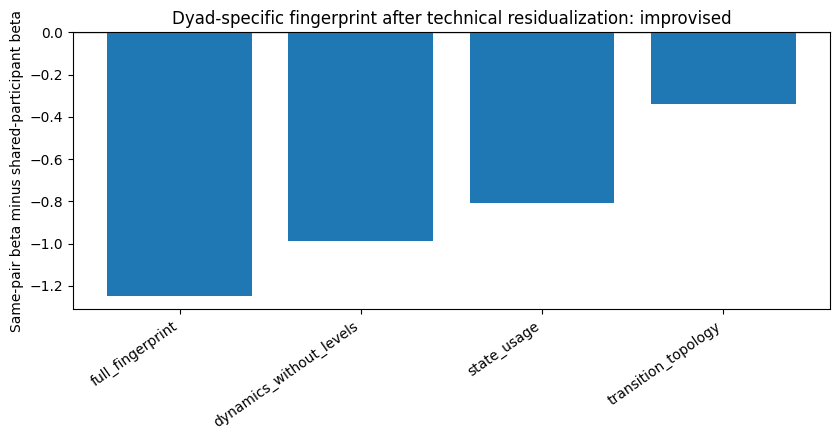

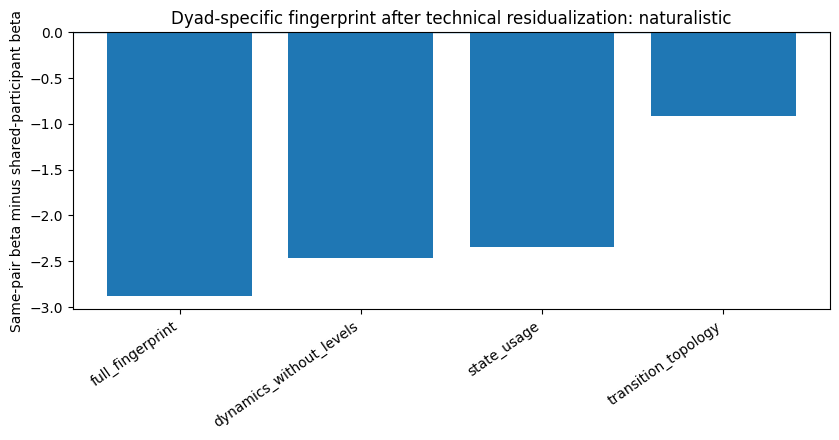


Saved final confirmatory outputs to: /content/article3_q1_additional_experiments/results
Primary interpretation rule:
  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint
  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05
  -> fingerprint is more dyad-specific than participant-specific
  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors


In [ ]:
#@title Primary confirmatory validation
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import math
import zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler


CONFIRM_DWELL_SECONDS = (2.0, 3.0)
CONFIRM_QAP_PERMUTATIONS = 5000
CONFIRM_MARKOV_SIMULATIONS = 2000
CONFIRM_RIDGE_ALPHA = 10.0
CONFIRM_RANDOM_STATE = int(getattr(CFG, 'random_state', 42))
CONFIRM_STATE_COLUMNS = ['cias_A', 'pmci_A', 'cias_B', 'pmci_B']
CONFIRM_K = int(getattr(CFG, 'selected_k', 3))


_required = [
    'dyad', 'regime_data', 'transfer_dyad', 'manifest', 'transfer_manifest',
    'CFG', 'RESULTS', 'final_scaler', 'final_kmeans'
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Run the original notebook through cell 11B first. Missing objects: '
        + ', '.join(_missing)
    )

RESULTS = Path(RESULTS)
RESULTS.mkdir(parents=True, exist_ok=True)


def confirm_bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan, dtype=float)
    valid = np.flatnonzero(np.isfinite(p))
    if len(valid) == 0:
        return out
    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    out[valid] = restored
    return out


def confirm_parse_pair(pair_id):
    parts = str(pair_id).split('__')
    if len(parts) >= 2:
        return parts[0], parts[1]
    return str(pair_id), ''


def confirm_safe_matrix(frame_or_array):
    X = np.asarray(frame_or_array, dtype=float).copy()
    X[~np.isfinite(X)] = np.nan
    med = np.nanmedian(X, axis=0)
    med[~np.isfinite(med)] = 0.0
    rr, cc = np.where(~np.isfinite(X))
    if len(rr):
        X[rr, cc] = med[cc]
    sd = np.std(X, axis=0)
    keep = np.isfinite(sd) & (sd > 1e-10)
    if not np.any(keep):
        return np.zeros((len(X), 1), dtype=float)
    return X[:, keep]


def confirm_standardize(frame_or_array):
    X = confirm_safe_matrix(frame_or_array)
    if X.shape[1] == 0:
        return np.zeros((len(X), 1), dtype=float)
    return StandardScaler().fit_transform(X)


def confirm_infer_step(times, fallback=0.5):
    times = np.asarray(times, dtype=float)
    dt = np.diff(times)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(np.median(dt)) if len(dt) else float(fallback)


def confirm_run_length(labels):
    labels = np.asarray(labels, dtype=int)
    if len(labels) == 0:
        return []
    starts = [0]
    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            starts.append(i)
    starts.append(len(labels))
    return [
        {'start': starts[i], 'end': starts[i + 1] - 1, 'label': int(labels[starts[i]])}
        for i in range(len(starts) - 1)
    ]


def confirm_run_duration(times, run):
    start, end = int(run['start']), int(run['end'])
    local = np.asarray(times[start:end + 1], dtype=float)
    step = confirm_infer_step(local, getattr(CFG, 'stride_seconds', 0.5))
    return float(local[-1] - local[0] + step)


def confirm_prepare_timeaware(frame, condition):
    data = frame.copy().sort_values(['session_id', 'time_sec']).reset_index(drop=True)

    prepared = []
    audit_rows = []
    for session_id, g in data.groupby('session_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True).copy()
        t = g['time_sec'].to_numpy(float)
        step = confirm_infer_step(t, getattr(CFG, 'stride_seconds', 0.5))
        max_gap = max(0.75, 1.5 * step)
        dt = np.r_[np.nan, np.diff(t)]
        segment_break = np.zeros(len(g), dtype=int)
        segment_break[0] = 1
        if len(g) > 1:
            segment_break[1:] = (np.diff(t) > max_gap).astype(int)
        g['continuous_segment_local'] = np.cumsum(segment_break) - 1
        g['continuous_segment_id'] = (
            condition + '::' + g['session_id'].astype(str) + '::' +
            g['continuous_segment_local'].astype(str)
        )
        g['dt_seconds'] = dt

        for person in ['A', 'B']:
            for signal in ['cias', 'pmci']:
                col = f'{signal}_{person}'
                dcol = f'd_{signal}_{person}_dt'
                diff = g.groupby('continuous_segment_id')[col].diff()
                local_dt = g.groupby('continuous_segment_id')['time_sec'].diff()
                g[dcol] = diff / local_dt.replace(0, np.nan)

        derivative_cols = [
            'd_cias_A_dt', 'd_pmci_A_dt', 'd_cias_B_dt', 'd_pmci_B_dt'
        ]
        g['joint_velocity_timeaware'] = np.sqrt(
            g[derivative_cols].fillna(0.0).pow(2).sum(axis=1)
        )

        audit_rows.append({
            'condition': condition,
            'session_id': session_id,
            'n_rows': len(g),
            'n_segments': int(g['continuous_segment_id'].nunique()),
            'median_dt': step,
            'max_dt': float(np.nanmax(dt)) if np.any(np.isfinite(dt)) else np.nan,
            'n_large_gaps': int(np.sum(np.isfinite(dt) & (dt > max_gap))),
        })
        prepared.append(g)

    return pd.concat(prepared, ignore_index=True), pd.DataFrame(audit_rows)


def confirm_apply_state_labels(frame, condition):
    data = frame.copy()
    X = final_scaler.transform(data[CONFIRM_STATE_COLUMNS])
    distances = cdist(X, final_kmeans.cluster_centers_)
    sorted_d = np.sort(distances, axis=1)


    if condition == 'improvised' and 'regime_cf' in data.columns:
        data['regime_frozen'] = data['regime_cf'].astype(int)
        if 'regime_cf_boundary_margin' in data.columns:
            data['regime_boundary_margin'] = data['regime_cf_boundary_margin'].astype(float)
        else:
            data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]
    else:
        data['regime_frozen'] = final_kmeans.predict(X)
        data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]

    data['regime_nearest_distance'] = sorted_d[:, 0]
    data['condition'] = condition
    return data


primary_prepared, primary_gap_audit = confirm_prepare_timeaware(regime_data, 'improvised')
transfer_prepared, transfer_gap_audit = confirm_prepare_timeaware(transfer_dyad, 'naturalistic')
primary_prepared = confirm_apply_state_labels(primary_prepared, 'improvised')
transfer_prepared = confirm_apply_state_labels(transfer_prepared, 'naturalistic')
confirm_time_gap_audit = pd.concat([primary_gap_audit, transfer_gap_audit], ignore_index=True)


confirm_state_centroids = pd.DataFrame(
    final_scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=CONFIRM_STATE_COLUMNS,
)
confirm_state_centroids.insert(0, 'state', np.arange(CONFIRM_K))
confirm_state_centroids['centroid_joint_consistency'] = confirm_state_centroids[
    CONFIRM_STATE_COLUMNS
].mean(axis=1)
confirm_state_centroids['centroid_state_asymmetry'] = np.sqrt(
    (confirm_state_centroids['cias_A'] - confirm_state_centroids['cias_B']) ** 2
    + (confirm_state_centroids['pmci_A'] - confirm_state_centroids['pmci_B']) ** 2
)


def confirm_smooth_segment(labels, times, minimum_dwell_seconds):
    labels = np.asarray(labels, dtype=int).copy()
    times = np.asarray(times, dtype=float)
    if minimum_dwell_seconds <= 0 or len(labels) < 2:
        return labels

    for _ in range(1000):
        runs = confirm_run_length(labels)
        durations = [confirm_run_duration(times, run) for run in runs]
        short_indices = [i for i, duration in enumerate(durations) if duration < minimum_dwell_seconds]
        if not short_indices or len(runs) == 1:
            break


        i = min(short_indices, key=lambda idx: durations[idx])
        run = runs[i]
        left = runs[i - 1] if i > 0 else None
        right = runs[i + 1] if i + 1 < len(runs) else None

        if left is not None and right is not None and left['label'] == right['label']:
            replacement = left['label']
        elif left is None and right is not None:
            replacement = right['label']
        elif right is None and left is not None:
            replacement = left['label']
        elif left is not None and right is not None:
            left_duration = durations[i - 1]
            right_duration = durations[i + 1]
            replacement = left['label'] if left_duration >= right_duration else right['label']
        else:
            break

        labels[int(run['start']):int(run['end']) + 1] = int(replacement)

    return labels


def confirm_apply_minimum_dwell(frame, dwell_seconds):
    data = frame.copy()
    output_labels = np.full(len(data), -1, dtype=int)
    audit = []

    for segment_id, idx in data.groupby('continuous_segment_id', sort=False).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        idx = idx[np.argsort(data.loc[idx, 'time_sec'].to_numpy(float))]
        labels = data.loc[idx, 'regime_frozen'].to_numpy(int)
        times = data.loc[idx, 'time_sec'].to_numpy(float)
        smoothed = confirm_smooth_segment(labels, times, dwell_seconds)
        output_labels[idx] = smoothed
        audit.append({
            'condition': data.loc[idx[0], 'condition'],
            'minimum_dwell_seconds': float(dwell_seconds),
            'continuous_segment_id': segment_id,
            'original_switches': int(np.sum(labels[1:] != labels[:-1])),
            'smoothed_switches': int(np.sum(smoothed[1:] != smoothed[:-1])),
            'changed_rows': int(np.sum(smoothed != labels)),
        })

    if np.any(output_labels < 0):
        raise AssertionError('Some rows did not receive minimum-dwell labels.')
    label_col = f'regime_dwell_{str(dwell_seconds).replace(".", "p")}'
    data[label_col] = output_labels
    return data, label_col, pd.DataFrame(audit)


def confirm_extract_runs_and_transitions(frame, label_col):
    run_rows, transition_rows = [], []

    for segment_id, g in frame.groupby('continuous_segment_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True)
        labels = g[label_col].to_numpy(int)
        times = g['time_sec'].to_numpy(float)
        runs = confirm_run_length(labels)
        local_runs = []

        for run_index, run in enumerate(runs):
            start, end = int(run['start']), int(run['end'])
            row = {
                'condition': g['condition'].iloc[0],
                'session_id': g['session_id'].iloc[0],
                'pair_id': g['pair_id'].iloc[0],
                'continuous_segment_id': segment_id,
                'run_index': run_index,
                'state': int(run['label']),
                'start_time': float(times[start]),
                'end_time': float(times[end]),
                'duration_seconds': confirm_run_duration(times, run),
            }
            for signal in [
                'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
                'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
                'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            ]:
                if signal in g.columns:
                    row[f'mean_{signal}'] = float(pd.to_numeric(
                        g.loc[start:end, signal], errors='coerce'
                    ).mean())
            run_rows.append(row)
            local_runs.append(row)

        for source, target in zip(local_runs[:-1], local_runs[1:]):
            transition_rows.append({
                'condition': source['condition'],
                'session_id': source['session_id'],
                'pair_id': source['pair_id'],
                'continuous_segment_id': segment_id,
                'source_state': int(source['state']),
                'target_state': int(target['state']),
                'edge': f"{source['state']}->{target['state']}",
                'transition_time': float(target['start_time']),
            })

    return pd.DataFrame(run_rows), pd.DataFrame(transition_rows)


def confirm_normalized_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    if len(counts) <= 1:
        return 0.0
    p = counts / counts.sum()
    return float(-np.sum(p * np.log(p)) / np.log(len(counts)))


def confirm_build_fingerprints(frame, runs, transitions, dwell_seconds):
    rows = []
    for (session_id, pair_id), sf in frame.groupby(['session_id', 'pair_id'], sort=False):
        sr = runs[runs['session_id'] == session_id].copy()
        st = transitions[transitions['session_id'] == session_id].copy()
        total_duration = float(sr['duration_seconds'].sum())
        pa, pb = confirm_parse_pair(pair_id)

        row = {
            'condition': sf['condition'].iloc[0],
            'minimum_dwell_seconds': float(dwell_seconds),
            'session_id': str(session_id),
            'pair_id': str(pair_id),
            'participant_a': pa,
            'participant_b': pb,
            'session_duration_seconds': total_duration,
            'n_rows': len(sf),
            'n_segments': int(sf['continuous_segment_id'].nunique()),
            'n_runs': len(sr),
            'n_transitions': len(st),
            'switching_rate_per_minute': 60.0 * len(st) / max(total_duration, 1e-8),
        }

        for state in range(CONFIRM_K):
            state_runs = sr[sr['state'] == state]
            state_duration = float(state_runs['duration_seconds'].sum())
            row[f'occupancy_state_{state}'] = state_duration / max(total_duration, 1e-8)
            row[f'mean_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].mean()) if len(state_runs) else 0.0
            )
            row[f'median_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].median()) if len(state_runs) else 0.0
            )

        edge_counts = []
        for source in range(CONFIRM_K):
            source_rows = st[st['source_state'] == source]
            source_total = len(source_rows)
            for target in range(CONFIRM_K):
                if source == target:
                    continue
                count = int(np.sum(source_rows['target_state'] == target)) if source_total else 0
                edge_counts.append(count)
                row[f'transition_p_{source}_{target}'] = count / source_total if source_total else 0.0

        row['transition_entropy'] = confirm_normalized_entropy(edge_counts)

        returns, triplets = 0, 0
        for _, segment_runs in sr.groupby('continuous_segment_id', sort=False):
            seq = segment_runs.sort_values('run_index')['state'].to_numpy(int)
            for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
                triplets += 1
                returns += int(a == c and a != b)
        row['return_probability'] = returns / triplets if triplets else 0.0

        for signal in [
            'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
            'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
            'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            'regime_nearest_distance',
        ]:
            if signal in sf.columns:
                values = pd.to_numeric(sf[signal], errors='coerce')
                row[f'session_mean_{signal}'] = float(values.mean())
                row[f'session_std_{signal}'] = float(values.std())

        rows.append(row)

    return pd.DataFrame(rows)


def confirm_manifest_metadata(manifest_df, condition):
    m = manifest_df.copy()
    session_key = 'interaction_key' if 'interaction_key' in m.columns else 'session_id'
    keep_candidates = [
        'recording_session_id', 'interaction_prompt_id', 'dataset_label',
        'dataset_split', 'pair_id'
    ]
    keep = [c for c in keep_candidates if c in m.columns]
    meta = m[[session_key] + keep].groupby(session_key, as_index=False).first()
    meta = meta.rename(columns={session_key: 'session_id'})
    meta['session_id'] = meta['session_id'].astype(str)
    meta['condition'] = condition
    return meta


def confirm_add_metadata(fingerprints):
    primary_meta = confirm_manifest_metadata(manifest, 'improvised')
    transfer_meta = confirm_manifest_metadata(transfer_manifest, 'naturalistic')
    meta = pd.concat([primary_meta, transfer_meta], ignore_index=True)
    out = fingerprints.merge(meta, on=['session_id', 'condition'], how='left', suffixes=('', '_manifest'))
    out['vendor'] = out['session_id'].astype(str).str.split('_').str[0]
    return out


def confirm_technical_columns(frame):
    numeric = [
        c for c in [
            'session_duration_seconds', 'n_rows', 'n_segments',
            'session_mean_valid_fraction_A', 'session_mean_valid_fraction_B',
            'session_std_valid_fraction_A', 'session_std_valid_fraction_B',
            'session_mean_regime_nearest_distance', 'session_std_regime_nearest_distance',
        ] if c in frame.columns
    ]
    categorical = [
        c for c in ['vendor', 'recording_session_id', 'interaction_prompt_id']
        if c in frame.columns and 1 < frame[c].nunique(dropna=True) <= 30
    ]
    return numeric, categorical


def confirm_build_technical_matrix(frame):
    numeric, categorical = confirm_technical_columns(frame)
    parts = []
    names = []

    if numeric:
        num = frame[numeric].apply(pd.to_numeric, errors='coerce').copy()
        for c in numeric:
            med = num[c].median()
            num[c] = num[c].fillna(float(med) if np.isfinite(med) else 0.0)
        num_values = confirm_standardize(num.to_numpy(float))
        parts.append(num_values)
        names.extend([f'numeric_{i}' for i in range(num_values.shape[1])])

    if categorical:
        cat = pd.get_dummies(frame[categorical].fillna('missing').astype(str), drop_first=True, dtype=float)
        if cat.shape[1]:
            parts.append(cat.to_numpy(float))
            names.extend(cat.columns.astype(str).tolist())

    if not parts:
        return np.zeros((len(frame), 0), dtype=float), []
    return np.column_stack(parts), names


def confirm_relationship_matrices(frame):
    n = len(frame)
    same_pair = np.zeros((n, n), dtype=float)
    shared_participant = np.zeros((n, n), dtype=float)
    participant_sets = []
    for pair_id in frame['pair_id'].astype(str):
        participant_sets.append(set(confirm_parse_pair(pair_id)))

    pair_ids = frame['pair_id'].astype(str).to_numpy()
    for i in range(n):
        for j in range(i + 1, n):
            if pair_ids[i] == pair_ids[j]:
                same_pair[i, j] = same_pair[j, i] = 1.0
            elif len(participant_sets[i] & participant_sets[j]) > 0:
                shared_participant[i, j] = shared_participant[j, i] = 1.0
    return same_pair, shared_participant


def confirm_group_crossfitted_residuals(features, technical, groups, alpha=10.0):
    Y = confirm_safe_matrix(features)
    if technical.shape[1] == 0:
        return Y.copy()

    groups = np.asarray(groups).astype(str)
    predictions = np.zeros_like(Y, dtype=float)
    for group in np.unique(groups):
        test = groups == group
        train = ~test
        if np.sum(train) < 3:
            predictions[test] = np.mean(Y[train], axis=0) if np.any(train) else 0.0
            continue
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(technical[train], Y[train])
        predictions[test] = model.predict(technical[test])
    return Y - predictions


def confirm_mrqap(distance_matrix, same_pair, shared_participant, technical_distance=None,
                   permutations=5000, seed=42):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]

    predictors = [np.ones(len(y)), same_pair[upper], shared_participant[upper]]
    names = ['intercept', 'same_pair', 'shared_participant']
    if technical_distance is not None:
        tv = technical_distance[upper]
        if np.nanstd(tv) > 1e-10:
            tv = (tv - np.nanmean(tv)) / np.nanstd(tv)
            predictors.append(tv)
            names.append('technical_distance')
    X = np.column_stack(predictors)
    observed = np.linalg.lstsq(X, y, rcond=None)[0]
    i_pair = names.index('same_pair')
    i_shared = names.index('shared_participant')
    observed_pair = float(observed[i_pair])
    observed_shared = float(observed[i_shared])
    observed_contrast = observed_pair - observed_shared

    rng = np.random.default_rng(seed)
    null_pair = np.empty(permutations)
    null_shared = np.empty(permutations)
    null_contrast = np.empty(permutations)

    for b in range(permutations):
        perm = rng.permutation(n)
        yp = distance_matrix[np.ix_(perm, perm)][upper]
        beta = np.linalg.lstsq(X, yp, rcond=None)[0]
        null_pair[b] = beta[i_pair]
        null_shared[b] = beta[i_shared]
        null_contrast[b] = beta[i_pair] - beta[i_shared]

    return {
        'same_pair_beta': observed_pair,
        'same_pair_qap_p': float((1 + np.sum(null_pair <= observed_pair)) / (permutations + 1)),
        'shared_participant_beta': observed_shared,
        'shared_participant_qap_p': float((1 + np.sum(null_shared <= observed_shared)) / (permutations + 1)),
        'same_pair_minus_shared_beta': observed_contrast,
        'pair_specificity_qap_p': float((1 + np.sum(null_contrast <= observed_contrast)) / (permutations + 1)),
    }


def confirm_nearest_pair_accuracy(distance_matrix, pair_ids, permutations=5000, seed=42):
    D = distance_matrix.copy()
    np.fill_diagonal(D, np.inf)
    pair_ids = np.asarray(pair_ids).astype(str)
    nearest = np.argmin(D, axis=1)
    observed = float(np.mean(pair_ids[nearest] == pair_ids))
    rng = np.random.default_rng(seed)
    null = np.empty(permutations)
    for b in range(permutations):
        labels = rng.permutation(pair_ids)
        null[b] = np.mean(labels[nearest] == labels)
    p = float((1 + np.sum(null >= observed)) / (permutations + 1))
    return observed, p


def confirm_feature_groups(frame):
    numeric = [
        c for c in frame.columns
        if pd.api.types.is_numeric_dtype(frame[c])
    ]
    state_usage = [c for c in numeric if c.startswith(('occupancy_state_', 'mean_dwell_state_', 'median_dwell_state_'))]
    topology = [
        c for c in numeric
        if c.startswith('transition_p_') or c in {
            'switching_rate_per_minute', 'transition_entropy', 'return_probability'
        }
    ]
    absolute_levels = [
        c for c in numeric
        if c.startswith('session_mean_')
        and not any(token in c for token in ['valid_fraction', 'regime_', 'joint_velocity'])
    ]
    signal_dynamics = [
        c for c in numeric
        if (
            c.startswith('session_std_')
            or c == 'session_mean_joint_velocity_timeaware'
        )
        and not any(token in c for token in ['valid_fraction', 'regime_'])
    ]
    dynamics_without_levels = sorted(set(state_usage + topology + signal_dynamics))
    full = sorted(set(state_usage + topology + absolute_levels + signal_dynamics))
    return {
        'state_usage': state_usage,
        'transition_topology': topology,
        'absolute_signal_levels': absolute_levels,
        'signal_dynamics': signal_dynamics,
        'dynamics_without_levels': dynamics_without_levels,
        'full_fingerprint': full,
    }


confirm_store = {}
all_fingerprints, all_runs, all_transitions, all_smoothing_audits = [], [], [], []

for condition, base_frame in [
    ('improvised', primary_prepared),
    ('naturalistic', transfer_prepared),
]:
    for dwell in CONFIRM_DWELL_SECONDS:
        smoothed, label_col, smoothing_audit = confirm_apply_minimum_dwell(base_frame, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fingerprints = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
        confirm_store[(condition, dwell)] = {
            'frame': smoothed,
            'label_col': label_col,
            'runs': runs,
            'transitions': transitions,
            'fingerprints': fingerprints,
        }
        all_fingerprints.append(fingerprints)
        all_runs.append(runs.assign(minimum_dwell_seconds=float(dwell)))
        all_transitions.append(transitions.assign(minimum_dwell_seconds=float(dwell)))
        all_smoothing_audits.append(smoothing_audit)

confirm_fingerprints = confirm_add_metadata(pd.concat(all_fingerprints, ignore_index=True))
confirm_runs = pd.concat(all_runs, ignore_index=True)
confirm_transitions = pd.concat(all_transitions, ignore_index=True)
confirm_smoothing_audit = pd.concat(all_smoothing_audits, ignore_index=True)
CONFIRM_FEATURE_GROUPS = confirm_feature_groups(confirm_fingerprints)

print('Feature groups:')
for name, columns in CONFIRM_FEATURE_GROUPS.items():
    print(f'  {name}: {len(columns)} features')


confirm_rows = []
confirm_technical_rows = []

for condition in ['improvised', 'naturalistic']:
    for dwell in CONFIRM_DWELL_SECONDS:
        data = confirm_fingerprints[
            (confirm_fingerprints['condition'] == condition)
            & (confirm_fingerprints['minimum_dwell_seconds'] == float(dwell))
        ].sort_values('session_id').reset_index(drop=True)

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            technical_test = confirm_mrqap(
                technical_distance, same_pair, shared_participant,
                permutations=CONFIRM_QAP_PERMUTATIONS,
                seed=CONFIRM_RANDOM_STATE + int(dwell * 100) + (0 if condition == 'improvised' else 10000),
            )
            confirm_technical_rows.append({
                'condition': condition,
                'minimum_dwell_seconds': float(dwell),
                'n_sessions': len(data),
                'n_pairs': data['pair_id'].nunique(),
                'n_technical_predictors': technical_matrix.shape[1],
                **technical_test,
            })

        for feature_group, columns in CONFIRM_FEATURE_GROUPS.items():
            columns = [c for c in columns if c in data.columns]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors='coerce').to_numpy(float)

            for adjustment in ['raw_with_technical_covariate', 'pair_crossfitted_technical_residuals']:
                if adjustment == 'raw_with_technical_covariate':
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw, technical_matrix, data['pair_id'].astype(str).to_numpy(),
                        alpha=CONFIRM_RIDGE_ALPHA,
                    )

                standardized = confirm_standardize(features)
                distance = pairwise_distances(standardized)
                result = confirm_mrqap(
                    distance, same_pair, shared_participant,
                    technical_distance=technical_distance,
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=(
                        CONFIRM_RANDOM_STATE
                        + len(confirm_rows) * 17
                        + int(dwell * 100)
                        + (0 if condition == 'improvised' else 20000)
                    ),
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance, data['pair_id'],
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=CONFIRM_RANDOM_STATE + 30000 + len(confirm_rows),
                )
                confirm_rows.append({
                    'condition': condition,
                    'minimum_dwell_seconds': float(dwell),
                    'adjustment': adjustment,
                    'feature_group': feature_group,
                    'n_features': len(columns),
                    'n_sessions': len(data),
                    'n_pairs': data['pair_id'].nunique(),
                    'nearest_pair_accuracy': accuracy,
                    'nearest_pair_accuracy_p': accuracy_p,
                    **result,
                })

confirm_fingerprint_results = pd.DataFrame(confirm_rows)
confirm_technical_confound_results = pd.DataFrame(confirm_technical_rows)

for keys, idx in confirm_fingerprint_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'adjustment']
).groups.items():
    confirm_fingerprint_results.loc[idx, 'same_pair_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'same_pair_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p']
    )


def confirm_gateway_counts_from_sequences(sequences, gateway_state):
    others = [state for state in range(CONFIRM_K) if state != gateway_state]
    if len(others) != 2:
        return 0, 0
    x, y = others
    mediated, direct = 0, 0
    for seq in sequences:
        seq = np.asarray(seq, dtype=int)
        for a, b in zip(seq[:-1], seq[1:]):
            direct += int({int(a), int(b)} == {x, y})
        for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
            mediated += int(int(b) == gateway_state and {int(a), int(c)} == {x, y})
    return mediated, direct


def confirm_pair_sequences(runs_for_pair):
    sequences = []
    for _, g in runs_for_pair.groupby('continuous_segment_id', sort=False):
        seq = g.sort_values('run_index')['state'].to_numpy(int)
        if len(seq):
            sequences.append(seq)
    return sequences


def confirm_transition_matrix(sequences, pseudocount=0.5):
    counts = np.full((CONFIRM_K, CONFIRM_K), float(pseudocount))
    np.fill_diagonal(counts, 0.0)
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            if a != b:
                counts[int(a), int(b)] += 1.0
    matrix = np.zeros_like(counts)
    for state in range(CONFIRM_K):
        total = counts[state].sum()
        if total > 0:
            matrix[state] = counts[state] / total
        else:
            choices = [x for x in range(CONFIRM_K) if x != state]
            matrix[state, choices] = 1.0 / len(choices)
    return matrix


def confirm_simulate_markov_sequences(observed_sequences, transition_matrix, rng):
    simulated = []
    for observed in observed_sequences:
        observed = np.asarray(observed, dtype=int)
        if len(observed) == 0:
            simulated.append(observed)
            continue
        seq = np.empty(len(observed), dtype=int)
        seq[0] = int(observed[0])
        for i in range(1, len(seq)):
            seq[i] = int(rng.choice(np.arange(CONFIRM_K), p=transition_matrix[seq[i - 1]]))
        simulated.append(seq)
    return simulated


gateway_rows = []
for (condition, dwell, pair_id), pair_runs in confirm_runs.groupby(
    ['condition', 'minimum_dwell_seconds', 'pair_id'], sort=False
):
    sequences = confirm_pair_sequences(pair_runs)
    transition_matrix = confirm_transition_matrix(sequences)
    rng = np.random.default_rng(
        CONFIRM_RANDOM_STATE + zlib.crc32(f'{condition}|{float(dwell)}|{pair_id}'.encode('utf-8')) % 1_000_000
    )

    for gateway_state in range(CONFIRM_K):
        observed_mediated, observed_direct = confirm_gateway_counts_from_sequences(sequences, gateway_state)
        denominator = observed_mediated + observed_direct
        if denominator == 0:
            continue
        observed_ratio = observed_mediated / denominator
        null_ratios = []
        for _ in range(CONFIRM_MARKOV_SIMULATIONS):
            simulated = confirm_simulate_markov_sequences(sequences, transition_matrix, rng)
            mediated, direct = confirm_gateway_counts_from_sequences(simulated, gateway_state)
            if mediated + direct > 0:
                null_ratios.append(mediated / (mediated + direct))
        null_ratios = np.asarray(null_ratios, dtype=float)
        if len(null_ratios) == 0:
            continue
        null_mean = float(np.mean(null_ratios))
        null_sd = float(np.std(null_ratios, ddof=1)) if len(null_ratios) > 1 else np.nan
        gateway_rows.append({
            'condition': condition,
            'minimum_dwell_seconds': float(dwell),
            'pair_id': pair_id,
            'gateway_state': gateway_state,
            'observed_gateway_ratio': observed_ratio,
            'markov_null_mean': null_mean,
            'gateway_excess_over_markov': observed_ratio - null_mean,
            'markov_null_sd': null_sd,
            'pair_markov_p_greater': float((1 + np.sum(null_ratios >= observed_ratio)) / (len(null_ratios) + 1)),
            'observed_mediated_count': observed_mediated,
            'observed_direct_count': observed_direct,
        })

confirm_gateway_pair_results = pd.DataFrame(gateway_rows)

gateway_summary_rows = []
for (condition, dwell, state), g in confirm_gateway_pair_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'gateway_state']
):
    values = g['gateway_excess_over_markov'].dropna().to_numpy(float)
    if len(values) >= 5 and not np.allclose(values, 0):
        stat, p = wilcoxon(values, alternative='greater')
    else:
        p = np.nan
    rng = np.random.default_rng(CONFIRM_RANDOM_STATE + len(gateway_summary_rows))
    boot = np.array([
        np.mean(rng.choice(values, size=len(values), replace=True))
        for _ in range(5000)
    ]) if len(values) else np.array([])
    gateway_summary_rows.append({
        'condition': condition,
        'minimum_dwell_seconds': float(dwell),
        'gateway_state': int(state),
        'n_pairs': len(values),
        'mean_observed_gateway_ratio': float(g['observed_gateway_ratio'].mean()),
        'mean_markov_null_ratio': float(g['markov_null_mean'].mean()),
        'mean_gateway_excess_over_markov': float(np.mean(values)) if len(values) else np.nan,
        'bootstrap_ci_low': float(np.quantile(boot, 0.025)) if len(boot) else np.nan,
        'bootstrap_ci_high': float(np.quantile(boot, 0.975)) if len(boot) else np.nan,
        'n_positive_pairs': int(np.sum(values > 0)),
        'wilcoxon_greater_p': float(p) if np.isfinite(p) else np.nan,
    })

confirm_gateway_markov_summary = pd.DataFrame(gateway_summary_rows)
for dwell, idx in confirm_gateway_markov_summary.groupby('minimum_dwell_seconds').groups.items():
    confirm_gateway_markov_summary.loc[idx, 'p_fdr_bh'] = confirm_bh_adjust(
        confirm_gateway_markov_summary.loc[idx, 'wilcoxon_greater_p']
    )


core_groups = ['state_usage', 'transition_topology', 'dynamics_without_levels', 'full_fingerprint']
confirm_core_results = confirm_fingerprint_results[
    confirm_fingerprint_results['feature_group'].isin(core_groups)
].copy()
confirm_core_results['same_pair_confirmed'] = (
    (confirm_core_results['same_pair_beta'] < 0)
    & (confirm_core_results['same_pair_qap_p_fdr'] < 0.05)
)
confirm_core_results['dyad_specific_confirmed'] = (
    confirm_core_results['same_pair_confirmed']
    & (confirm_core_results['same_pair_minus_shared_beta'] < 0)
    & (confirm_core_results['pair_specificity_qap_p_fdr'] < 0.05)
)

confirm_robustness_summary = confirm_core_results.groupby('feature_group', as_index=False).agg(
    n_tests=('dyad_specific_confirmed', 'size'),
    n_same_pair_confirmed=('same_pair_confirmed', 'sum'),
    n_dyad_specific_confirmed=('dyad_specific_confirmed', 'sum'),
    fraction_same_pair_confirmed=('same_pair_confirmed', 'mean'),
    fraction_dyad_specific_confirmed=('dyad_specific_confirmed', 'mean'),
    median_nearest_pair_accuracy=('nearest_pair_accuracy', 'median'),
)


print('\nSTATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS')
display(confirm_state_centroids.round(6))

print('\nTIME-GAP AUDIT')
display(confirm_time_gap_audit.sort_values(['condition', 'n_large_gaps'], ascending=[True, False]).round(6))

print('\nMINIMUM-DWELL AUDIT')
display(
    confirm_smoothing_audit.groupby(['condition', 'minimum_dwell_seconds'], as_index=False).agg(
        original_switches=('original_switches', 'sum'),
        smoothed_switches=('smoothed_switches', 'sum'),
        changed_rows=('changed_rows', 'sum'),
        represented_segments=('continuous_segment_id', 'nunique'),
    )
)

print('\nTECHNICAL-CONFOUND QAP')
if len(confirm_technical_confound_results):
    display(confirm_technical_confound_results.round(6))
else:
    print('No usable technical predictors were available.')

print('\nFINAL CONFIRMATORY FINGERPRINT RESULTS')
display(
    confirm_fingerprint_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'n_features', 'n_sessions', 'n_pairs',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'shared_participant_beta',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values([
        'feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'
    ]).round(6)
)

print('\nCORE DECISION TABLE')
display(
    confirm_core_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'same_pair_confirmed', 'dyad_specific_confirmed',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values(['feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'])
)

print('\nFINGERPRINT ROBUSTNESS SUMMARY')
display(confirm_robustness_summary.round(6))

print('\nGATEWAY VS FIRST-ORDER MARKOV NULL')
display(
    confirm_gateway_markov_summary.sort_values(
        ['minimum_dwell_seconds', 'condition', 'p_fdr_bh']
    ).round(6)
)


plot_data = confirm_core_results[
    (confirm_core_results['minimum_dwell_seconds'] == 3.0)
    & (confirm_core_results['adjustment'] == 'pair_crossfitted_technical_residuals')
].copy()

for condition, g in plot_data.groupby('condition'):
    g = g.sort_values('same_pair_minus_shared_beta')
    plt.figure(figsize=(8.5, 4.5))
    plt.bar(g['feature_group'], g['same_pair_minus_shared_beta'])
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=35, ha='right')
    plt.ylabel('Same-pair beta minus shared-participant beta')
    plt.title(f'Dyad-specific fingerprint after technical residualization: {condition}')
    plt.tight_layout()
    plt.show()


confirm_state_centroids.to_csv(RESULTS / 'FINAL_confirmatory_state_centroids.csv', index=False)
confirm_time_gap_audit.to_csv(RESULTS / 'FINAL_confirmatory_time_gap_audit.csv', index=False)
confirm_smoothing_audit.to_csv(RESULTS / 'FINAL_confirmatory_minimum_dwell_audit.csv', index=False)
confirm_fingerprints.to_csv(RESULTS / 'FINAL_confirmatory_session_fingerprints.csv', index=False)
confirm_runs.to_csv(RESULTS / 'FINAL_confirmatory_state_runs.csv', index=False)
confirm_transitions.to_csv(RESULTS / 'FINAL_confirmatory_transitions.csv', index=False)
confirm_technical_confound_results.to_csv(RESULTS / 'FINAL_confirmatory_technical_confound_qap.csv', index=False)
confirm_fingerprint_results.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_mrqap.csv', index=False)
confirm_core_results.to_csv(RESULTS / 'FINAL_confirmatory_core_decision_table.csv', index=False)
confirm_robustness_summary.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_robustness.csv', index=False)
confirm_gateway_pair_results.to_csv(RESULTS / 'FINAL_confirmatory_gateway_pair_markov_null.csv', index=False)
confirm_gateway_markov_summary.to_csv(RESULTS / 'FINAL_confirmatory_gateway_markov_summary.csv', index=False)

print('\nSaved final confirmatory outputs to:', RESULTS)
print('Primary interpretation rule:')
print('  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint')
print('  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05')
print('  -> fingerprint is more dyad-specific than participant-specific')
print('  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors')


In [ ]:
#@title Robust statistical helpers
from itertools import product
from scipy.stats import t as student_t

R2_EPS = 1e-10


def r2_validate_distance_matrix(distance_matrix, name="distance"):
    D = np.asarray(distance_matrix, dtype=float)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError(f"{name} must be a square matrix; got {D.shape}.")
    if not np.isfinite(D).all():
        raise ValueError(f"{name} contains non-finite values.")
    if not np.allclose(D, D.T, atol=1e-8, rtol=1e-8):
        raise ValueError(f"{name} is not symmetric.")
    if not np.allclose(np.diag(D), 0.0, atol=1e-8):
        raise ValueError(f"{name} diagonal must be zero before nearest-neighbour masking.")
    if np.any(D < -1e-10):
        raise ValueError(f"{name} contains negative distances.")
    return D


def r2_empirical_p(null_values, observed, alternative="less"):
    null = np.asarray(null_values, dtype=float)
    null = null[np.isfinite(null)]
    if len(null) == 0 or not np.isfinite(observed):
        return np.nan
    if alternative == "less":
        count = np.sum(null <= observed)
    elif alternative == "greater":
        count = np.sum(null >= observed)
    elif alternative == "two-sided":
        center = float(np.mean(null))
        count = np.sum(np.abs(null - center) >= abs(observed - center))
    else:
        raise ValueError("alternative must be 'less', 'greater', or 'two-sided'.")
    return float((count + 1) / (len(null) + 1))


def confirm_mrqap(distance_matrix, same_pair, shared_participant,
                   technical_distance=None, permutations=5000, seed=42):
    """Robust MRQAP.

    Expected directions are negative for same-dyad and shared-participant distance
    effects. A same-dyad-minus-shared contrast is reported only when both terms
    are estimable. Zero-variance predictors are never interpreted as evidence.
    """
    D = r2_validate_distance_matrix(distance_matrix, "MRQAP distance")
    n = len(D)
    if n < 3:
        raise ValueError("MRQAP needs at least 3 sessions.")

    same_pair = np.asarray(same_pair, dtype=float)
    shared_participant = np.asarray(shared_participant, dtype=float)
    if same_pair.shape != D.shape or shared_participant.shape != D.shape:
        raise ValueError("Relationship matrices must match the distance matrix shape.")

    upper = np.triu_indices(n, 1)
    y = D[upper]

    predictors = [np.ones(len(y), dtype=float)]
    names = ["intercept"]

    same_v = same_pair[upper]
    shared_v = shared_participant[upper]
    same_estimable = np.nanstd(same_v) > R2_EPS
    shared_estimable = np.nanstd(shared_v) > R2_EPS

    if same_estimable:
        predictors.append(same_v)
        names.append("same_pair")
    if shared_estimable:
        predictors.append(shared_v)
        names.append("shared_participant")

    tech_estimable = False
    if technical_distance is not None:
        T = r2_validate_distance_matrix(technical_distance, "technical distance")
        tv = T[upper]
        if np.nanstd(tv) > R2_EPS:
            tv = (tv - np.nanmean(tv)) / np.nanstd(tv)
            predictors.append(tv)
            names.append("technical_distance")
            tech_estimable = True

    X = np.column_stack(predictors)
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        raise RuntimeError(
            f"MRQAP design is rank deficient after zero-variance screening: rank={rank}, p={X.shape[1]}"
        )

    beta_obs = np.linalg.lstsq(X, y, rcond=None)[0]
    beta_map = {name: float(beta_obs[i]) for i, name in enumerate(names)}

    observed_pair = beta_map.get("same_pair", np.nan)
    observed_shared = beta_map.get("shared_participant", np.nan)
    observed_contrast = (
        observed_pair - observed_shared
        if np.isfinite(observed_pair) and np.isfinite(observed_shared)
        else np.nan
    )

    rng = np.random.default_rng(seed)
    null_pair = np.full(permutations, np.nan)
    null_shared = np.full(permutations, np.nan)
    null_contrast = np.full(permutations, np.nan)

    i_pair = names.index("same_pair") if same_estimable else None
    i_shared = names.index("shared_participant") if shared_estimable else None

    for b in range(int(permutations)):
        perm = rng.permutation(n)
        yp = D[np.ix_(perm, perm)][upper]
        beta = np.linalg.lstsq(X, yp, rcond=None)[0]
        if i_pair is not None:
            null_pair[b] = beta[i_pair]
        if i_shared is not None:
            null_shared[b] = beta[i_shared]
        if i_pair is not None and i_shared is not None:
            null_contrast[b] = beta[i_pair] - beta[i_shared]

    pair_p = r2_empirical_p(null_pair, observed_pair, "less") if same_estimable else np.nan
    pair_p2 = r2_empirical_p(null_pair, observed_pair, "two-sided") if same_estimable else np.nan
    shared_p = r2_empirical_p(null_shared, observed_shared, "less") if shared_estimable else np.nan
    shared_p2 = r2_empirical_p(null_shared, observed_shared, "two-sided") if shared_estimable else np.nan
    contrast_p = (
        r2_empirical_p(null_contrast, observed_contrast, "less")
        if np.isfinite(observed_contrast) else np.nan
    )
    contrast_p2 = (
        r2_empirical_p(null_contrast, observed_contrast, "two-sided")
        if np.isfinite(observed_contrast) else np.nan
    )

    return {
        "same_pair_beta": observed_pair,
        "same_pair_qap_p": pair_p,
        "same_pair_qap_p_two_sided": pair_p2,
        "shared_participant_beta": observed_shared,
        "shared_participant_qap_p": shared_p,
        "shared_participant_qap_p_two_sided": shared_p2,
        "same_pair_minus_shared_beta": observed_contrast,
        "pair_specificity_qap_p": contrast_p,
        "pair_specificity_qap_p_two_sided": contrast_p2,
        "same_pair_estimable": bool(same_estimable),
        "shared_participant_estimable": bool(shared_estimable),
        "technical_distance_estimable": bool(tech_estimable),
        "mrqap_design_rank": int(rank),
        "mrqap_design_columns": int(X.shape[1]),
    }


def r2_nearest_indices(distance_matrix):
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance").copy()
    np.fill_diagonal(D, np.inf)
    return np.argmin(D, axis=1)


def r2_per_dyad_accuracy(distance_matrix, pair_ids, repeated_only=True):
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance")
    labels = np.asarray(pair_ids).astype(str)
    if len(labels) != len(D):
        raise ValueError("pair_ids length does not match the distance matrix.")

    counts = pd.Series(labels).value_counts()
    eligible = set(counts[counts >= 2].index) if repeated_only else set(counts.index)
    mask = np.array([x in eligible for x in labels], dtype=bool)
    if np.sum(mask) < 2:
        return pd.DataFrame(columns=["pair_id", "n_sessions", "n_correct", "accuracy"]), np.nan, np.nan

    Dsub = D[np.ix_(mask, mask)]
    lsub = labels[mask]
    nn = r2_nearest_indices(Dsub)
    correct = (lsub[nn] == lsub).astype(int)

    rows = []
    for pair in sorted(np.unique(lsub)):
        ix = lsub == pair
        rows.append({
            "pair_id": pair,
            "n_sessions": int(np.sum(ix)),
            "n_correct": int(np.sum(correct[ix])),
            "accuracy": float(np.mean(correct[ix])),
        })
    table = pd.DataFrame(rows)
    micro = float(np.mean(correct))
    macro = float(table["accuracy"].mean())
    return table, micro, macro


def r2_nearest_pair_permutation(distance_matrix, pair_ids, permutations=10000,
                                seed=42, repeated_only=True):
    """Permutation reference preserving dyad class sizes.

    For repeated-only inference, singleton dyads are removed before permutation so
    the null is defined on the same set of dyads that can actually generate a
    same-dyad nearest neighbour.
    """
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance")
    labels = np.asarray(pair_ids).astype(str)
    counts = pd.Series(labels).value_counts()
    eligible = set(counts[counts >= 2].index) if repeated_only else set(counts.index)
    mask = np.array([x in eligible for x in labels], dtype=bool)
    D = D[np.ix_(mask, mask)]
    labels = labels[mask]
    if len(labels) < 2:
        return {"micro_accuracy": np.nan, "macro_accuracy": np.nan,
                "micro_p": np.nan, "macro_p": np.nan, "n_sessions": len(labels),
                "n_dyads": len(np.unique(labels))}

    nn = r2_nearest_indices(D)
    correct = labels[nn] == labels
    obs_micro = float(np.mean(correct))
    obs_by = [float(np.mean(correct[labels == p])) for p in np.unique(labels)]
    obs_macro = float(np.mean(obs_by))

    rng = np.random.default_rng(seed)
    null_micro = np.empty(int(permutations), dtype=float)
    null_macro = np.empty(int(permutations), dtype=float)
    unique_labels = np.unique(labels)
    for b in range(int(permutations)):
        lab = rng.permutation(labels)
        c = lab[nn] == lab
        null_micro[b] = np.mean(c)
        null_macro[b] = np.mean([np.mean(c[lab == p]) for p in unique_labels])

    return {
        "micro_accuracy": obs_micro,
        "macro_accuracy": obs_macro,
        "micro_p": r2_empirical_p(null_micro, obs_micro, "greater"),
        "macro_p": r2_empirical_p(null_macro, obs_macro, "greater"),
        "chance_micro_mean": float(np.mean(null_micro)),
        "chance_micro_q025": float(np.quantile(null_micro, 0.025)),
        "chance_micro_q975": float(np.quantile(null_micro, 0.975)),
        "chance_macro_mean": float(np.mean(null_macro)),
        "chance_macro_q025": float(np.quantile(null_macro, 0.025)),
        "chance_macro_q975": float(np.quantile(null_macro, 0.975)),
        "n_sessions": int(len(labels)),
        "n_dyads": int(len(unique_labels)),
    }


def r2_dyad_bootstrap_macro_ci(per_dyad_table, iterations=10000, seed=42):
    vals = per_dyad_table["accuracy"].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.array([
        np.mean(rng.choice(vals, size=len(vals), replace=True))
        for _ in range(int(iterations))
    ])
    return float(np.mean(vals)), float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


def r2_exact_signflip_test(differences, alternative="greater"):
    """Exact dyad-level paired randomization test when the number of dyads is small."""
    d = np.asarray(differences, dtype=float)
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return np.nan
    observed = float(np.mean(d))
    if len(d) <= 20:
        stats = np.array([np.mean(d * np.asarray(s)) for s in product([-1.0, 1.0], repeat=len(d))])
        if alternative == "greater":
            return float(np.mean(stats >= observed - 1e-15))
        if alternative == "less":
            return float(np.mean(stats <= observed + 1e-15))
        return float(np.mean(np.abs(stats) >= abs(observed) - 1e-15))
    rng = np.random.default_rng(42)
    stats = np.array([np.mean(d * rng.choice([-1.0, 1.0], size=len(d))) for _ in range(200000)])
    if alternative == "greater":
        return float((1 + np.sum(stats >= observed)) / (len(stats) + 1))
    if alternative == "less":
        return float((1 + np.sum(stats <= observed)) / (len(stats) + 1))
    return float((1 + np.sum(np.abs(stats) >= abs(observed))) / (len(stats) + 1))


def r2_jackknife_ci(values_leave_one_out, theta_full, confidence=0.95):
    vals = np.asarray(values_leave_one_out, dtype=float)
    vals = vals[np.isfinite(vals)]
    m = len(vals)
    if m < 3 or not np.isfinite(theta_full):
        return np.nan, np.nan, np.nan
    mean_loo = float(np.mean(vals))
    se = float(np.sqrt((m - 1) / m * np.sum((vals - mean_loo) ** 2)))
    crit = float(student_t.ppf(1 - (1 - confidence) / 2, df=m - 1))
    return se, float(theta_full - crit * se), float(theta_full + crit * se)


def r2_mrqap_delete_one_dyad_ci(distance_matrix, data, technical_distance=None):
    """Delete-one-dyad sensitivity / jackknife CI for the same-dyad beta.

    This is preferable to treating the many session-pairs as independent.
    """
    D = r2_validate_distance_matrix(distance_matrix, "MRQAP distance")
    frame = data.reset_index(drop=True).copy()
    pair_ids = frame["pair_id"].astype(str).to_numpy()
    same, shared = confirm_relationship_matrices(frame)
    full = confirm_mrqap(D, same, shared, technical_distance=technical_distance,
                         permutations=499, seed=12345)
    theta = full["same_pair_beta"]
    loo_rows = []
    for pair in sorted(np.unique(pair_ids)):
        keep = pair_ids != pair
        if np.sum(keep) < 3:
            continue
        sub = frame.loc[keep].reset_index(drop=True)
        Ds = D[np.ix_(keep, keep)]
        Ts = technical_distance[np.ix_(keep, keep)] if technical_distance is not None else None
        s, sh = confirm_relationship_matrices(sub)
        fit = confirm_mrqap(Ds, s, sh, technical_distance=Ts,
                            permutations=199, seed=1000 + (zlib.crc32(pair.encode()) % 100000))
        loo_rows.append({"omitted_pair": pair, "same_pair_beta": fit["same_pair_beta"]})
    loo = pd.DataFrame(loo_rows)
    se, lo, hi = r2_jackknife_ci(loo["same_pair_beta"].to_numpy(float), theta) if len(loo) else (np.nan, np.nan, np.nan)
    return theta, se, lo, hi, loo


def confirm_nearest_pair_accuracy(distance_matrix, pair_ids, permutations=5000, seed=42):
    result = r2_nearest_pair_permutation(
        distance_matrix, pair_ids, permutations=permutations, seed=seed,
        repeated_only=False,
    )
    return result["micro_accuracy"], result["micro_p"]


def r2_run_statistical_self_tests():

    q = confirm_bh_adjust([0.01, 0.04, 0.03, 0.20])
    assert np.all(np.isfinite(q)) and np.all((q >= 0) & (q <= 1))


    labels = np.array(["A", "A", "B", "B", "C", "C"])
    D = np.full((6, 6), 2.0)
    np.fill_diagonal(D, 0.0)
    for i in range(0, 6, 2):
        D[i, i + 1] = D[i + 1, i] = 0.1
    table, micro, macro = r2_per_dyad_accuracy(D, labels, repeated_only=True)
    assert np.isclose(micro, 1.0) and np.isclose(macro, 1.0)
    assert np.allclose(table["accuracy"], 1.0)


    same = np.zeros_like(D)
    for i in range(0, 6, 2):
        same[i, i + 1] = same[i + 1, i] = 1.0
    shared = np.zeros_like(D)
    mr = confirm_mrqap(D, same, shared, permutations=199, seed=7)
    assert mr["same_pair_estimable"] is True
    assert mr["shared_participant_estimable"] is False
    assert mr["same_pair_beta"] < 0
    assert np.isnan(mr["same_pair_minus_shared_beta"])
    assert 0 <= mr["same_pair_qap_p"] <= 1


    p = r2_exact_signflip_test([0.1, 0.2, 0.3, 0.4], alternative="greater")
    assert 0 <= p <= 1


    a = r2_nearest_pair_permutation(D, labels, permutations=199, seed=11)
    b = r2_nearest_pair_permutation(D, labels, permutations=199, seed=11)
    assert a == b

    print("R2 statistical self-tests: PASS")

r2_run_statistical_self_tests()


R2 statistical self-tests: PASS


## 4. Representation ablation and same-dimensional controls


In [ ]:
#@title Representation ablation
from pathlib import Path
import math
import shutil
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


REQUIRED_OBJECTS = [
    "dyad",
    "transfer_dyad",
    "manifest",
    "transfer_manifest",
    "CFG",
    "crossfit_regimes",
    "confirm_prepare_timeaware",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_add_metadata",
    "confirm_build_technical_matrix",
    "confirm_relationship_matrices",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

missing_objects = [name for name in REQUIRED_OBJECTS if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the original notebook through its final confirmatory cell first.\n"
        "Missing objects/functions:\n- " + "\n- ".join(missing_objects)
    )

REQUIRED_COLUMNS = {
    "session_id",
    "pair_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
}

for frame_name, frame in [("dyad", dyad), ("transfer_dyad", transfer_dyad)]:
    missing_columns = REQUIRED_COLUMNS - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{frame_name} is missing required columns: {sorted(missing_columns)}"
        )


REPRESENTATIONS = {
    "CIAS_only": ["cias_A", "cias_B"],
    "PMCI_only": ["pmci_A", "pmci_B"],
    "CIAS_PMCI_joint": ["cias_A", "pmci_A", "cias_B", "pmci_B"],
}

K = 3
DWELL_VALUES = (2.0, 3.0)
DISTANCE_METRIC = "euclidean"


N_PERMUTATIONS = 5000
N_ADDED_VALUE_PERMUTATIONS = 5000

SEED = int(getattr(CFG, "random_state", 42))
N_FOLDS = int(getattr(CFG, "crossfit_folds", 5))
RIDGE_ALPHA = float(globals().get("CONFIRM_RIDGE_ALPHA", 10.0))

RESULT_ROOT = Path(
    globals().get(
        "RESULTS",
        "/content/article3_q1_additional_experiments/results",
    )
)
OUTPUT_DIR = RESULT_ROOT / "reviewer_defense_ablation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:")
print(OUTPUT_DIR)


def add_representation_observables(frame, active_columns):
    """Recalculate summary observables using only the active representation."""
    data = (
        frame.copy()
        .sort_values(["session_id", "time_sec"])
        .reset_index(drop=True)
    )

    data["joint_consistency"] = data[active_columns].mean(axis=1)

    if active_columns == ["cias_A", "cias_B"]:
        data["state_asymmetry"] = np.abs(data["cias_A"] - data["cias_B"])
    elif active_columns == ["pmci_A", "pmci_B"]:
        data["state_asymmetry"] = np.abs(data["pmci_A"] - data["pmci_B"])
    else:
        data["state_asymmetry"] = np.sqrt(
            (data["cias_A"] - data["cias_B"]) ** 2
            + (data["pmci_A"] - data["pmci_B"]) ** 2
        )

    prepared_sessions = []
    for _, session in data.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        derivatives = []

        for column in active_columns:
            numerator = session.groupby("continuous_segment_id")[column].diff()
            denominator = session.groupby("continuous_segment_id")["time_sec"].diff()
            derivative = numerator / denominator.replace(0, np.nan)
            derivative = derivative.replace([np.inf, -np.inf], np.nan)
            derivatives.append(derivative)

        session["joint_velocity_timeaware"] = np.sqrt(
            pd.concat(derivatives, axis=1)
            .fillna(0.0)
            .pow(2)
            .sum(axis=1)
        )
        prepared_sessions.append(session)

    return pd.concat(prepared_sessions, ignore_index=True)


def fit_full_improvised_model(active_columns, k, seed):
    """Final frozen model fitted only on improvised trajectories."""
    scaler = StandardScaler().fit(dyad[active_columns].to_numpy(float))
    x_train = scaler.transform(dyad[active_columns].to_numpy(float))
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=seed,
    ).fit(x_train)
    return scaler, model


def prepare_improvised(active_columns, k, seed):
    """Pair-group cross-fitted labels for the improvised condition."""
    crossfitted, fold_metrics = crossfit_regimes(
        dyad,
        active_columns,
        group_col="pair_id",
        k=k,
        n_splits=N_FOLDS,
        seed=seed,
        label_col="reviewer_state",
    )

    prepared, gap_audit = confirm_prepare_timeaware(crossfitted, "improvised")


    prepared = prepared.copy()
    prepared["condition"] = "improvised"

    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)

    if "reviewer_state_boundary_margin" in prepared.columns:
        prepared["regime_boundary_margin"] = pd.to_numeric(
            prepared["reviewer_state_boundary_margin"], errors="coerce"
        )
    else:
        prepared["regime_boundary_margin"] = np.nan


    scaler, model = fit_full_improvised_model(active_columns, k, seed)
    x = scaler.transform(prepared[active_columns].to_numpy(float))
    distances = cdist(x, model.cluster_centers_)
    prepared["regime_nearest_distance"] = np.min(distances, axis=1)

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "improvised"

    return prepared, fold_metrics, gap_audit


def prepare_naturalistic(active_columns, k, seed):
    """Frozen transfer: fit on improvised, project naturalistic without refitting."""
    scaler, model = fit_full_improvised_model(active_columns, k, seed)

    projected = transfer_dyad.copy().reset_index(drop=True)
    x_test = scaler.transform(projected[active_columns].to_numpy(float))
    distances = cdist(x_test, model.cluster_centers_)
    sorted_distances = np.sort(distances, axis=1)

    projected["reviewer_state"] = model.predict(x_test)
    projected["reviewer_state_boundary_margin"] = (
        sorted_distances[:, 1] - sorted_distances[:, 0]
        if k > 1
        else np.zeros(len(projected), dtype=float)
    )
    projected["reviewer_state_nearest_distance"] = sorted_distances[:, 0]

    prepared, gap_audit = confirm_prepare_timeaware(projected, "naturalistic")


    prepared = prepared.copy()
    prepared["condition"] = "naturalistic"
    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)
    prepared["regime_boundary_margin"] = pd.to_numeric(
        prepared["reviewer_state_boundary_margin"], errors="coerce"
    )
    prepared["regime_nearest_distance"] = pd.to_numeric(
        prepared["reviewer_state_nearest_distance"], errors="coerce"
    )

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "naturalistic"

    return prepared, pd.DataFrame(), gap_audit


def prepare_condition(condition, active_columns, k, seed):
    if condition == "improvised":
        return prepare_improvised(active_columns, k, seed)
    if condition == "naturalistic":
        return prepare_naturalistic(active_columns, k, seed)
    raise ValueError(f"Unknown condition: {condition}")


def get_feature_groups(fingerprints, active_columns):
    numeric_columns = [
        column
        for column in fingerprints.columns
        if pd.api.types.is_numeric_dtype(fingerprints[column])
    ]

    state_usage = [
        column
        for column in numeric_columns
        if column.startswith(
            ("occupancy_state_", "mean_dwell_state_", "median_dwell_state_")
        )
    ]

    transition_topology = [
        column
        for column in numeric_columns
        if column.startswith("transition_p_")
        or column
        in {
            "switching_rate_per_minute",
            "transition_entropy",
            "return_probability",
        }
    ]

    absolute_levels = [
        f"session_mean_{column}"
        for column in active_columns
        if f"session_mean_{column}" in fingerprints.columns
    ]
    absolute_levels += [
        column
        for column in [
            "session_mean_joint_consistency",
            "session_mean_state_asymmetry",
        ]
        if column in fingerprints.columns
    ]

    signal_dynamics = [
        f"session_std_{column}"
        for column in active_columns
        if f"session_std_{column}" in fingerprints.columns
    ]
    signal_dynamics += [
        column
        for column in [
            "session_std_joint_consistency",
            "session_std_state_asymmetry",
            "session_mean_joint_velocity_timeaware",
            "session_std_joint_velocity_timeaware",
        ]
        if column in fingerprints.columns
    ]

    state_usage = sorted(set(state_usage))
    transition_topology = sorted(set(transition_topology))
    absolute_levels = sorted(set(absolute_levels))
    signal_dynamics = sorted(set(signal_dynamics))

    dynamics_without_levels = sorted(
        set(state_usage + transition_topology + signal_dynamics)
    )
    full_fingerprint = sorted(
        set(
            state_usage
            + transition_topology
            + absolute_levels
            + signal_dynamics
        )
    )

    return {
        "dynamics_without_levels": dynamics_without_levels,
        "full_fingerprint": full_fingerprint,
    }


def evaluate_representation(
    condition,
    representation,
    active_columns,
    dwell_seconds,
    seed,
):
    global CONFIRM_K

    previous_k = globals().get("CONFIRM_K", 3)
    CONFIRM_K = int(K)

    try:
        prepared, fold_metrics, gap_audit = prepare_condition(
            condition=condition,
            active_columns=active_columns,
            k=K,
            seed=seed,
        )


        prepared = prepared.copy()
        prepared["condition"] = str(condition)

        smoothed, label_column, smoothing_audit = confirm_apply_minimum_dwell(
            prepared,
            dwell_seconds,
        )

        runs, transitions = confirm_extract_runs_and_transitions(
            smoothed,
            label_column,
        )

        fingerprints = confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            dwell_seconds,
        )
        fingerprints = confirm_add_metadata(fingerprints)
        fingerprints = (
            fingerprints.sort_values("session_id").reset_index(drop=True)
        )

        feature_groups = get_feature_groups(fingerprints, active_columns)
        same_pair, shared_participant = confirm_relationship_matrices(fingerprints)
        technical_matrix, technical_names = confirm_build_technical_matrix(
            fingerprints
        )

        output_rows = []
        output_objects = {}

        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            feature_columns = [
                column
                for column in feature_groups[feature_group]
                if column in fingerprints.columns
            ]

            if len(feature_columns) < 2:
                print(
                    f"SKIP {condition} {representation} {feature_group}: "
                    f"only {len(feature_columns)} usable features"
                )
                continue

            raw_features = (
                fingerprints[feature_columns]
                .apply(pd.to_numeric, errors="coerce")
                .to_numpy(float)
            )

            residual_features = confirm_group_crossfitted_residuals(
                raw_features,
                technical_matrix,
                fingerprints["pair_id"].astype(str).to_numpy(),
                alpha=RIDGE_ALPHA,
            )

            standardized_features = confirm_standardize(residual_features)
            n_effective_features = int(standardized_features.shape[1])

            raw_distance = pairwise_distances(
                standardized_features,
                metric=DISTANCE_METRIC,
            )


            raw_mrqap = confirm_mrqap(
                raw_distance,
                same_pair,
                shared_participant,
                technical_distance=None,
                permutations=N_PERMUTATIONS,
                seed=seed + len(output_rows) * 101,
            )

            accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                raw_distance,
                fingerprints["pair_id"],
                permutations=N_PERMUTATIONS,
                seed=seed + 10_000 + len(output_rows) * 101,
            )


            scale = math.sqrt(max(n_effective_features, 1))

            row = {
                "condition": condition,
                "representation": representation,
                "active_columns": "|".join(active_columns),
                "k": int(K),
                "minimum_dwell_seconds": float(dwell_seconds),
                "distance_metric": DISTANCE_METRIC,
                "technical_adjustment": "pair_crossfitted_technical_residuals",
                "feature_group": feature_group,
                "n_declared_features": len(feature_columns),
                "n_effective_features": n_effective_features,
                "n_sessions": len(fingerprints),
                "n_pairs": fingerprints["pair_id"].nunique(),
                "mean_crossfitted_silhouette": (
                    float(fold_metrics["silhouette_test"].mean())
                    if len(fold_metrics)
                    and "silhouette_test" in fold_metrics.columns
                    else np.nan
                ),
                "nearest_pair_accuracy": accuracy,
                "nearest_pair_accuracy_p": accuracy_p,
                **raw_mrqap,
                "same_pair_beta_rms": raw_mrqap["same_pair_beta"] / scale,
                "shared_participant_beta_rms": (
                    raw_mrqap["shared_participant_beta"] / scale
                ),
                "same_pair_minus_shared_beta_rms": (
                    raw_mrqap["same_pair_minus_shared_beta"] / scale
                ),
            }
            output_rows.append(row)

            output_objects[feature_group] = {
                "fingerprints": fingerprints.copy(),
                "distance": raw_distance.copy(),
                "same_pair": same_pair.copy(),
                "shared_participant": shared_participant.copy(),
                "n_effective_features": n_effective_features,
            }

        return output_rows, output_objects

    finally:
        CONFIRM_K = previous_k


def mrqap_coefficients_only(distance_matrix, same_pair, shared_participant):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]
    X = np.column_stack(
        [
            np.ones(len(y)),
            same_pair[upper],
            shared_participant[upper],
        ]
    )
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    same_beta = float(beta[1])
    shared_beta = float(beta[2])
    return same_beta, same_beta - shared_beta


def direct_joint_vs_pmci_test(
    joint_object,
    pmci_object,
    permutations,
    seed,
):
    joint_fp = joint_object["fingerprints"].reset_index(drop=True)
    pmci_fp = pmci_object["fingerprints"].reset_index(drop=True)

    if not np.array_equal(
        joint_fp["session_id"].astype(str).to_numpy(),
        pmci_fp["session_id"].astype(str).to_numpy(),
    ):
        raise RuntimeError("Joint and PMCI session order does not match.")

    same_pair = joint_object["same_pair"]
    shared = joint_object["shared_participant"]
    d_joint = joint_object["distance"]
    d_pmci = pmci_object["distance"]

    p_joint = max(joint_object["n_effective_features"], 1)
    p_pmci = max(pmci_object["n_effective_features"], 1)

    same_joint, spec_joint = mrqap_coefficients_only(d_joint, same_pair, shared)
    same_pmci, spec_pmci = mrqap_coefficients_only(d_pmci, same_pair, shared)

    observed_same_delta = (
        same_joint / math.sqrt(p_joint) - same_pmci / math.sqrt(p_pmci)
    )
    observed_spec_delta = (
        spec_joint / math.sqrt(p_joint) - spec_pmci / math.sqrt(p_pmci)
    )

    pair_ids = joint_fp["pair_id"].astype(str).to_numpy()
    d_joint_nn = d_joint.copy()
    d_pmci_nn = d_pmci.copy()
    np.fill_diagonal(d_joint_nn, np.inf)
    np.fill_diagonal(d_pmci_nn, np.inf)
    joint_nn = np.argmin(d_joint_nn, axis=1)
    pmci_nn = np.argmin(d_pmci_nn, axis=1)
    observed_accuracy_delta = float(
        np.mean(pair_ids[joint_nn] == pair_ids)
        - np.mean(pair_ids[pmci_nn] == pair_ids)
    )

    rng = np.random.default_rng(seed)
    null_same = np.empty(permutations, dtype=float)
    null_spec = np.empty(permutations, dtype=float)
    null_accuracy = np.empty(permutations, dtype=float)

    for b in range(permutations):
        permutation = rng.permutation(len(d_joint))

        dj = d_joint[np.ix_(permutation, permutation)]
        dp = d_pmci[np.ix_(permutation, permutation)]

        sj, spj = mrqap_coefficients_only(dj, same_pair, shared)
        sm, spm = mrqap_coefficients_only(dp, same_pair, shared)

        null_same[b] = sj / math.sqrt(p_joint) - sm / math.sqrt(p_pmci)
        null_spec[b] = spj / math.sqrt(p_joint) - spm / math.sqrt(p_pmci)

        shuffled_labels = rng.permutation(pair_ids)
        null_accuracy[b] = float(
            np.mean(shuffled_labels[joint_nn] == shuffled_labels)
            - np.mean(shuffled_labels[pmci_nn] == shuffled_labels)
        )

    return {
        "joint_minus_PMCI_same_pair_beta_rms": observed_same_delta,
        "joint_better_same_pair_p": float(
            (1 + np.sum(null_same <= observed_same_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_specificity_beta_rms": observed_spec_delta,
        "joint_better_specificity_p": float(
            (1 + np.sum(null_spec <= observed_spec_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_accuracy": observed_accuracy_delta,
        "joint_better_accuracy_p": float(
            (1 + np.sum(null_accuracy >= observed_accuracy_delta))
            / (permutations + 1)
        ),
    }


all_rows = []
all_objects = {}

for condition in ["improvised", "naturalistic"]:
    for representation_index, (representation, active_columns) in enumerate(
        REPRESENTATIONS.items()
    ):
        for dwell_seconds in DWELL_VALUES:
            print(
                "\nRUN:",
                condition,
                representation,
                f"dwell={dwell_seconds:g}s",
            )

            run_seed = (
                SEED
                + representation_index * 1_000
                + int(dwell_seconds * 100)
                + (0 if condition == "improvised" else 20_000)
            )

            rows, objects = evaluate_representation(
                condition=condition,
                representation=representation,
                active_columns=active_columns,
                dwell_seconds=dwell_seconds,
                seed=run_seed,
            )

            all_rows.extend(rows)
            all_objects[(condition, representation, dwell_seconds)] = objects

ablation_results = pd.DataFrame(all_rows)
if ablation_results.empty:
    raise RuntimeError("Ablation produced no result rows.")


for _, indices in ablation_results.groupby(
    ["condition", "minimum_dwell_seconds", "feature_group"]
).groups.items():
    ablation_results.loc[indices, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        ablation_results.loc[indices, "same_pair_qap_p"]
    )
    ablation_results.loc[
        indices, "pair_specificity_qap_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "pair_specificity_qap_p"]
    )
    ablation_results.loc[
        indices, "nearest_pair_accuracy_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "nearest_pair_accuracy_p"]
    )


added_value_rows = []

for condition in ["improvised", "naturalistic"]:
    for dwell_seconds in DWELL_VALUES:
        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            joint_key = (condition, "CIAS_PMCI_joint", dwell_seconds)
            pmci_key = (condition, "PMCI_only", dwell_seconds)

            if joint_key not in all_objects or pmci_key not in all_objects:
                continue
            if feature_group not in all_objects[joint_key]:
                continue
            if feature_group not in all_objects[pmci_key]:
                continue

            direct = direct_joint_vs_pmci_test(
                joint_object=all_objects[joint_key][feature_group],
                pmci_object=all_objects[pmci_key][feature_group],
                permutations=N_ADDED_VALUE_PERMUTATIONS,
                seed=(
                    SEED
                    + 50_000
                    + int(dwell_seconds * 100)
                    + (0 if condition == "improvised" else 10_000)
                    + (0 if feature_group == "dynamics_without_levels" else 1_000)
                ),
            )

            subset = ablation_results[
                (ablation_results["condition"] == condition)
                & (
                    ablation_results["minimum_dwell_seconds"]
                    == float(dwell_seconds)
                )
                & (ablation_results["feature_group"] == feature_group)
            ].set_index("representation")

            if not {
                "CIAS_only",
                "PMCI_only",
                "CIAS_PMCI_joint",
            }.issubset(subset.index):
                continue

            cias = subset.loc["CIAS_only"]
            pmci = subset.loc["PMCI_only"]
            joint = subset.loc["CIAS_PMCI_joint"]

            added_value_rows.append(
                {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell_seconds),
                    "feature_group": feature_group,
                    "CIAS_only_same_pair_beta_rms": cias["same_pair_beta_rms"],
                    "PMCI_only_same_pair_beta_rms": pmci["same_pair_beta_rms"],
                    "joint_same_pair_beta_rms": joint["same_pair_beta_rms"],
                    "CIAS_only_specificity_beta_rms": cias[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "PMCI_only_specificity_beta_rms": pmci[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "joint_specificity_beta_rms": joint[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "CIAS_only_accuracy": cias["nearest_pair_accuracy"],
                    "PMCI_only_accuracy": pmci["nearest_pair_accuracy"],
                    "joint_accuracy": joint["nearest_pair_accuracy"],
                    "joint_same_pair_q": joint["same_pair_qap_p_fdr"],
                    "joint_specificity_q": joint[
                        "pair_specificity_qap_p_fdr"
                    ],
                    "joint_accuracy_q": joint[
                        "nearest_pair_accuracy_p_fdr"
                    ],
                    **direct,
                }
            )

joint_added_value = pd.DataFrame(added_value_rows)

if not joint_added_value.empty:
    joint_added_value["joint_better_same_pair_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_same_pair_p"]
    )
    joint_added_value["joint_better_specificity_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_specificity_p"]
    )
    joint_added_value["joint_better_accuracy_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_accuracy_p"]
    )


DISPLAY_COLUMNS = [
    "condition",
    "representation",
    "minimum_dwell_seconds",
    "feature_group",
    "n_effective_features",
    "same_pair_beta",
    "same_pair_beta_rms",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "same_pair_minus_shared_beta_rms",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]

print("\nFULL REPRESENTATION ABLATION")
display(
    ablation_results[DISPLAY_COLUMNS]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "feature_group",
            "representation",
        ]
    )
    .round(6)
)

print("\nDIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY")
display(joint_added_value.round(6))

ablation_csv = OUTPUT_DIR / "fingerprint_CIAS_PMCI_ablation.csv"
added_value_csv = OUTPUT_DIR / "joint_added_value_over_PMCI.csv"

ablation_results.to_csv(ablation_csv, index=False)
joint_added_value.to_csv(added_value_csv, index=False)

zip_path = shutil.make_archive(
    str(RESULT_ROOT / "reviewer_defense_ablation_results"),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("\nSAVED FILES")
print(ablation_csv)
print(added_value_csv)
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "1. same_pair_beta_rms: more negative = stronger same-dyad similarity.\n"
    "2. specificity_beta_rms: more negative = stronger dyad-specificity.\n"
    "3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.\n"
    "4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.\n"
    "5. Use the direct added-value FDR p-values before claiming that CIAS "
    "adds significant information beyond PMCI."
)


Results will be saved to:
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation

RUN: improvised CIAS_only dwell=2s

RUN: improvised CIAS_only dwell=3s

RUN: improvised PMCI_only dwell=2s

RUN: improvised PMCI_only dwell=3s

RUN: improvised CIAS_PMCI_joint dwell=2s

RUN: improvised CIAS_PMCI_joint dwell=3s

RUN: naturalistic CIAS_only dwell=2s

RUN: naturalistic CIAS_only dwell=3s

RUN: naturalistic PMCI_only dwell=2s

RUN: naturalistic PMCI_only dwell=3s

RUN: naturalistic CIAS_PMCI_joint dwell=2s

RUN: naturalistic CIAS_PMCI_joint dwell=3s

FULL REPRESENTATION ABLATION


,condition,representation,minimum_dwell_seconds,feature_group,n_effective_features,same_pair_beta,same_pair_beta_rms,same_pair_qap_p_fdr,same_pair_minus_shared_beta,same_pair_minus_shared_beta_rms,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
8,improvised,CIAS_PMCI_joint,2.0,dynamics_without_levels,26,-2.551982,-0.500485,0.000300,-2.371740,-0.465137,0.001200,0.458333,0.000600
0,improvised,CIAS_only,2.0,dynamics_without_levels,24,-1.067869,-0.217978,0.003599,-0.677957,-0.138387,0.126775,0.125000,0.161568
4,improvised,PMCI_only,2.0,dynamics_without_levels,24,-2.046869,-0.417815,0.000300,-1.424738,-0.290823,0.040192,0.250000,0.006899
9,improvised,CIAS_PMCI_joint,2.0,full_fingerprint,32,-3.021271,-0.534090,0.000300,-2.788318,-0.492910,0.000600,0.458333,0.000600
1,improvised,CIAS_only,2.0,full_fingerprint,28,-1.315089,-0.248528,0.000600,-1.019193,-0.192609,0.050190,0.125000,0.168166
5,improvised,PMCI_only,2.0,full_fingerprint,28,-2.468364,-0.466477,0.000300,-1.819051,-0.343768,0.019796,0.291667,0.003899
10,improvised,CIAS_PMCI_joint,3.0,dynamics_without_levels,26,-2.236410,-0.438596,0.000600,-1.838651,-0.360589,0.005999,0.291667,0.009598
2,improvised,CIAS_only,3.0,dynamics_without_levels,24,-0.788656,-0.160984,0.011798,-0.962559,-0.196481,0.039292,0.125000,0.180564
6,improvised,PMCI_only,3.0,dynamics_without_levels,24,-1.686286,-0.344212,0.000600,-0.833550,-0.170148,0.102380,0.250000,0.017097
11,improvised,CIAS_PMCI_joint,3.0,full_fingerprint,32,-2.732204,-0.482990,0.000300,-2.278574,-0.402799,0.001200,0.333333,0.002400



DIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY


,condition,minimum_dwell_seconds,feature_group,CIAS_only_same_pair_beta_rms,PMCI_only_same_pair_beta_rms,joint_same_pair_beta_rms,CIAS_only_specificity_beta_rms,PMCI_only_specificity_beta_rms,joint_specificity_beta_rms,CIAS_only_accuracy,...,joint_accuracy_q,joint_minus_PMCI_same_pair_beta_rms,joint_better_same_pair_p,joint_minus_PMCI_specificity_beta_rms,joint_better_specificity_p,joint_minus_PMCI_accuracy,joint_better_accuracy_p,joint_better_same_pair_p_fdr,joint_better_specificity_p_fdr,joint_better_accuracy_p_fdr
0,improvised,2.0,dynamics_without_levels,-0.217978,-0.417815,-0.500485,-0.138387,-0.290823,-0.465137,0.125000,...,0.000600,-0.082669,0.129174,-0.174313,0.041192,0.208333,0.004199,0.223270,0.084783,0.011198
1,improvised,2.0,full_fingerprint,-0.248528,-0.466477,-0.534090,-0.192609,-0.343768,-0.492910,0.125000,...,0.000600,-0.067613,0.143971,-0.149141,0.042392,0.166667,0.011798,0.223270,0.084783,0.023595
2,improvised,3.0,dynamics_without_levels,-0.160984,-0.344212,-0.438596,-0.196481,-0.170148,-0.360589,0.125000,...,0.009598,-0.094384,0.036193,-0.190442,0.004399,0.041667,0.158768,0.150370,0.017596,0.158768
3,improvised,3.0,full_fingerprint,-0.197746,-0.399309,-0.482990,-0.236467,-0.232692,-0.402799,0.125000,...,0.002400,-0.083681,0.037592,-0.170107,0.003199,0.125000,0.044991,0.150370,0.017596,0.071986
4,naturalistic,2.0,dynamics_without_levels,-0.191535,-0.350359,-0.409443,-0.169695,-0.523067,-0.583371,0.117647,...,0.047990,-0.059084,0.147770,-0.060304,0.136973,0.117647,0.079384,0.223270,0.201293,0.105845
5,naturalistic,2.0,full_fingerprint,-0.180280,-0.383778,-0.441921,-0.147424,-0.573121,-0.601915,0.117647,...,0.010198,-0.058144,0.189562,-0.028794,0.323335,0.117647,0.115977,0.223270,0.355729,0.132545
6,naturalistic,3.0,dynamics_without_levels,-0.247871,-0.424971,-0.470984,-0.146371,-0.494452,-0.549227,0.176471,...,0.001200,-0.046012,0.195361,-0.054775,0.150970,0.117647,0.002200,0.223270,0.201293,0.011198
7,naturalistic,3.0,full_fingerprint,-0.234311,-0.451030,-0.491977,-0.131455,-0.549073,-0.570614,0.176471,...,0.001800,-0.040947,0.269146,-0.021541,0.355729,0.117647,0.003999,0.269146,0.355729,0.011198



SAVED FILES
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/fingerprint_CIAS_PMCI_ablation.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/joint_added_value_over_PMCI.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation_results.zip

INTERPRETATION
1. same_pair_beta_rms: more negative = stronger same-dyad similarity.
2. specificity_beta_rms: more negative = stronger dyad-specificity.
3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.
4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.
5. Use the direct added-value FDR p-values before claiming that CIAS adds significant information beyond PMCI.


In [ ]:
#@title Same-dimensional CIAS controls
from pathlib import Path
import math, shutil
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import pairwise_distances


required = [
    "dyad", "transfer_dyad", "all_objects", "ablation_results",
    "prepare_condition", "get_feature_groups", "mrqap_coefficients_only",
    "direct_joint_vs_pmci_test", "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions", "confirm_build_fingerprints",
    "confirm_add_metadata", "confirm_relationship_matrices",
    "confirm_build_technical_matrix", "confirm_group_crossfitted_residuals",
    "confirm_standardize", "confirm_bh_adjust",
]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(
        "Сначала выполни полную ячейку CIAS/PMCI ablation.\nНе найдены:\n- "
        + "\n- ".join(missing)
    )


N_CONTROL_REPEATS = 199
N_DIRECT_PERMUTATIONS = 10000
CONTROL_TYPES = ("PMCI_plus_shuffled_CIAS", "PMCI_plus_matched_noise")
DWELLS = (2.0, 3.0)
FEATURE_GROUPS = ("dynamics_without_levels", "full_fingerprint")
JOINT_COLUMNS = ["cias_A", "pmci_A", "cias_B", "pmci_B"]

BASE_SEED = int(globals().get("SEED", 42)) + 900_000
CONTROL_K = int(globals().get("K", 3))
CONTROL_RIDGE_ALPHA = float(globals().get("RIDGE_ALPHA", 10.0))
CONTROL_DISTANCE = str(globals().get("DISTANCE_METRIC", "euclidean"))
ROOT = Path(globals().get(
    "RESULT_ROOT",
    "/content/article3_q1_additional_experiments/results",
))
OUT = ROOT / "cias_content_controls"
OUT.mkdir(parents=True, exist_ok=True)

print("Results:", OUT)
print("Control ensemble repeats:", N_CONTROL_REPEATS)


def resample_1d(values, n):
    x = np.asarray(values, float)
    finite = np.isfinite(x)
    if n <= 0:
        return np.empty(0)
    if finite.sum() == 0:
        return np.zeros(n)
    if finite.sum() == 1:
        return np.full(n, x[finite][0])
    if len(x) == n:
        return np.nan_to_num(x)
    old = np.linspace(0, 1, len(x))
    new = np.linspace(0, 1, n)
    return np.interp(new, old[finite], x[finite])

def lag1(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 4 or np.std(x[:-1]) < 1e-12 or np.std(x[1:]) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

def nearest_accuracy(distance, pair_ids):
    d = np.asarray(distance, float).copy()
    np.fill_diagonal(d, np.inf)
    labels = np.asarray(pair_ids).astype(str)
    return float(np.mean(labels[np.argmin(d, axis=1)] == labels))


def shuffled_cias_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    meta = source.groupby("session_id", sort=False).agg(pair_id=("pair_id", "first"))
    meta.index = meta.index.astype(str)
    session_ids = meta.index.tolist()
    chunks = []

    for recipient_id in session_ids:
        recipient = source[source["session_id"].astype(str) == recipient_id].copy()
        recipient = recipient.sort_values("time_sec")
        recipient_pair = str(meta.loc[recipient_id, "pair_id"])
        donors = [s for s in session_ids if str(meta.loc[s, "pair_id"]) != recipient_pair]
        if not donors:
            raise RuntimeError("No donor session from another dyad.")
        donor_id = str(rng.choice(donors))
        donor = source[source["session_id"].astype(str) == donor_id].sort_values("time_sec")
        a = donor["cias_A"].to_numpy(float)
        b = donor["cias_B"].to_numpy(float)
        if rng.random() < 0.5:
            a, b = b, a
        recipient["cias_A"] = np.clip(resample_1d(a, len(recipient)), 0, 1)
        recipient["cias_B"] = np.clip(resample_1d(b, len(recipient)), 0, 1)
        recipient["control_cias_source"] = donor_id
        chunks.append(recipient)

    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)


def noise_parameters(frame):
    data = frame.copy().sort_values(["session_id", "time_sec"])
    means = data[["cias_A", "cias_B"]].mean().to_numpy(float)
    sds = data[["cias_A", "cias_B"]].std(ddof=0).to_numpy(float)
    sds = np.where(sds > 1e-8, sds, 1e-3)

    ra, rb = [], []
    for _, s in data.groupby("session_id", sort=False):
        ra.append(lag1(s["cias_A"]))
        rb.append(lag1(s["cias_B"]))
    rho_a = np.nanmedian(ra) if np.any(np.isfinite(ra)) else 0.0
    rho_b = np.nanmedian(rb) if np.any(np.isfinite(rb)) else 0.0
    rho_a, rho_b = np.clip([rho_a, rho_b], -0.95, 0.95)

    cross = data[["cias_A", "cias_B"]].corr().iloc[0, 1]
    cross = 0.0 if not np.isfinite(cross) else float(np.clip(cross, -0.95, 0.95))
    return means, sds, float(rho_a), float(rho_b), cross

def bivariate_ar1(n, params, rng):
    means, sds, rho_a, rho_b, cross = params
    corr = np.array([[1.0, cross], [cross, 1.0]])
    try:
        chol = np.linalg.cholesky(corr + np.eye(2) * 1e-8)
    except np.linalg.LinAlgError:
        chol = np.eye(2)

    innovations = rng.normal(size=(n, 2)) @ chol.T
    z = np.zeros((n, 2), float)
    if n:
        z[0] = innovations[0]
    rho = np.array([rho_a, rho_b], float)
    innovation_scale = np.sqrt(np.maximum(1.0 - rho**2, 1e-6))
    for t in range(1, n):
        z[t] = rho * z[t - 1] + innovation_scale * innovations[t]

    if n:
        z = (z - z.mean(0, keepdims=True)) / np.where(
            z.std(0, keepdims=True) > 1e-8,
            z.std(0, keepdims=True),
            1.0,
        )
    return np.clip(means[None, :] + z * sds[None, :], 0, 1)

def matched_noise_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    params = noise_parameters(source)
    chunks = []
    for _, session in source.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        generated = bivariate_ar1(len(session), params, rng)
        session["cias_A"] = generated[:, 0]
        session["cias_B"] = generated[:, 1]
        session["control_cias_source"] = "matched_AR1_noise"
        chunks.append(session)
    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)


def evaluate_control_condition(condition, seed):
    global CONFIRM_K
    old_k = int(globals().get("CONFIRM_K", CONTROL_K))
    CONFIRM_K = CONTROL_K
    try:
        prepared, _, _ = prepare_condition(
            condition=condition,
            active_columns=JOINT_COLUMNS,
            k=CONTROL_K,
            seed=seed,
        )
        prepared = prepared.copy()
        prepared["condition"] = str(condition)
        rows, objects = [], {}

        for dwell in DWELLS:
            smoothed, label_col, _ = confirm_apply_minimum_dwell(prepared, dwell)
            runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
            fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
            fp = confirm_add_metadata(fp).sort_values("session_id").reset_index(drop=True)
            groups = get_feature_groups(fp, JOINT_COLUMNS)
            same, shared = confirm_relationship_matrices(fp)
            technical, _ = confirm_build_technical_matrix(fp)

            for group in FEATURE_GROUPS:
                cols = [c for c in groups[group] if c in fp.columns]
                raw = fp[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
                residual = confirm_group_crossfitted_residuals(
                    raw,
                    technical,
                    fp["pair_id"].astype(str).to_numpy(),
                    alpha=CONTROL_RIDGE_ALPHA,
                )
                standardized = confirm_standardize(residual)
                distance = pairwise_distances(standardized, metric=CONTROL_DISTANCE)
                same_beta, specificity = mrqap_coefficients_only(distance, same, shared)
                p = int(standardized.shape[1])
                scale = math.sqrt(max(p, 1))
                metrics = {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_effective_features": p,
                    "same_pair_beta_rms": same_beta / scale,
                    "specificity_beta_rms": specificity / scale,
                    "nearest_pair_accuracy": nearest_accuracy(distance, fp["pair_id"]),
                }
                rows.append(metrics)
                objects[(condition, float(dwell), group)] = {
                    "fingerprints": fp.copy(),
                    "distance": distance.copy(),
                    "same_pair": same.copy(),
                    "shared_participant": shared.copy(),
                    "n_effective_features": p,
                }
        return pd.DataFrame(rows), objects
    finally:
        CONFIRM_K = old_k


real_dyad = dyad
real_transfer = transfer_dyad
descriptive_rows = []
distance_ensemble = {
    (control, condition, float(dwell), group): []
    for control in CONTROL_TYPES
    for condition in ("improvised", "naturalistic")
    for dwell in DWELLS
    for group in FEATURE_GROUPS
}

try:
    for repeat in range(N_CONTROL_REPEATS):
        print(f"\nCONTROL REPEAT {repeat + 1}/{N_CONTROL_REPEATS}")

        for control_index, control in enumerate(CONTROL_TYPES):
            seed = BASE_SEED + repeat * 10000 + control_index * 1000

            if control == "PMCI_plus_shuffled_CIAS":
                control_dyad = shuffled_cias_frame(real_dyad, seed + 11)
                control_transfer = shuffled_cias_frame(real_transfer, seed + 22)
            else:
                control_dyad = matched_noise_frame(real_dyad, seed + 33)
                control_transfer = matched_noise_frame(real_transfer, seed + 44)

            globals()["dyad"] = control_dyad
            globals()["transfer_dyad"] = control_transfer

            imp_rows, imp_objects = evaluate_control_condition("improvised", seed + 101)
            nat_rows, nat_objects = evaluate_control_condition("naturalistic", seed + 202)

            current = pd.concat([imp_rows, nat_rows], ignore_index=True)
            current["control_type"] = control
            current["control_repeat"] = repeat
            current["control_seed"] = seed
            descriptive_rows.append(current)

            for key, obj in {**imp_objects, **nat_objects}.items():
                distance_ensemble[(control, *key)].append(obj["distance"])
finally:
    globals()["dyad"] = real_dyad
    globals()["transfer_dyad"] = real_transfer

control_runs = pd.concat(descriptive_rows, ignore_index=True)
control_runs.to_csv(OUT / "control_repeats.csv", index=False)


comparison_rows = []

for control in CONTROL_TYPES:
    for condition in ("improvised", "naturalistic"):
        for dwell in DWELLS:
            for group in FEATURE_GROUPS:
                real_key = (condition, "CIAS_PMCI_joint", float(dwell))
                if real_key not in all_objects or group not in all_objects[real_key]:
                    continue

                real_object = all_objects[real_key][group]
                matrices = distance_ensemble[(control, condition, float(dwell), group)]
                if not matrices:
                    continue

                mean_distance = np.mean(np.stack(matrices, axis=0), axis=0)
                control_object = {
                    "fingerprints": real_object["fingerprints"].copy(),
                    "distance": mean_distance,
                    "same_pair": real_object["same_pair"].copy(),
                    "shared_participant": real_object["shared_participant"].copy(),
                    "n_effective_features": real_object["n_effective_features"],
                }

                direct = direct_joint_vs_pmci_test(
                    joint_object=real_object,
                    pmci_object=control_object,
                    permutations=N_DIRECT_PERMUTATIONS,
                    seed=BASE_SEED + 500000
                        + (0 if control == CONTROL_TYPES[0] else 100000)
                        + (0 if condition == "improvised" else 10000)
                        + int(dwell * 100)
                        + (0 if group == FEATURE_GROUPS[0] else 1000),
                )

                subset = control_runs[
                    (control_runs["control_type"] == control)
                    & (control_runs["condition"] == condition)
                    & (control_runs["minimum_dwell_seconds"] == float(dwell))
                    & (control_runs["feature_group"] == group)
                ]

                real_row = ablation_results[
                    (ablation_results["representation"] == "CIAS_PMCI_joint")
                    & (ablation_results["condition"] == condition)
                    & (ablation_results["minimum_dwell_seconds"] == float(dwell))
                    & (ablation_results["feature_group"] == group)
                ].iloc[0]

                comparison_rows.append({
                    "control_type": control,
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_control_repeats": len(matrices),

                    "real_same_pair_beta_rms": real_row["same_pair_beta_rms"],
                    "control_same_pair_mean": subset["same_pair_beta_rms"].mean(),
                    "control_same_pair_sd": subset["same_pair_beta_rms"].std(ddof=1),

                    "real_specificity_beta_rms": real_row["same_pair_minus_shared_beta_rms"],
                    "control_specificity_mean": subset["specificity_beta_rms"].mean(),
                    "control_specificity_sd": subset["specificity_beta_rms"].std(ddof=1),

                    "real_accuracy": real_row["nearest_pair_accuracy"],
                    "control_accuracy_mean": subset["nearest_pair_accuracy"].mean(),
                    "control_accuracy_sd": subset["nearest_pair_accuracy"].std(ddof=1),

                    "real_minus_control_same_pair_beta_rms":
                        direct["joint_minus_PMCI_same_pair_beta_rms"],
                    "real_better_same_pair_p":
                        direct["joint_better_same_pair_p"],

                    "real_minus_control_specificity_beta_rms":
                        direct["joint_minus_PMCI_specificity_beta_rms"],
                    "real_better_specificity_p":
                        direct["joint_better_specificity_p"],

                    "real_minus_control_accuracy":
                        direct["joint_minus_PMCI_accuracy"],
                    "real_better_accuracy_p":
                        direct["joint_better_accuracy_p"],
                })

comparison = pd.DataFrame(comparison_rows)


for control in CONTROL_TYPES:
    idx = comparison["control_type"] == control
    comparison.loc[idx, "real_better_same_pair_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_same_pair_p"]
    )
    comparison.loc[idx, "real_better_specificity_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_specificity_p"]
    )
    comparison.loc[idx, "real_better_accuracy_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_accuracy_p"]
    )

comparison.to_csv(OUT / "real_CIAS_vs_controls.csv", index=False)

display_cols = [
    "control_type", "condition", "minimum_dwell_seconds", "feature_group",
    "real_same_pair_beta_rms", "control_same_pair_mean",
    "real_better_same_pair_p_fdr",
    "real_specificity_beta_rms", "control_specificity_mean",
    "real_better_specificity_p_fdr",
    "real_accuracy", "control_accuracy_mean",
    "real_better_accuracy_p_fdr",
]

print("\nREAL CIAS VS SAME-DIMENSION CONTROLS")
display(comparison[display_cols].sort_values(
    ["control_type", "condition", "minimum_dwell_seconds", "feature_group"]
).round(6))

zip_path = shutil.make_archive(
    str(ROOT / "cias_content_control_results"),
    "zip",
    root_dir=OUT,
)

print("\nSAVED")
print(OUT / "control_repeats.csv")
print(OUT / "real_CIAS_vs_controls.csv")
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.\n"
    "Для beta: real_minus_control < 0 лучше.\n"
    "Для accuracy: real_minus_control > 0 лучше.\n"
    "Shuffled CIAS — основной контроль; matched noise — дополнительный.\n"
)


Results: /content/article3_q1_additional_experiments/results/cias_content_controls
Control ensemble repeats: 199

CONTROL REPEAT 1/199

CONTROL REPEAT 2/199

CONTROL REPEAT 3/199

CONTROL REPEAT 4/199

CONTROL REPEAT 5/199

CONTROL REPEAT 6/199

CONTROL REPEAT 7/199

CONTROL REPEAT 8/199

CONTROL REPEAT 9/199

CONTROL REPEAT 10/199

CONTROL REPEAT 11/199

CONTROL REPEAT 12/199

CONTROL REPEAT 13/199

CONTROL REPEAT 14/199

CONTROL REPEAT 15/199

CONTROL REPEAT 16/199

CONTROL REPEAT 17/199

CONTROL REPEAT 18/199

CONTROL REPEAT 19/199

CONTROL REPEAT 20/199

CONTROL REPEAT 21/199

CONTROL REPEAT 22/199

CONTROL REPEAT 23/199

CONTROL REPEAT 24/199

CONTROL REPEAT 25/199

CONTROL REPEAT 26/199

CONTROL REPEAT 27/199

CONTROL REPEAT 28/199

CONTROL REPEAT 29/199

CONTROL REPEAT 30/199

CONTROL REPEAT 31/199

CONTROL REPEAT 32/199

CONTROL REPEAT 33/199

CONTROL REPEAT 34/199

CONTROL REPEAT 35/199

CONTROL REPEAT 36/199

CONTROL REPEAT 37/199

CONTROL REPEAT 38/199

CONTROL REPEAT 39/199

,control_type,condition,minimum_dwell_seconds,feature_group,real_same_pair_beta_rms,control_same_pair_mean,real_better_same_pair_p_fdr,real_specificity_beta_rms,control_specificity_mean,real_better_specificity_p_fdr,real_accuracy,control_accuracy_mean,real_better_accuracy_p_fdr
8,PMCI_plus_matched_noise,improvised,2.0,dynamics_without_levels,-0.500485,-0.569110,0.933607,-0.465137,-0.568783,0.952705,0.458333,0.369347,0.332767
9,PMCI_plus_matched_noise,improvised,2.0,full_fingerprint,-0.534090,-0.601899,0.933607,-0.492910,-0.588853,0.952705,0.458333,0.369556,0.332767
10,PMCI_plus_matched_noise,improvised,3.0,dynamics_without_levels,-0.438596,-0.463950,0.933607,-0.360589,-0.409605,0.952705,0.291667,0.299623,0.735026
11,PMCI_plus_matched_noise,improvised,3.0,full_fingerprint,-0.482990,-0.506399,0.933607,-0.402799,-0.442598,0.952705,0.333333,0.299414,0.735026
12,PMCI_plus_matched_noise,naturalistic,2.0,dynamics_without_levels,-0.409443,-0.306913,0.152785,-0.583371,-0.462878,0.169983,0.235294,0.111144,0.235176
13,PMCI_plus_matched_noise,naturalistic,2.0,full_fingerprint,-0.441921,-0.341717,0.152785,-0.601915,-0.516786,0.175182,0.294118,0.192137,0.235176
14,PMCI_plus_matched_noise,naturalistic,3.0,dynamics_without_levels,-0.470984,-0.373325,0.152785,-0.549227,-0.444975,0.169983,0.352941,0.246231,0.039196
15,PMCI_plus_matched_noise,naturalistic,3.0,full_fingerprint,-0.491977,-0.402350,0.152785,-0.570614,-0.502346,0.183182,0.352941,0.240615,0.049995
0,PMCI_plus_shuffled_CIAS,improvised,2.0,dynamics_without_levels,-0.500485,-0.534789,0.817618,-0.465137,-0.520452,0.860014,0.458333,0.400963,0.411639
1,PMCI_plus_shuffled_CIAS,improvised,2.0,full_fingerprint,-0.534090,-0.531471,0.594455,-0.492910,-0.507785,0.750096,0.458333,0.401382,0.411639



SAVED
/content/article3_q1_additional_experiments/results/cias_content_controls/control_repeats.csv
/content/article3_q1_additional_experiments/results/cias_content_controls/real_CIAS_vs_controls.csv
/content/article3_q1_additional_experiments/results/cias_content_control_results.zip

INTERPRETATION
real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.
Для beta: real_minus_control < 0 лучше.
Для accuracy: real_minus_control > 0 лучше.
Shuffled CIAS — основной контроль; matched noise — дополнительный.



## 5. Participant-disjoint robustness


In [ ]:
#@title Participant-disjoint output configuration
from pathlib import Path
ROOT = Path('/content/article3_table7_full_reproduction')
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Active ROOT:", ROOT)
print("Active RESULTS:", RESULTS)


Active ROOT: /content/article3_table7_full_reproduction
Active RESULTS: /content/article3_table7_full_reproduction/results


In [ ]:
#@title Participant-disjoint batch download
import os
import time
import tarfile
import shutil
import requests
from pathlib import Path
from huggingface_hub import HfApi, hf_hub_url

HF_REPO_ID = "facebook/seamless-interaction"
HF_BATCH_INDEX = 0
HF_MAX_RETRIES = 4

BATCH_ROOT = ROOT / "historical_batch0000"
IMP_BATCH_NPZ = BATCH_ROOT / "improvised_npz"
NAT_BATCH_NPZ = BATCH_ROOT / "naturalistic_npz"
CHECKPOINT_ROOT = BATCH_ROOT / "archive_checkpoints"

for p in [BATCH_ROOT, IMP_BATCH_NPZ, NAT_BATCH_NPZ, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

def list_hf_batch_archives(label: str, split: str = "dev", batch_index: int = 0):
    api = HfApi()
    path_in_repo = f"{label}/{split}/{batch_index:04d}"
    items = list(api.list_repo_tree(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        path_in_repo=path_in_repo,
        recursive=False,
    ))
    paths = sorted(
        [x.path for x in items if getattr(x, "path", "").endswith(".tar")],
        key=lambda x: int(Path(x).stem) if Path(x).stem.isdigit() else Path(x).stem,
    )
    if not paths:
        raise RuntimeError(f"No .tar archives found under {path_in_repo}")
    return paths

def _checkpoint_path(label, split, batch_index, remote_path):
    d = CHECKPOINT_ROOT / label / split / f"{batch_index:04d}"
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{Path(remote_path).stem}.done"

def stream_extract_npz_archive(remote_path: str, output_dir: Path, token=None):
    url = hf_hub_url(
        repo_id=HF_REPO_ID,
        filename=remote_path,
        repo_type="dataset",
    )
    headers = {}
    if token:
        headers["Authorization"] = f"Bearer {token}"

    with requests.get(
        url,
        stream=True,
        allow_redirects=True,
        headers=headers,
        timeout=(30, 1800),
    ) as response:
        response.raise_for_status()
        response.raw.decode_content = True
        n_npz = 0
        with tarfile.open(fileobj=response.raw, mode="r|*") as tar:
            for member in tar:
                if not member.isfile() or not member.name.lower().endswith(".npz"):
                    continue
                src = tar.extractfile(member)
                if src is None:
                    continue
                destination = output_dir / Path(member.name).name
                temp = destination.with_suffix(destination.suffix + ".part")
                with open(temp, "wb") as dst:
                    shutil.copyfileobj(src, dst, length=1024 * 1024)
                os.replace(temp, destination)
                n_npz += 1
        return n_npz

def download_batch_npz_only(
    label: str,
    split: str,
    batch_index: int,
    output_dir: Path,
    token=None,
):
    archives = list_hf_batch_archives(label, split, batch_index)
    print(f"{label}/{split}/{batch_index:04d}: {len(archives)} archives")
    total_new_npz = 0

    for idx, remote_path in enumerate(archives, 1):
        checkpoint = _checkpoint_path(label, split, batch_index, remote_path)
        if checkpoint.exists():
            print(f"[{idx}/{len(archives)}] checkpoint OK: {remote_path}")
            continue

        last_error = None
        for attempt in range(1, HF_MAX_RETRIES + 1):
            try:
                print(f"[{idx}/{len(archives)}] streaming {remote_path} (attempt {attempt})")
                n = stream_extract_npz_archive(remote_path, output_dir, token=token)
                checkpoint.write_text(
                    json.dumps({"remote_path": remote_path, "npz_extracted": n}),
                    encoding="utf-8",
                )
                total_new_npz += n
                print(f"    extracted NPZ: {n}; pool total: {len(list(output_dir.glob('*.npz')))}")
                last_error = None
                break
            except Exception as exc:
                last_error = exc
                print("    ERROR:", type(exc).__name__, exc)
                time.sleep(min(30, 3 * attempt))
        if last_error is not None:
            raise RuntimeError(f"Failed archive {remote_path}") from last_error

    print(f"{label}: finished. NPZ files stored: {len(list(output_dir.glob('*.npz')))}")
    return archives


HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

imp_archives = download_batch_npz_only(
    "improvised", "dev", HF_BATCH_INDEX, IMP_BATCH_NPZ, token=HF_TOKEN
)
nat_archives = download_batch_npz_only(
    "naturalistic", "dev", HF_BATCH_INDEX, NAT_BATCH_NPZ, token=HF_TOKEN
)


improvised/dev/0000: 92 archives
[1/92] streaming improvised/dev/0000/0000.tar (attempt 1)
    extracted NPZ: 10; pool total: 10
[2/92] streaming improvised/dev/0000/0001.tar (attempt 1)
    extracted NPZ: 12; pool total: 22
[3/92] streaming improvised/dev/0000/0002.tar (attempt 1)
    extracted NPZ: 11; pool total: 33
[4/92] streaming improvised/dev/0000/0003.tar (attempt 1)
    extracted NPZ: 6; pool total: 39
[5/92] streaming improvised/dev/0000/0004.tar (attempt 1)
    extracted NPZ: 9; pool total: 48
[6/92] streaming improvised/dev/0000/0005.tar (attempt 1)
    extracted NPZ: 10; pool total: 58
[7/92] streaming improvised/dev/0000/0006.tar (attempt 1)
    extracted NPZ: 10; pool total: 68
[8/92] streaming improvised/dev/0000/0007.tar (attempt 1)
    extracted NPZ: 10; pool total: 78
[9/92] streaming improvised/dev/0000/0008.tar (attempt 1)
    extracted NPZ: 7; pool total: 85
[10/92] streaming improvised/dev/0000/0009.tar (attempt 1)
    extracted NPZ: 8; pool total: 93
[11/92] st

In [ ]:
#@title Participant-disjoint manifest reconstruction
EXPECTED_IMPROVISED_PAIR_COUNTS = {
    "P0299A__P0799": 17,
    "P0844A__P0845": 16,
    "P0299A__P0801": 15,
    "P0844A__P0852": 15,
    "P0383__P0816": 14,
    "P0844A__P0847": 14,
    "P0383__P0947": 13,
    "P0383__P0731": 11,
    "P1275A__P1276A": 8,
    "P1275A__P1277A": 8,
    "P1281A__P1282A": 8,
    "P1281A__P1346A": 8,
    "P1282A__P1347A": 8,
    "P1346A__P1347A": 8,
    "P1276A__P1277A": 7,
}

EXPECTED_NATURALISTIC_PAIR_COUNTS = {
    "P0116__P0410": 14,
    "P0467__P0697": 14,
    "P0779__P0780": 14,
    "P0410__P0665": 12,
    "P0484__P0485": 12,
    "P0671__P0672": 7,
}

STRICT_HISTORICAL_COMPOSITION = True

def raw_manifest_from_npz_pool(npz_root: Path, label: str, split: str = "dev"):
    rows = []
    for npz_path in sorted(npz_root.glob("*.npz")):
        fid = npz_path.stem
        try:
            participant_id = participant_id_from_file_id(fid)
            interaction_key = interaction_key_from_file_id(fid)
        except Exception:
            continue
        rows.append({
            "pair_idx": -1,
            "dataset_label": label,
            "dataset_split": split,
            "interaction_key": interaction_key,
            "recording_session_id": session_key_from_file_id(fid),
            "interaction_prompt_id": prompt_id_from_file_id(fid),
            "participant_id": participant_id,
            "pair_id": "",
            "file_id": fid,
            "npz_path": str(npz_path),
            "json_path": None,
            "mp4_path": None,
            "wav_path": None,
        })
    return pd.DataFrame(rows)

def select_expected_pairs(complete_manifest, expected_counts, label):
    expected_pairs = set(expected_counts)
    selected = complete_manifest[
        complete_manifest["pair_id"].astype(str).isin(expected_pairs)
    ].copy()
    counts = (
        selected.groupby("pair_id")["interaction_key"]
        .nunique()
        .sort_values(ascending=False)
    )
    audit = pd.DataFrame({
        "pair_id": list(expected_counts.keys()),
        "expected_sessions": [expected_counts[x] for x in expected_counts],
        "observed_sessions": [int(counts.get(x, 0)) for x in expected_counts],
    })
    audit["match"] = audit["expected_sessions"] == audit["observed_sessions"]
    print(f"\n{label} historical pair audit")
    display(audit)
    if STRICT_HISTORICAL_COMPOSITION and not bool(audit["match"].all()):
        raise RuntimeError(
            f"{label} batch-0000 composition has changed. "
            "Do not silently replace the manuscript sample; inspect the audit first."
        )
    return selected, audit


imp_raw = raw_manifest_from_npz_pool(IMP_BATCH_NPZ, "improvised", "dev")
imp_complete, imp_inventory, imp_identity = prepare_identity_manifest(imp_raw)

expanded_improvised_manifest, imp_pair_audit = select_expected_pairs(
    imp_complete, EXPECTED_IMPROVISED_PAIR_COUNTS, "Expanded improvised"
)


expanded_improvised_manifest, _, expanded_imp_identity = prepare_identity_manifest(
    expanded_improvised_manifest
)


nat_raw = raw_manifest_from_npz_pool(NAT_BATCH_NPZ, "naturalistic", "dev")
nat_complete, nat_inventory, nat_identity = prepare_identity_manifest(nat_raw)

old_improvised_participants = set(manifest["participant_id"].astype(str))
old_naturalistic_participants = set(transfer_manifest["participant_id"].astype(str))
old_all_participants = old_improvised_participants | old_naturalistic_participants


nat_session_overlap = (
    nat_complete.groupby("interaction_key")["participant_id"]
    .apply(lambda s: bool(set(map(str, s)) & old_all_participants))
)
disjoint_session_ids = set(nat_session_overlap[~nat_session_overlap].index.astype(str))

nat_disjoint = nat_complete[
    nat_complete["interaction_key"].astype(str).isin(disjoint_session_ids)
].copy()


participant_disjoint_naturalistic_manifest, nat_pair_audit = select_expected_pairs(
    nat_disjoint, EXPECTED_NATURALISTIC_PAIR_COUNTS, "Participant-disjoint naturalistic"
)
participant_disjoint_naturalistic_manifest, _, nat_rep_identity = prepare_identity_manifest(
    participant_disjoint_naturalistic_manifest
)

def composition_row(name, m):
    sessions = int(m["interaction_key"].nunique())
    dyads = int(m["pair_id"].nunique())
    participants = int(m["participant_id"].nunique())
    return {
        "analysis_sample": name,
        "sessions": sessions,
        "dyads": dyads,
        "participants": participants,
    }

composition = pd.DataFrame([
    composition_row("Expanded within-pool improvised", expanded_improvised_manifest),
    composition_row("Participant-disjoint naturalistic", participant_disjoint_naturalistic_manifest),
])


expanded_participants = set(expanded_improvised_manifest["participant_id"].astype(str))
rep_participants = set(participant_disjoint_naturalistic_manifest["participant_id"].astype(str))

composition["overlap_with_discovery"] = [
    len(expanded_participants & old_all_participants),
    len(rep_participants & old_all_participants),
]

print("\nFINAL SAMPLE COMPOSITION")
display(composition)

expected_topline = {
    "Expanded within-pool improvised": (170, 15, 18),
    "Participant-disjoint naturalistic": (73, 6, 11),
}
for _, r in composition.iterrows():
    exp = expected_topline[r["analysis_sample"]]
    obs = (int(r["sessions"]), int(r["dyads"]), int(r["participants"]))
    if STRICT_HISTORICAL_COMPOSITION and obs != exp:
        raise RuntimeError(f"Top-line composition mismatch for {r['analysis_sample']}: {obs} != {exp}")


assert len(rep_participants & old_all_participants) == 0, \
    "Participant leakage detected in the naturalistic replication sample."


rep_components = int(nat_rep_identity["participant_component"].nunique())
print("Participant-disjoint naturalistic connected components:", rep_components)
if STRICT_HISTORICAL_COMPOSITION and rep_components != 5:
    raise RuntimeError(f"Expected 5 participant-connected components, got {rep_components}")

composition.to_csv(RESULTS / "table7_sample_composition.csv", index=False)
imp_pair_audit.to_csv(RESULTS / "table7_expanded_improvised_pair_audit.csv", index=False)
nat_pair_audit.to_csv(RESULTS / "table7_participant_disjoint_pair_audit.csv", index=False)
expanded_improvised_manifest.to_csv(PROCESSED / "table7_expanded_improvised_manifest.csv", index=False)
participant_disjoint_naturalistic_manifest.to_csv(
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv", index=False
)


Feature inventory:   0%|          | 0/690 [00:00<?, ?it/s]


Expanded improvised historical pair audit


,pair_id,expected_sessions,observed_sessions,match
0,P0299A__P0799,17,17,True
1,P0844A__P0845,16,16,True
2,P0299A__P0801,15,15,True
3,P0844A__P0852,15,15,True
4,P0383__P0816,14,14,True
5,P0844A__P0847,14,14,True
6,P0383__P0947,13,13,True
7,P0383__P0731,11,11,True
8,P1275A__P1276A,8,8,True
9,P1275A__P1277A,8,8,True


Feature inventory:   0%|          | 0/340 [00:00<?, ?it/s]

Feature inventory:   0%|          | 0/500 [00:00<?, ?it/s]

...

,pair_id,expected_sessions,observed_sessions,match
0,P0116__P0410,14,14,True
1,P0467__P0697,14,14,True
2,P0779__P0780,14,14,True
3,P0410__P0665,12,12,True
4,P0484__P0485,12,12,True
5,P0671__P0672,7,7,True


Feature inventory:   0%|          | 0/146 [00:00<?, ?it/s]


FINAL SAMPLE COMPOSITION


,analysis_sample,sessions,dyads,participants,overlap_with_discovery
0,Expanded within-pool improvised,170,15,18,17
1,Participant-disjoint naturalistic,73,6,11,0


Participant-disjoint naturalistic connected components: 5


In [ ]:
#@title Frozen participant-disjoint trajectories
TRAJECTORY_CACHE = ROOT / "table7_trajectory_cache"
TRAJECTORY_CACHE.mkdir(parents=True, exist_ok=True)

def build_dynamic_state_space_cached(manifest_df, cache_name, description):
    cache_dir = TRAJECTORY_CACHE / cache_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    parts, failures = [], []

    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc=description):
        cache_path = cache_dir / f"{row.file_id}.csv"
        try:
            if cache_path.exists():
                part = pd.read_csv(cache_path)
            else:
                data = loader.load(row.npz_path)
                part = article3_generator.transform(row, data)
                if not part.empty:
                    part.to_csv(cache_path, index=False)
            if not part.empty:
                parts.append(part)
        except Exception as exc:
            failures.append({
                "file_id": row.file_id,
                "error": f"{type(exc).__name__}: {exc}",
            })

    if not parts:
        raise RuntimeError(f"No trajectories produced for {description}")

    long = pd.concat(parts, ignore_index=True)

    mapped = []
    for session_id, g in long.groupby("session_id"):
        ids = sorted(g.participant_id.astype(str).unique())
        if len(ids) != 2:
            continue
        temp = g.copy()
        temp["participant"] = temp.participant_id.astype(str).map({ids[0]: "A", ids[1]: "B"})
        mapped.append(temp)

    if not mapped:
        raise RuntimeError(f"No complete dyadic trajectories for {description}")

    long = (
        pd.concat(mapped, ignore_index=True)
        .sort_values(["session_id", "participant", "time_sec"])
        .reset_index(drop=True)
    )
    long["d_cias"] = long.groupby(["session_id", "participant"]).cias.diff()
    long["d_pmci"] = long.groupby(["session_id", "participant"]).pmci.diff()

    score_cols = ["cias", "pmci", "valid_fraction", "d_cias", "d_pmci"]
    a = long[long.participant == "A"].rename(columns={c: f"{c}_A" for c in score_cols})
    b = long[long.participant == "B"].rename(columns={c: f"{c}_B" for c in score_cols})

    dyad = a[
        ["session_id", "pair_id", "participant_component", "time_sec"]
        + [f"{c}_A" for c in score_cols]
    ].merge(
        b[["session_id", "time_sec"] + [f"{c}_B" for c in score_cols]],
        on=["session_id", "time_sec"],
        how="inner",
    )
    dyad = dyad.sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    dyad["joint_consistency"] = dyad[["cias_A", "pmci_A", "cias_B", "pmci_B"]].mean(axis=1)
    dyad["state_asymmetry"] = np.sqrt(
        (dyad.cias_A - dyad.cias_B) ** 2
        + (dyad.pmci_A - dyad.pmci_B) ** 2
    )
    dyad["joint_velocity"] = np.sqrt(
        dyad[["d_cias_A", "d_pmci_A", "d_cias_B", "d_pmci_B"]]
        .fillna(0).pow(2).sum(axis=1)
    )

    return long, dyad, pd.DataFrame(failures)

expanded_imp_long, expanded_imp_dyad, expanded_imp_failures = build_dynamic_state_space_cached(
    expanded_improvised_manifest,
    "expanded_improvised",
    "Expanded improvised CIAS–PMCI",
)
nat_rep_long, nat_rep_dyad, nat_rep_failures = build_dynamic_state_space_cached(
    participant_disjoint_naturalistic_manifest,
    "participant_disjoint_naturalistic",
    "Participant-disjoint naturalistic CIAS–PMCI",
)

print(
    "Expanded improvised:",
    expanded_imp_dyad.session_id.nunique(), "sessions,",
    expanded_imp_dyad.pair_id.nunique(), "dyads"
)
print(
    "Participant-disjoint naturalistic:",
    nat_rep_dyad.session_id.nunique(), "sessions,",
    nat_rep_dyad.pair_id.nunique(), "dyads"
)

expanded_imp_dyad.to_csv(PROCESSED / "table7_expanded_improvised_dyadic_state_space.csv", index=False)
nat_rep_dyad.to_csv(PROCESSED / "table7_participant_disjoint_dyadic_state_space.csv", index=False)
expanded_imp_failures.to_csv(RESULTS / "table7_expanded_improvised_trajectory_failures.csv", index=False)
nat_rep_failures.to_csv(RESULTS / "table7_participant_disjoint_trajectory_failures.csv", index=False)


Expanded improvised CIAS–PMCI:   0%|          | 0/340 [00:00<?, ?it/s]

Participant-disjoint naturalistic CIAS–PMCI:   0%|          | 0/146 [00:00<?, ?it/s]

Expanded improvised: 162 sessions, 14 dyads
Participant-disjoint naturalistic: 73 sessions, 6 dyads


In [ ]:
#@title Participant-disjoint fingerprints
TABLE7_DWELLS = (2.0, 3.0)
TABLE7_FEATURE_GROUPS = [
    "state_usage",
    "transition_topology",
    "dynamics_without_levels",
    "full_fingerprint",
]
TABLE7_QAP_PERMUTATIONS = 5000
TABLE7_RIDGE_ALPHA = 10.0
TABLE7_SEED = int(CFG.random_state) + 91000

def table7_fingerprints_for_sample(
    dyad_frame,
    manifest_df,
    condition,
    analysis_sample,
):
    prepared, gap_audit = confirm_prepare_timeaware(dyad_frame, condition)
    prepared = confirm_apply_state_labels(prepared, condition)

    all_fp, all_runs, all_transitions, all_smooth = [], [], [], []
    for dwell in TABLE7_DWELLS:
        smoothed, label_col, smooth_audit = confirm_apply_minimum_dwell(prepared, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)

        meta = confirm_manifest_metadata(manifest_df, condition)
        fp = fp.merge(
            meta,
            on=["session_id", "condition"],
            how="left",
            suffixes=("", "_manifest"),
        )
        fp["vendor"] = fp["session_id"].astype(str).str.split("_").str[0]
        fp["analysis_sample"] = analysis_sample

        all_fp.append(fp)
        all_runs.append(runs.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_transitions.append(transitions.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_smooth.append(smooth_audit.assign(analysis_sample=analysis_sample))

    return (
        pd.concat(all_fp, ignore_index=True),
        pd.concat(all_runs, ignore_index=True),
        pd.concat(all_transitions, ignore_index=True),
        pd.concat(all_smooth, ignore_index=True),
        gap_audit.assign(analysis_sample=analysis_sample),
    )

exp_fp, exp_runs, exp_trans, exp_smooth, exp_gap = table7_fingerprints_for_sample(
    expanded_imp_dyad,
    expanded_improvised_manifest,
    "improvised",
    "Expanded within-pool improvised",
)
nat_fp, nat_runs, nat_trans, nat_smooth, nat_gap = table7_fingerprints_for_sample(
    nat_rep_dyad,
    participant_disjoint_naturalistic_manifest,
    "naturalistic",
    "Participant-disjoint naturalistic",
)

table7_fingerprints = pd.concat([exp_fp, nat_fp], ignore_index=True)
table7_runs = pd.concat([exp_runs, nat_runs], ignore_index=True)
table7_transitions = pd.concat([exp_trans, nat_trans], ignore_index=True)
table7_smoothing_audit = pd.concat([exp_smooth, nat_smooth], ignore_index=True)
table7_gap_audit = pd.concat([exp_gap, nat_gap], ignore_index=True)

TABLE7_FEATURE_MAP = confirm_feature_groups(table7_fingerprints)

print("Feature groups used:")
for k in TABLE7_FEATURE_GROUPS:
    print(f"  {k}: {len(TABLE7_FEATURE_MAP.get(k, []))} features")

table7_fingerprints.to_csv(RESULTS / "table7_session_fingerprints.csv", index=False)
table7_runs.to_csv(RESULTS / "table7_state_runs.csv", index=False)
table7_transitions.to_csv(RESULTS / "table7_transitions.csv", index=False)
table7_smoothing_audit.to_csv(RESULTS / "table7_minimum_dwell_audit.csv", index=False)
table7_gap_audit.to_csv(RESULTS / "table7_time_gap_audit.csv", index=False)


Feature groups used:
  state_usage: 9 features
  transition_topology: 9 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features


In [ ]:
#@title Participant-disjoint MRQAP and nearest-dyad tests
rows = []
technical_rows = []

for analysis_sample in table7_fingerprints["analysis_sample"].unique():
    for dwell in TABLE7_DWELLS:
        data = (
            table7_fingerprints[
                (table7_fingerprints["analysis_sample"] == analysis_sample)
                & (table7_fingerprints["minimum_dwell_seconds"] == float(dwell))
            ]
            .sort_values("session_id")
            .reset_index(drop=True)
        )

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            tech_test = confirm_mrqap(
                technical_distance,
                same_pair,
                shared_participant,
                permutations=TABLE7_QAP_PERMUTATIONS,
                seed=TABLE7_SEED + int(dwell * 100) + len(technical_rows),
            )
            technical_rows.append({
                "analysis_sample": analysis_sample,
                "minimum_dwell_seconds": float(dwell),
                "n_sessions": len(data),
                "n_pairs": data["pair_id"].nunique(),
                "n_technical_predictors": technical_matrix.shape[1],
                "technical_predictor_names": "|".join(technical_names),
                **tech_test,
            })

        for feature_group in TABLE7_FEATURE_GROUPS:
            columns = [
                c for c in TABLE7_FEATURE_MAP.get(feature_group, [])
                if c in data.columns
            ]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors="coerce").to_numpy(float)

            for adjustment in [
                "raw_with_technical_covariate",
                "pair_crossfitted_technical_residuals",
            ]:
                if adjustment == "raw_with_technical_covariate":
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw,
                        technical_matrix,
                        data["pair_id"].astype(str).to_numpy(),
                        alpha=TABLE7_RIDGE_ALPHA,
                    )

                distance = pairwise_distances(confirm_standardize(features))

                stable_seed = (
                    TABLE7_SEED
                    + zlib.crc32(
                        f"{analysis_sample}|{dwell}|{adjustment}|{feature_group}".encode("utf-8")
                    ) % 1_000_000
                )

                result = confirm_mrqap(
                    distance,
                    same_pair,
                    shared_participant,
                    technical_distance=technical_distance,
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed,
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance,
                    data["pair_id"],
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed + 1,
                )

                rows.append({
                    "analysis_sample": analysis_sample,
                    "condition": data["condition"].iloc[0],
                    "minimum_dwell_seconds": float(dwell),
                    "adjustment": adjustment,
                    "feature_group": feature_group,
                    "n_features": len(columns),
                    "n_sessions": len(data),
                    "n_pairs": data["pair_id"].nunique(),
                    "nearest_pair_accuracy": accuracy,
                    "nearest_pair_accuracy_p": accuracy_p,
                    **result,
                })

table7_all_results = pd.DataFrame(rows)
table7_technical_results = pd.DataFrame(technical_rows)


for _, idx in table7_all_results.groupby(
    ["analysis_sample", "minimum_dwell_seconds", "adjustment"]
).groups.items():
    table7_all_results.loc[idx, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "same_pair_qap_p"]
    )
    table7_all_results.loc[idx, "pair_specificity_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "pair_specificity_qap_p"]
    )
    table7_all_results.loc[idx, "nearest_pair_accuracy_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "nearest_pair_accuracy_p"]
    )

table7_all_results["same_pair_confirmed"] = (
    (table7_all_results["same_pair_beta"] < 0)
    & (table7_all_results["same_pair_qap_p_fdr"] < 0.05)
)
table7_all_results["dyad_specific_confirmed"] = (
    table7_all_results["same_pair_confirmed"]
    & (table7_all_results["same_pair_minus_shared_beta"] < 0)
    & (table7_all_results["pair_specificity_qap_p_fdr"] < 0.05)
)

table7_all_results.to_csv(RESULTS / "table7_all_mrqap_results.csv", index=False)
table7_technical_results.to_csv(RESULTS / "table7_technical_confound_qap.csv", index=False)

print("ALL TABLE-7 SENSITIVITY RESULTS")
display(
    table7_all_results[
        [
            "analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group",
            "n_sessions", "n_pairs",
            "same_pair_beta", "same_pair_qap_p_fdr",
            "same_pair_minus_shared_beta", "pair_specificity_qap_p_fdr",
            "nearest_pair_accuracy", "nearest_pair_accuracy_p_fdr",
            "same_pair_confirmed", "dyad_specific_confirmed",
        ]
    ].sort_values(
        ["analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group"]
    ).round(6)
)


ALL TABLE-7 SENSITIVITY RESULTS


,analysis_sample,minimum_dwell_seconds,adjustment,feature_group,n_sessions,n_pairs,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr,same_pair_confirmed,dyad_specific_confirmed
5,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-0.513760,0.145571,-0.333079,0.266613,0.518519,0.000200,False,False
7,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-0.686627,0.103179,-0.377801,0.266613,0.555556,0.000200,False,False
1,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,state_usage,162,14,-1.048334,0.002400,-0.970176,0.002400,0.456790,0.000200,True,True
3,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,transition_topology,162,14,0.092738,0.650070,0.275190,0.892222,0.401235,0.000200,False,False
4,Expanded within-pool improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,162,14,-0.020403,0.954209,0.363017,0.993001,0.407407,0.000200,False,False
6,Expanded within-pool improvised,2.0,raw_with_technical_covariate,full_fingerprint,162,14,0.268373,0.954209,0.685268,0.993001,0.444444,0.000200,False,False
0,Expanded within-pool improvised,2.0,raw_with_technical_covariate,state_usage,162,14,-0.714270,0.087982,-0.553396,0.219156,0.345679,0.000200,False,False
2,Expanded within-pool improvised,2.0,raw_with_technical_covariate,transition_topology,162,14,0.368914,0.954209,0.510348,0.993001,0.209877,0.000200,False,False
13,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.000200,True,True
15,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-1.205893,0.000533,-0.791902,0.008798,0.598765,0.000200,True,True


In [ ]:
#@title Participant-disjoint primary results
table7_primary = table7_all_results[
    (table7_all_results["minimum_dwell_seconds"] == 3.0)
    & (
        table7_all_results["adjustment"]
        == "pair_crossfitted_technical_residuals"
    )
    & (
        table7_all_results["feature_group"]
        == "dynamics_without_levels"
    )
].copy()

sample_order = {
    "Expanded within-pool improvised": 0,
    "Participant-disjoint naturalistic": 1,
}
table7_primary["_order"] = table7_primary["analysis_sample"].map(sample_order)
table7_primary = table7_primary.sort_values("_order").drop(columns="_order")

TABLE7_MANUSCRIPT = table7_primary[[
    "analysis_sample",
    "n_sessions",
    "n_pairs",
    "same_pair_beta",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]].rename(columns={
    "analysis_sample": "Analysis sample",
    "n_sessions": "Sessions",
    "n_pairs": "Dyads",
    "same_pair_beta": "Same-dyad beta",
    "same_pair_qap_p_fdr": "Same-dyad FDR q",
    "same_pair_minus_shared_beta": "Dyad-specificity Delta beta",
    "pair_specificity_qap_p_fdr": "Dyad-specificity FDR q",
    "nearest_pair_accuracy": "Accuracy",
    "nearest_pair_accuracy_p_fdr": "Accuracy FDR q",
})

print("=" * 110)
print("FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization")
print("=" * 110)
display(TABLE7_MANUSCRIPT.round(6))

table7_path = RESULTS / "Table_7_PRIMARY.csv"
TABLE7_MANUSCRIPT.to_csv(table7_path, index=False)


paste_lines = []
paste_lines.append(
    "Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | "
    "Dyad-specificity Delta beta | FDR q | Accuracy | FDR q"
)
for _, r in TABLE7_MANUSCRIPT.iterrows():
    paste_lines.append(
        f"{r['Analysis sample']} | {int(r['Sessions'])} | {int(r['Dyads'])} | "
        f"{r['Same-dyad beta']:.4f} | {r['Same-dyad FDR q']:.4f} | "
        f"{r['Dyad-specificity Delta beta']:.4f} | {r['Dyad-specificity FDR q']:.4f} | "
        f"{r['Accuracy']:.4f} | {r['Accuracy FDR q']:.4f}"
    )

paste_text = "\n".join(paste_lines)
print("\nPASTE-READY TABLE\n")
print(paste_text)
(RESULTS / "Table_7_PASTE_READY.txt").write_text(paste_text, encoding="utf-8")


export_root = ROOT / "table7_export"
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

for src in [
    RESULTS / "Table_7_PRIMARY.csv",
    RESULTS / "Table_7_PASTE_READY.txt",
    RESULTS / "table7_all_mrqap_results.csv",
    RESULTS / "table7_technical_confound_qap.csv",
    RESULTS / "table7_sample_composition.csv",
    RESULTS / "table7_expanded_improvised_pair_audit.csv",
    RESULTS / "table7_participant_disjoint_pair_audit.csv",
    RESULTS / "table7_time_gap_audit.csv",
    RESULTS / "table7_minimum_dwell_audit.csv",
    RESULTS / "primary_manuscript_sanity_rows.csv",
    PROCESSED / "table7_expanded_improvised_manifest.csv",
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv",
]:
    if Path(src).exists():
        shutil.copy2(src, export_root / Path(src).name)

zip_path = shutil.make_archive(
    "/content/article3_table7_full_reproduction_results",
    "zip",
    export_root,
)

print("\nSaved:")
print("Table:", table7_path)
print("ZIP:", zip_path)


FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization


,Analysis sample,Sessions,Dyads,Same-dyad beta,Same-dyad FDR q,Dyad-specificity Delta beta,Dyad-specificity FDR q,Accuracy,Accuracy FDR q
13,Expanded within-pool improvised,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.0002
29,Participant-disjoint naturalistic,73,6,-0.563772,0.015197,-2.275080,0.000200,0.835616,0.0002



PASTE-READY TABLE

Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | Dyad-specificity Delta beta | FDR q | Accuracy | FDR q
Expanded within-pool improvised | 162 | 14 | -1.0871 | 0.0004 | -0.7905 | 0.0060 | 0.5185 | 0.0002
Participant-disjoint naturalistic | 73 | 6 | -0.5638 | 0.0152 | -2.2751 | 0.0002 | 0.8356 | 0.0002

Saved:
Table: /content/article3_table7_full_reproduction/results/Table_7_PRIMARY.csv
ZIP: /content/article3_table7_full_reproduction_results.zip


In [ ]:
#@title Participant-disjoint dyad robustness
from pathlib import Path
import itertools
import math
import zlib
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances
from IPython.display import display


ROBUST_DWELL = 3.0
ROBUST_FEATURE_GROUP = "dynamics_without_levels"
ROBUST_RIDGE_ALPHA = 10.0


ROBUST_PERMUTATIONS = 20_000
ROBUST_BOOTSTRAPS = 20_000

ROBUST_SEED = int(
    globals().get(
        "TABLE7_SEED",
        int(getattr(CFG, "random_state", 42)) + 91000
    )
) + 19001

ROBUST_ROOT = Path(
    globals().get(
        "REVIEWER_ROOT",
        Path(RESULTS) / "reviewer_proof_tests"
    )
)
ROBUST_ROOT.mkdir(parents=True, exist_ok=True)

ANALYSIS_SAMPLE = "Participant-disjoint naturalistic"

EXPECTED_SESSIONS = 73
EXPECTED_DYADS = 6


_required = [
    "table7_fingerprints",
    "participant_disjoint_naturalistic_manifest",
    "confirm_feature_groups",
    "confirm_relationship_matrices",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

_missing = [
    x for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the Table 7 pipeline through cells 18A/18B first. "
        "Missing: " + ", ".join(_missing)
    )

print("=" * 110)
print("PARTICIPANT-DISJOINT 6-DYAD ROBUSTNESS")
print("=" * 110)
print("Primary dwell:", ROBUST_DWELL)
print("Feature group:", ROBUST_FEATURE_GROUP)
print("Permutations:", ROBUST_PERMUTATIONS)
print("Dyad-cluster bootstraps:", ROBUST_BOOTSTRAPS)


data = (
    table7_fingerprints[
        (
            table7_fingerprints["analysis_sample"]
            == ANALYSIS_SAMPLE
        )
        &
        (
            table7_fingerprints["minimum_dwell_seconds"]
            == float(ROBUST_DWELL)
        )
    ]
    .sort_values("session_id")
    .reset_index(drop=True)
    .copy()
)


feature_map = confirm_feature_groups(
    table7_fingerprints
)

feature_columns = [
    c
    for c in feature_map.get(
        ROBUST_FEATURE_GROUP,
        []
    )
    if c in data.columns
]


print(
    "\nSelected:",
    len(data),
    "sessions /",
    data["pair_id"].nunique(),
    "dyads /",
    len(feature_columns),
    "features"
)


if len(data) != EXPECTED_SESSIONS:
    raise RuntimeError(
        f"Expected {EXPECTED_SESSIONS} sessions, "
        f"found {len(data)}."
    )

if data["pair_id"].nunique() != EXPECTED_DYADS:
    raise RuntimeError(
        f"Expected {EXPECTED_DYADS} dyads, "
        f"found {data['pair_id'].nunique()}."
    )

if len(feature_columns) < 2:
    raise RuntimeError(
        "Not enough dynamics_without_levels features."
    )

if data["session_id"].duplicated().any():
    raise AssertionError(
        "Duplicate session_id in participant-disjoint sample."
    )


rep_participants = set(
    participant_disjoint_naturalistic_manifest[
        "participant_id"
    ].astype(str)
)

print(
    "Replication participants:",
    len(rep_participants)
)

if "old_all_participants" in globals():

    overlap = (
        rep_participants
        &
        set(map(str, old_all_participants))
    )

    print(
        "Overlap with discovery participants:",
        len(overlap)
    )

    assert len(overlap) == 0, (
        "Participant leakage detected."
    )

else:
    print(
        "old_all_participants not available; "
        "disjointness cannot be independently re-audited in this cell."
    )


def robust_build_distance(frame):
    """
    Rebuild the exact primary Table-7 representation:
      - dynamics_without_levels
      - technical covariates
      - pair-cross-fitted residualization
      - standardization
      - Euclidean session distance
    """

    frame = (
        frame
        .sort_values("session_id")
        .reset_index(drop=True)
        .copy()
    )

    columns = [
        c for c in feature_columns
        if c in frame.columns
    ]

    if len(columns) != len(feature_columns):
        raise RuntimeError(
            "Feature set changed in subset."
        )

    raw = (
        frame[columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(raw).all():
        missing = int(
            (~np.isfinite(raw)).sum()
        )
        raise ValueError(
            f"Fingerprint contains "
            f"{missing} non-finite values."
        )

    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            frame
        )
    )

    features = (
        confirm_group_crossfitted_residuals(
            raw,
            technical_matrix,
            frame["pair_id"]
            .astype(str)
            .to_numpy(),
            alpha=ROBUST_RIDGE_ALPHA,
        )
    )

    features_z = confirm_standardize(
        features
    )

    if not np.isfinite(
        features_z
    ).all():
        raise ValueError(
            "Residualized/standardized features "
            "contain non-finite values."
        )

    D = pairwise_distances(
        features_z
    )


    assert D.shape == (
        len(frame),
        len(frame)
    )

    assert np.allclose(
        D,
        D.T,
        atol=1e-10
    )

    assert np.allclose(
        np.diag(D),
        0.0,
        atol=1e-10
    )

    assert np.min(D) >= -1e-10

    return (
        frame,
        D,
        technical_matrix,
        technical_names,
    )


data, D, technical_matrix, technical_names = (
    robust_build_distance(data)
)

pair_ids = (
    data["pair_id"]
    .astype(str)
    .to_numpy()
)

session_ids = (
    data["session_id"]
    .astype(str)
    .to_numpy()
)


def nearest_other_indices(D):
    temp = np.asarray(
        D,
        dtype=float
    ).copy()

    np.fill_diagonal(
        temp,
        np.inf
    )

    return np.argmin(
        temp,
        axis=1
    )


nn = nearest_other_indices(D)

predicted_pair = pair_ids[nn]

correct = (
    predicted_pair
    == pair_ids
)

nearest_distance = D[
    np.arange(len(D)),
    nn
]


per_dyad_rows = []

for pair_id in sorted(
    np.unique(pair_ids)
):

    mask = (
        pair_ids == pair_id
    )

    n_sessions = int(
        mask.sum()
    )

    n_correct = int(
        correct[mask].sum()
    )

    accuracy = float(
        correct[mask].mean()
    )

    per_dyad_rows.append({
        "pair_id":
            pair_id,

        "n_sessions":
            n_sessions,

        "n_correct":
            n_correct,

        "accuracy":
            accuracy,

        "mean_nearest_distance":
            float(
                np.mean(
                    nearest_distance[mask]
                )
            ),

        "median_nearest_distance":
            float(
                np.median(
                    nearest_distance[mask]
                )
            ),
    })


per_dyad = pd.DataFrame(
    per_dyad_rows
)


micro_accuracy = float(
    correct.mean()
)

macro_accuracy = float(
    per_dyad["accuracy"].mean()
)


print("\nPER-DYAD OBSERVED ACCURACY")
display(
    per_dyad.round(6)
)

print(
    "\nMicro accuracy:",
    round(micro_accuracy, 6)
)

print(
    "Macro-dyad accuracy:",
    round(macro_accuracy, 6)
)

print(
    "Micro - macro:",
    round(
        micro_accuracy
        - macro_accuracy,
        6
    )
)


rng_perm = np.random.default_rng(
    ROBUST_SEED
)

unique_pairs = np.array(
    sorted(
        np.unique(pair_ids)
    )
)

n_pairs = len(
    unique_pairs
)

null_micro = np.empty(
    ROBUST_PERMUTATIONS,
    dtype=float
)

null_macro = np.empty(
    ROBUST_PERMUTATIONS,
    dtype=float
)

null_by_dyad = {
    p: np.empty(
        ROBUST_PERMUTATIONS,
        dtype=float
    )
    for p in unique_pairs
}


for b in range(
    ROBUST_PERMUTATIONS
):

    perm_labels = rng_perm.permutation(
        pair_ids
    )

    perm_correct = (
        perm_labels[nn]
        == perm_labels
    )

    null_micro[b] = float(
        perm_correct.mean()
    )

    dyad_accs = []

    for p in unique_pairs:

        mask = (
            perm_labels == p
        )

        if mask.sum() == 0:
            acc = np.nan
        else:
            acc = float(
                perm_correct[
                    mask
                ].mean()
            )

        null_by_dyad[p][b] = acc

        if np.isfinite(acc):
            dyad_accs.append(acc)

    null_macro[b] = float(
        np.mean(dyad_accs)
    )


def permutation_p_greater(
    null,
    observed
):
    null = np.asarray(
        null,
        dtype=float
    )

    null = null[
        np.isfinite(null)
    ]

    return float(
        (
            1
            + np.sum(
                null >= observed
            )
        )
        /
        (
            len(null)
            + 1
        )
    )


micro_p = permutation_p_greater(
    null_micro,
    micro_accuracy
)

macro_p = permutation_p_greater(
    null_macro,
    macro_accuracy
)


per_dyad[
    "chance_mean"
] = np.nan

per_dyad[
    "chance_95_upper"
] = np.nan

per_dyad[
    "excess_over_chance"
] = np.nan

per_dyad[
    "permutation_p"
] = np.nan


for i, row in per_dyad.iterrows():

    p = str(
        row["pair_id"]
    )

    null = null_by_dyad[p]

    chance_mean = float(
        np.mean(null)
    )

    chance_upper = float(
        np.quantile(
            null,
            0.95
        )
    )

    observed = float(
        row["accuracy"]
    )

    per_dyad.loc[
        i,
        "chance_mean"
    ] = chance_mean

    per_dyad.loc[
        i,
        "chance_95_upper"
    ] = chance_upper

    per_dyad.loc[
        i,
        "excess_over_chance"
    ] = (
        observed
        - chance_mean
    )

    per_dyad.loc[
        i,
        "permutation_p"
    ] = permutation_p_greater(
        null,
        observed
    )


per_dyad[
    "permutation_q_fdr"
] = confirm_bh_adjust(
    per_dyad[
        "permutation_p"
    ]
)


print(
    "\nPER-DYAD ACCURACY vs "
    "PERMUTATION CHANCE"
)

display(
    per_dyad[
        [
            "pair_id",
            "n_sessions",
            "n_correct",
            "accuracy",
            "chance_mean",
            "chance_95_upper",
            "excess_over_chance",
            "permutation_p",
            "permutation_q_fdr",
        ]
    ].round(6)
)


print(
    "\nGLOBAL PERMUTATION BASELINES"
)

global_perm = pd.DataFrame([
    {
        "metric":
            "micro_accuracy",

        "observed":
            micro_accuracy,

        "null_mean":
            float(
                np.mean(
                    null_micro
                )
            ),

        "null_95_upper":
            float(
                np.quantile(
                    null_micro,
                    0.95
                )
            ),

        "permutation_p":
            micro_p,
    },
    {
        "metric":
            "macro_dyad_accuracy",

        "observed":
            macro_accuracy,

        "null_mean":
            float(
                np.mean(
                    null_macro
                )
            ),

        "null_95_upper":
            float(
                np.quantile(
                    null_macro,
                    0.95
                )
            ),

        "permutation_p":
            macro_p,
    },
])

display(
    global_perm.round(6)
)


rng_boot = np.random.default_rng(
    ROBUST_SEED + 1
)

dyad_names = (
    per_dyad["pair_id"]
    .astype(str)
    .to_numpy()
)

dyad_accuracy_map = {
    str(r.pair_id):
        float(r.accuracy)
    for r in per_dyad.itertuples()
}

dyad_correct_map = {
    p:
        correct[
            pair_ids == p
        ].astype(float)
    for p in dyad_names
}

dyad_excess_map = {
    str(r.pair_id):
        float(
            r.excess_over_chance
        )
    for r in per_dyad.itertuples()
}


boot_macro = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)

boot_micro = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)

boot_excess = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)


for b in range(
    ROBUST_BOOTSTRAPS
):

    sampled = rng_boot.choice(
        dyad_names,
        size=len(dyad_names),
        replace=True,
    )


    boot_macro[b] = float(
        np.mean([
            dyad_accuracy_map[p]
            for p in sampled
        ])
    )


    pooled = np.concatenate([
        dyad_correct_map[p]
        for p in sampled
    ])

    boot_micro[b] = float(
        np.mean(
            pooled
        )
    )

    boot_excess[b] = float(
        np.mean([
            dyad_excess_map[p]
            for p in sampled
        ])
    )


def percentile_ci(values):
    values = np.asarray(
        values,
        dtype=float
    )

    return (
        float(
            np.quantile(
                values,
                0.025
            )
        ),
        float(
            np.quantile(
                values,
                0.975
            )
        ),
    )


macro_ci = percentile_ci(
    boot_macro
)

micro_ci = percentile_ci(
    boot_micro
)

mean_excess = float(
    per_dyad[
        "excess_over_chance"
    ].mean()
)

excess_ci = percentile_ci(
    boot_excess
)


bootstrap_summary = pd.DataFrame([
    {
        "metric":
            "macro_dyad_accuracy",

        "estimate":
            macro_accuracy,

        "cluster_bootstrap_95CI_low":
            macro_ci[0],

        "cluster_bootstrap_95CI_high":
            macro_ci[1],
    },
    {
        "metric":
            "micro_accuracy",

        "estimate":
            micro_accuracy,

        "cluster_bootstrap_95CI_low":
            micro_ci[0],

        "cluster_bootstrap_95CI_high":
            micro_ci[1],
    },
    {
        "metric":
            "mean_dyad_excess_over_chance",

        "estimate":
            mean_excess,

        "cluster_bootstrap_95CI_low":
            excess_ci[0],

        "cluster_bootstrap_95CI_high":
            excess_ci[1],
    },
])


print(
    "\nDYAD-CLUSTER BOOTSTRAP"
)

display(
    bootstrap_summary.round(6)
)


effects = (
    per_dyad[
        "excess_over_chance"
    ]
    .to_numpy(float)
)

observed_mean_effect = float(
    np.mean(
        effects
    )
)

signflip_null = []

for signs in itertools.product(
    [-1.0, 1.0],
    repeat=len(effects)
):

    signs = np.asarray(
        signs,
        dtype=float
    )

    signflip_null.append(
        float(
            np.mean(
                effects * signs
            )
        )
    )


signflip_null = np.asarray(
    signflip_null,
    dtype=float
)


signflip_p_one = float(
    np.mean(
        signflip_null
        >= observed_mean_effect
    )
)


signflip_p_two = float(
    np.mean(
        np.abs(
            signflip_null
        )
        >= abs(
            observed_mean_effect
        )
    )
)


signflip_summary = pd.DataFrame([
    {
        "n_independent_dyads":
            len(effects),

        "mean_excess_over_chance":
            observed_mean_effect,

        "exact_signflip_p_one_sided":
            signflip_p_one,

        "exact_signflip_p_two_sided":
            signflip_p_two,

        "enumerated_sign_patterns":
            len(signflip_null),
    }
])


print(
    "\nEXACT DYAD-LEVEL SIGN-FLIP"
)

display(
    signflip_summary.round(6)
)


session_counts = (
    per_dyad[
        "n_sessions"
    ].to_numpy(float)
)

dyad_accuracies = (
    per_dyad[
        "accuracy"
    ].to_numpy(float)
)


rho_obs = spearmanr(
    session_counts,
    dyad_accuracies
).statistic


if np.isfinite(rho_obs):

    rho_null = []

    for perm_acc in itertools.permutations(
        dyad_accuracies
    ):

        rho = spearmanr(
            session_counts,
            np.asarray(
                perm_acc,
                dtype=float
            )
        ).statistic

        if np.isfinite(rho):
            rho_null.append(
                float(rho)
            )

    rho_null = np.asarray(
        rho_null
    )

    spearman_exact_p = float(
        np.mean(
            np.abs(
                rho_null
            )
            >= abs(
                rho_obs
            )
        )
    )

else:

    rho_null = np.array([])
    spearman_exact_p = np.nan


session_count_test = pd.DataFrame([
    {
        "spearman_rho_sessions_vs_accuracy":
            rho_obs,

        "exact_permutation_p_two_sided":
            spearman_exact_p,

        "enumerated_permutations":
            len(rho_null),

        "micro_minus_macro_accuracy":
            micro_accuracy
            - macro_accuracy,
    }
])


print(
    "\nSESSION-COUNT DOMINANCE TEST"
)

display(
    session_count_test.round(6)
)


lodo_rows = []

for leave_pair in sorted(
    np.unique(pair_ids)
):

    subset = (
        data[
            data["pair_id"]
            .astype(str)
            != str(leave_pair)
        ]
        .copy()
        .sort_values("session_id")
        .reset_index(drop=True)
    )

    (
        subset,
        D_sub,
        tech_sub,
        tech_names_sub,
    ) = robust_build_distance(
        subset
    )

    sub_pairs = (
        subset[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )

    nn_sub = nearest_other_indices(
        D_sub
    )

    correct_sub = (
        sub_pairs[nn_sub]
        == sub_pairs
    )

    micro_sub = float(
        correct_sub.mean()
    )

    sub_dyad_acc = []

    for p in sorted(
        np.unique(
            sub_pairs
        )
    ):

        mask = (
            sub_pairs == p
        )

        sub_dyad_acc.append(
            float(
                correct_sub[
                    mask
                ].mean()
            )
        )

    macro_sub = float(
        np.mean(
            sub_dyad_acc
        )
    )


    same_sub, shared_sub = (
        confirm_relationship_matrices(
            subset
        )
    )

    tech_distance_sub = None

    if tech_sub.shape[1] > 0:

        tech_distance_sub = (
            pairwise_distances(
                confirm_standardize(
                    tech_sub
                )
            )
        )

    seed = (
        ROBUST_SEED
        + zlib.crc32(
            f"LODO|{leave_pair}".encode()
        )
        % 1_000_000
    )

    mr_sub = confirm_mrqap(
        D_sub,
        same_sub,
        shared_sub,
        technical_distance=
            tech_distance_sub,
        permutations=
            ROBUST_PERMUTATIONS,
        seed=seed,
    )

    acc_sub, acc_p_sub = (
        confirm_nearest_pair_accuracy(
            D_sub,
            subset["pair_id"],
            permutations=
                ROBUST_PERMUTATIONS,
            seed=seed + 1,
        )
    )


    assert np.isclose(
        micro_sub,
        acc_sub
    )

    lodo_rows.append({
        "removed_pair_id":
            str(leave_pair),

        "removed_n_sessions":
            int(
                (
                    pair_ids
                    == str(leave_pair)
                ).sum()
            ),

        "remaining_sessions":
            len(subset),

        "remaining_dyads":
            subset[
                "pair_id"
            ].nunique(),

        "micro_accuracy":
            micro_sub,

        "macro_dyad_accuracy":
            macro_sub,

        "micro_change_vs_full":
            micro_sub
            - micro_accuracy,

        "macro_change_vs_full":
            macro_sub
            - macro_accuracy,

        "nearest_pair_accuracy_p":
            acc_p_sub,

        "same_pair_beta":
            mr_sub[
                "same_pair_beta"
            ],

        "same_pair_qap_p":
            mr_sub[
                "same_pair_qap_p"
            ],

        "shared_participant_beta":
            mr_sub.get(
                "shared_participant_beta",
                np.nan
            ),

        "same_pair_minus_shared_beta":
            mr_sub.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "pair_specificity_qap_p":
            mr_sub.get(
                "pair_specificity_qap_p",
                np.nan
            ),
    })


lodo = pd.DataFrame(
    lodo_rows
)


lodo[
    "accuracy_q_fdr"
] = confirm_bh_adjust(
    lodo[
        "nearest_pair_accuracy_p"
    ]
)

lodo[
    "same_pair_q_fdr"
] = confirm_bh_adjust(
    lodo[
        "same_pair_qap_p"
    ]
)

if lodo[
    "pair_specificity_qap_p"
].notna().any():

    lodo[
        "specificity_q_fdr"
    ] = confirm_bh_adjust(
        lodo[
            "pair_specificity_qap_p"
        ]
    )

else:

    lodo[
        "specificity_q_fdr"
    ] = np.nan


print(
    "\nLEAVE-ONE-DYAD-OUT"
)

display(
    lodo[
        [
            "removed_pair_id",
            "removed_n_sessions",
            "remaining_sessions",
            "remaining_dyads",
            "micro_accuracy",
            "macro_dyad_accuracy",
            "micro_change_vs_full",
            "macro_change_vs_full",
            "nearest_pair_accuracy_p",
            "accuracy_q_fdr",
            "same_pair_beta",
            "same_pair_qap_p",
            "same_pair_q_fdr",
        ]
    ].round(6)
)


robust_summary = pd.DataFrame([
    {
        "n_sessions":
            len(data),

        "n_dyads":
            data[
                "pair_id"
            ].nunique(),

        "micro_accuracy":
            micro_accuracy,

        "micro_permutation_p":
            micro_p,

        "macro_accuracy":
            macro_accuracy,

        "macro_permutation_p":
            macro_p,

        "macro_cluster_CI_low":
            macro_ci[0],

        "macro_cluster_CI_high":
            macro_ci[1],

        "mean_dyad_excess_over_chance":
            mean_excess,

        "excess_cluster_CI_low":
            excess_ci[0],

        "excess_cluster_CI_high":
            excess_ci[1],

        "exact_dyad_signflip_p":
            signflip_p_one,

        "sessions_vs_accuracy_spearman_rho":
            rho_obs,

        "sessions_vs_accuracy_exact_p":
            spearman_exact_p,

        "minimum_per_dyad_accuracy":
            float(
                per_dyad[
                    "accuracy"
                ].min()
            ),

        "maximum_per_dyad_accuracy":
            float(
                per_dyad[
                    "accuracy"
                ].max()
            ),

        "lodo_min_micro_accuracy":
            float(
                lodo[
                    "micro_accuracy"
                ].min()
            ),

        "lodo_max_micro_accuracy":
            float(
                lodo[
                    "micro_accuracy"
                ].max()
            ),

        "lodo_min_macro_accuracy":
            float(
                lodo[
                    "macro_dyad_accuracy"
                ].min()
            ),

        "lodo_max_macro_accuracy":
            float(
                lodo[
                    "macro_dyad_accuracy"
                ].max()
            ),

        "max_abs_lodo_micro_change":
            float(
                np.abs(
                    lodo[
                        "micro_change_vs_full"
                    ]
                ).max()
            ),

        "max_abs_lodo_macro_change":
            float(
                np.abs(
                    lodo[
                        "macro_change_vs_full"
                    ]
                ).max()
            ),
    }
])


print(
    "\n" + "=" * 110
)

print(
    "FINAL 6-DYAD ROBUSTNESS SUMMARY"
)

print(
    "=" * 110
)

display(
    robust_summary.T.round(6)
)


n_above_chance = int(
    (
        per_dyad[
            "excess_over_chance"
        ]
        > 0
    ).sum()
)

n_fdr_sig = int(
    (
        per_dyad[
            "permutation_q_fdr"
        ]
        < 0.05
    ).sum()
)


print(
    f"\nDyads above their own permutation-chance mean: "
    f"{n_above_chance}/{EXPECTED_DYADS}"
)

print(
    f"Individually FDR-significant dyads: "
    f"{n_fdr_sig}/{EXPECTED_DYADS}"
)

print(
    "Exact dyad-level sign-flip p:",
    signflip_p_one
)

print(
    "Exact session-count/accuracy association p:",
    spearman_exact_p
)


if (
    n_above_chance >= 5
    and signflip_p_one <= 0.05
):

    print(
        "\nROBUSTNESS FLAG: PASS — "
        "the effect is broadly distributed across dyads."
    )

elif n_above_chance >= 4:

    print(
        "\nROBUSTNESS FLAG: MIXED/POSITIVE — "
        "most dyads contribute, but inspect the per-dyad "
        "and leave-one-dyad-out tables carefully."
    )

else:

    print(
        "\nROBUSTNESS FLAG: HETEROGENEOUS — "
        "the aggregate result may depend materially "
        "on a subset of dyads."
    )


assert len(
    per_dyad
) == EXPECTED_DYADS

assert (
    per_dyad[
        "n_sessions"
    ].sum()
    == EXPECTED_SESSIONS
)

assert np.isclose(
    (
        per_dyad[
            "n_correct"
        ].sum()
        /
        per_dyad[
            "n_sessions"
        ].sum()
    ),
    micro_accuracy
)

assert (
    0.0
    <= macro_accuracy
    <= 1.0
)

assert (
    0.0
    <= micro_accuracy
    <= 1.0
)

assert len(
    lodo
) == EXPECTED_DYADS

assert (
    lodo[
        "remaining_dyads"
    ]
    == EXPECTED_DYADS - 1
).all()

assert np.isfinite(
    null_micro
).all()

assert np.isfinite(
    null_macro
).all()

assert np.isfinite(
    boot_macro
).all()

assert np.isfinite(
    boot_excess
).all()

print(
    "\nAll 6-dyad robustness sanity checks: PASS"
)


per_dyad.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_per_dyad_accuracy.csv",
    index=False,
)

global_perm.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_global_permutation.csv",
    index=False,
)

bootstrap_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_cluster_bootstrap.csv",
    index=False,
)

signflip_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_exact_signflip.csv",
    index=False,
)

session_count_test.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_session_count_dominance.csv",
    index=False,
)

lodo.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_leave_one_dyad_out.csv",
    index=False,
)

robust_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_robustness_summary.csv",
    index=False,
)


np.savez_compressed(
    ROBUST_ROOT /
    "participant_disjoint_null_distributions.npz",

    null_micro=
        null_micro,

    null_macro=
        null_macro,

    bootstrap_macro=
        boot_macro,

    bootstrap_micro=
        boot_micro,

    bootstrap_excess=
        boot_excess,

    signflip_null=
        signflip_null,
)


print(
    "\nSaved robustness outputs to:",
    ROBUST_ROOT
)


PARTICIPANT-DISJOINT 6-DYAD ROBUSTNESS
Primary dwell: 3.0
Feature group: dynamics_without_levels
Permutations: 20000
Dyad-cluster bootstraps: 20000

Selected: 73 sessions / 6 dyads / 26 features
Replication participants: 11
Overlap with discovery participants: 0

PER-DYAD OBSERVED ACCURACY


,pair_id,n_sessions,n_correct,accuracy,mean_nearest_distance,median_nearest_distance
0,P0116__P0410,14,11,0.785714,4.162612,4.426550
1,P0410__P0665,12,10,0.833333,3.321919,2.327416
2,P0467__P0697,14,9,0.642857,3.721880,3.461144
3,P0484__P0485,12,11,0.916667,4.038783,3.670509
4,P0671__P0672,7,7,1.000000,3.651443,3.396691
5,P0779__P0780,14,13,0.928571,2.517927,2.358638



Micro accuracy: 0.835616
Macro-dyad accuracy: 0.85119
Micro - macro: -0.015574

PER-DYAD ACCURACY vs PERMUTATION CHANCE


,pair_id,n_sessions,n_correct,accuracy,chance_mean,chance_95_upper,excess_over_chance,permutation_p,permutation_q_fdr
0,P0116__P0410,14,11,0.785714,0.181196,0.428571,0.604518,0.00010,0.000120
1,P0410__P0665,12,10,0.833333,0.154150,0.333333,0.679183,0.00005,0.000075
2,P0467__P0697,14,9,0.642857,0.180704,0.357143,0.462154,0.00155,0.001550
3,P0484__P0485,12,11,0.916667,0.152100,0.333333,0.764567,0.00005,0.000075
4,P0671__P0672,7,7,1.000000,0.083350,0.285714,0.916650,0.00005,0.000075
5,P0779__P0780,14,13,0.928571,0.180354,0.357143,0.748218,0.00005,0.000075



GLOBAL PERMUTATION BASELINES


...


LEAVE-ONE-DYAD-OUT


,removed_pair_id,removed_n_sessions,remaining_sessions,remaining_dyads,micro_accuracy,macro_dyad_accuracy,micro_change_vs_full,macro_change_vs_full,nearest_pair_accuracy_p,accuracy_q_fdr,same_pair_beta,same_pair_qap_p,same_pair_q_fdr
0,P0116__P0410,14,59,5,0.830508,0.847619,-0.005108,-0.003571,0.00005,0.00005,-0.223085,0.254887,0.254887
1,P0410__P0665,12,61,5,0.786885,0.811905,-0.048731,-0.039286,0.00005,0.00005,-0.735685,0.000750,0.001500
2,P0467__P0697,14,59,5,0.915254,0.923810,0.079638,0.072619,0.00005,0.00005,-1.743411,0.000050,0.000300
3,P0484__P0485,12,61,5,0.819672,0.835714,-0.015944,-0.015476,0.00005,0.00005,-0.731938,0.000400,0.001200
4,P0671__P0672,7,66,5,0.848485,0.852381,0.012868,0.001190,0.00005,0.00005,-0.537554,0.020399,0.024479
5,P0779__P0780,14,59,5,0.864407,0.878571,0.028790,0.027381,0.00005,0.00005,-0.770615,0.001050,0.001575



FINAL 6-DYAD ROBUSTNESS SUMMARY


,0
n_sessions,73.000000
n_dyads,6.000000
micro_accuracy,0.835616
micro_permutation_p,0.000050
macro_accuracy,0.851190
macro_permutation_p,0.000050
macro_cluster_CI_low,0.753968
macro_cluster_CI_high,0.936508
mean_dyad_excess_over_chance,0.695882
excess_cluster_CI_low,0.581952



Dyads above their own permutation-chance mean: 6/6
Individually FDR-significant dyads: 6/6
Exact dyad-level sign-flip p: 0.015625
Exact session-count/accuracy association p: 0.23333333333333334

ROBUSTNESS FLAG: PASS — the effect is broadly distributed across dyads.

All 6-dyad robustness sanity checks: PASS

Saved robustness outputs to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


In [ ]:
#@title Participant-connected-component robustness
import itertools
import zlib
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


COMP_BOOTSTRAPS = 20_000
COMP_PERMUTATIONS = int(
    globals().get("ROBUST_PERMUTATIONS", 20_000)
)

COMP_SEED = int(
    globals().get("ROBUST_SEED", 42)
) + 27001

COMP_ROOT = globals().get(
    "ROBUST_ROOT",
    Path(RESULTS) / "reviewer_proof_tests"
)

COMP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "data",
    "per_dyad",
    "participant_disjoint_naturalistic_manifest",
    "robust_build_distance",
    "confirm_nearest_pair_accuracy",
]

_missing = [
    x for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run cell 19A first. Missing: "
        + ", ".join(_missing)
    )


print("=" * 110)
print("PARTICIPANT-CONNECTED-COMPONENT ROBUSTNESS")
print("=" * 110)


class _UnionFind:

    def __init__(self):
        self.parent = {}

    def find(self, x):

        if x not in self.parent:
            self.parent[x] = x

        if self.parent[x] != x:
            self.parent[x] = self.find(
                self.parent[x]
            )

        return self.parent[x]

    def union(self, a, b):

        ra = self.find(a)
        rb = self.find(b)

        if ra != rb:
            self.parent[rb] = ra


manifest_comp = (
    participant_disjoint_naturalistic_manifest
    .copy()
)

manifest_comp["participant_id"] = (
    manifest_comp["participant_id"]
    .astype(str)
)

manifest_comp["pair_id"] = (
    manifest_comp["pair_id"]
    .astype(str)
)


pair_participants = (
    manifest_comp
    .groupby("pair_id")["participant_id"]
    .apply(
        lambda x: tuple(
            sorted(
                set(
                    map(str, x)
                )
            )
        )
    )
)


bad_pairs = {
    pair_id: participants
    for pair_id, participants
    in pair_participants.items()
    if len(participants) != 2
}

if bad_pairs:
    raise RuntimeError(
        "Some dyads do not contain exactly "
        f"two unique participants: {bad_pairs}"
    )


uf = _UnionFind()

for pair_id, participants in pair_participants.items():

    a, b = participants

    uf.union(a, b)


all_participants = sorted(
    set(
        manifest_comp[
            "participant_id"
        ].astype(str)
    )
)

roots = {
    p: uf.find(p)
    for p in all_participants
}


unique_roots = sorted(
    set(
        roots.values()
    )
)


root_to_component = {
    root: f"COMP_{i+1:02d}"
    for i, root
    in enumerate(unique_roots)
}


participant_to_component = {
    participant:
        root_to_component[root]
    for participant, root
    in roots.items()
}


pair_to_component = {}

for pair_id, participants in pair_participants.items():

    comps = {
        participant_to_component[p]
        for p in participants
    }

    if len(comps) != 1:
        raise AssertionError(
            f"Dyad {pair_id} maps to "
            f"multiple components: {comps}"
        )

    pair_to_component[
        str(pair_id)
    ] = next(iter(comps))


component_participant_rows = []

for participant in all_participants:

    component_participant_rows.append({
        "participant_id":
            participant,

        "component_id":
            participant_to_component[
                participant
            ],
    })


component_participants = pd.DataFrame(
    component_participant_rows
)


component_pair_rows = []

for pair_id, participants in pair_participants.items():

    component_pair_rows.append({
        "pair_id":
            str(pair_id),

        "participant_A":
            participants[0],

        "participant_B":
            participants[1],

        "component_id":
            pair_to_component[
                str(pair_id)
            ],
    })


component_pairs = pd.DataFrame(
    component_pair_rows
)


analysis_pairs = set(
    data["pair_id"]
    .astype(str)
)

mapped_pairs = set(
    component_pairs[
        "pair_id"
    ].astype(str)
)


missing_pair_mapping = (
    analysis_pairs
    - mapped_pairs
)

if missing_pair_mapping:
    raise RuntimeError(
        "Missing component mapping for: "
        + ", ".join(
            sorted(
                missing_pair_mapping
            )
        )
    )


n_components = int(
    component_pairs[
        component_pairs[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ][
        "component_id"
    ].nunique()
)


n_participants = int(
    manifest_comp[
        manifest_comp[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ][
        "participant_id"
    ].nunique()
)


print(
    "\nParticipants:",
    n_participants
)

print(
    "Dyads:",
    len(
        analysis_pairs
    )
)

print(
    "Participant-connected components:",
    n_components
)


assert n_participants == 11
assert len(analysis_pairs) == 6
assert n_components == 5


print(
    "\nDYAD → COMPONENT MAPPING"
)

display(
    component_pairs[
        component_pairs[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ]
    .sort_values(
        [
            "component_id",
            "pair_id"
        ]
    )
)


dyad_comp = (
    per_dyad
    .copy()
)

dyad_comp[
    "pair_id"
] = (
    dyad_comp[
        "pair_id"
    ].astype(str)
)

dyad_comp[
    "component_id"
] = (
    dyad_comp[
        "pair_id"
    ].map(
        pair_to_component
    )
)


if dyad_comp[
    "component_id"
].isna().any():

    raise RuntimeError(
        "At least one 19A dyad "
        "has no participant component."
    )


component_rows = []

for component_id, g in dyad_comp.groupby(
    "component_id",
    sort=True
):

    n_sessions = int(
        g["n_sessions"].sum()
    )

    n_correct = int(
        g["n_correct"].sum()
    )

    component_micro_accuracy = float(
        n_correct
        / n_sessions
    )

    component_macro_accuracy = float(
        g["accuracy"].mean()
    )

    component_chance_macro = float(
        g["chance_mean"].mean()
    )

    component_excess_macro = float(
        (
            g["accuracy"]
            - g["chance_mean"]
        ).mean()
    )

    weighted_chance = float(
        np.average(
            g["chance_mean"],
            weights=g["n_sessions"],
        )
    )

    component_micro_excess = float(
        component_micro_accuracy
        - weighted_chance
    )

    participants = sorted(
        component_participants.loc[
            component_participants[
                "component_id"
            ]
            == component_id,
            "participant_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    component_rows.append({

        "component_id":
            component_id,

        "participants":
            "|".join(participants),

        "n_participants":
            len(participants),

        "n_dyads":
            int(
                g[
                    "pair_id"
                ].nunique()
            ),

        "dyads":
            "|".join(
                sorted(
                    g[
                        "pair_id"
                    ].astype(str)
                )
            ),

        "n_sessions":
            n_sessions,

        "n_correct":
            n_correct,

        "component_micro_accuracy":
            component_micro_accuracy,

        "component_macro_dyad_accuracy":
            component_macro_accuracy,

        "component_chance_macro":
            component_chance_macro,

        "component_excess_macro":
            component_excess_macro,

        "component_micro_excess":
            component_micro_excess,
    })


component_table = pd.DataFrame(
    component_rows
)


print(
    "\nCOMPONENT-LEVEL PERFORMANCE"
)

display(
    component_table.round(6)
)


component_macro_accuracy = float(
    component_table[
        "component_macro_dyad_accuracy"
    ].mean()
)

component_macro_excess = float(
    component_table[
        "component_excess_macro"
    ].mean()
)

component_mean_micro_accuracy = float(
    component_table[
        "component_micro_accuracy"
    ].mean()
)


print(
    "\nEqual-component macro accuracy:",
    round(
        component_macro_accuracy,
        6
    )
)

print(
    "Equal-component mean micro accuracy:",
    round(
        component_mean_micro_accuracy,
        6
    )
)

print(
    "Equal-component excess over chance:",
    round(
        component_macro_excess,
        6
    )
)


rng_boot = np.random.default_rng(
    COMP_SEED
)

component_ids = (
    component_table[
        "component_id"
    ].astype(str)
    .to_numpy()
)

component_accuracy_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_macro_dyad_accuracy"
        ].astype(float),
    )
)

component_excess_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_excess_macro"
        ].astype(float),
    )
)

component_micro_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_micro_accuracy"
        ].astype(float),
    )
)


boot_component_accuracy = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)

boot_component_excess = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)

boot_component_micro = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)


for b in range(
    COMP_BOOTSTRAPS
):

    sampled = rng_boot.choice(
        component_ids,
        size=len(
            component_ids
        ),
        replace=True,
    )

    boot_component_accuracy[b] = float(
        np.mean([
            component_accuracy_map[c]
            for c in sampled
        ])
    )

    boot_component_excess[b] = float(
        np.mean([
            component_excess_map[c]
            for c in sampled
        ])
    )

    boot_component_micro[b] = float(
        np.mean([
            component_micro_map[c]
            for c in sampled
        ])
    )


def comp_percentile_ci(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    return (
        float(
            np.quantile(
                values,
                0.025
            )
        ),
        float(
            np.quantile(
                values,
                0.975
            )
        ),
    )


comp_accuracy_ci = comp_percentile_ci(
    boot_component_accuracy
)

comp_excess_ci = comp_percentile_ci(
    boot_component_excess
)

comp_micro_ci = comp_percentile_ci(
    boot_component_micro
)


component_bootstrap_summary = pd.DataFrame([
    {
        "metric":
            "equal_component_macro_dyad_accuracy",

        "estimate":
            component_macro_accuracy,

        "component_bootstrap_95CI_low":
            comp_accuracy_ci[0],

        "component_bootstrap_95CI_high":
            comp_accuracy_ci[1],
    },
    {
        "metric":
            "equal_component_mean_micro_accuracy",

        "estimate":
            component_mean_micro_accuracy,

        "component_bootstrap_95CI_low":
            comp_micro_ci[0],

        "component_bootstrap_95CI_high":
            comp_micro_ci[1],
    },
    {
        "metric":
            "equal_component_excess_over_chance",

        "estimate":
            component_macro_excess,

        "component_bootstrap_95CI_low":
            comp_excess_ci[0],

        "component_bootstrap_95CI_high":
            comp_excess_ci[1],
    },
])


print(
    "\nPARTICIPANT-COMPONENT CLUSTER BOOTSTRAP"
)

display(
    component_bootstrap_summary.round(6)
)


component_effects = (
    component_table[
        "component_excess_macro"
    ]
    .to_numpy(float)
)


observed_component_effect = float(
    np.mean(
        component_effects
    )
)


signflip_component_null = []

for signs in itertools.product(
    [-1.0, 1.0],
    repeat=len(
        component_effects
    ),
):

    signs = np.asarray(
        signs,
        dtype=float
    )

    signflip_component_null.append(
        float(
            np.mean(
                component_effects
                * signs
            )
        )
    )


signflip_component_null = np.asarray(
    signflip_component_null,
    dtype=float
)


component_signflip_p_one = float(
    np.mean(
        signflip_component_null
        >= observed_component_effect
    )
)


component_signflip_p_two = float(
    np.mean(
        np.abs(
            signflip_component_null
        )
        >= abs(
            observed_component_effect
        )
    )
)


n_positive_components = int(
    (
        component_effects
        > 0
    ).sum()
)


def exact_sign_test_one_sided(
    k_positive,
    n
):

    return float(
        sum(
            math.comb(
                n,
                k
            )
            for k in range(
                k_positive,
                n + 1
            )
        )
        / (2 ** n)
    )


component_sign_test_p_one = (
    exact_sign_test_one_sided(
        n_positive_components,
        len(
            component_effects
        ),
    )
)


component_sign_test_p_two = min(
    1.0,
    2.0
    * component_sign_test_p_one
)


component_signflip_summary = pd.DataFrame([
    {
        "n_independent_components":
            len(
                component_effects
            ),

        "positive_components":
            n_positive_components,

        "mean_excess_over_chance":
            observed_component_effect,

        "exact_signflip_p_one_sided":
            component_signflip_p_one,

        "exact_signflip_p_two_sided":
            component_signflip_p_two,

        "exact_sign_test_p_one_sided":
            component_sign_test_p_one,

        "exact_sign_test_p_two_sided":
            component_sign_test_p_two,

        "enumerated_sign_patterns":
            len(
                signflip_component_null
            ),
    }
])


print(
    "\nEXACT PARTICIPANT-COMPONENT SIGN TESTS"
)

display(
    component_signflip_summary.round(6)
)


def _nearest_other_indices_local(
    D
):

    D = np.asarray(
        D,
        dtype=float
    )

    temp = D.copy()

    np.fill_diagonal(
        temp,
        np.inf
    )

    return np.argmin(
        temp,
        axis=1
    )


def _component_macro_from_predictions(
    frame,
    correct_vector,
):

    local = pd.DataFrame({
        "pair_id":
            frame[
                "pair_id"
            ].astype(str)
            .to_numpy(),

        "correct":
            np.asarray(
                correct_vector,
                dtype=float
            ),
    })

    dyad_acc = (
        local
        .groupby(
            "pair_id",
            as_index=False
        )
        .agg(
            accuracy=(
                "correct",
                "mean"
            ),
            n_sessions=(
                "correct",
                "size"
            ),
        )
    )

    dyad_acc[
        "component_id"
    ] = (
        dyad_acc[
            "pair_id"
        ].map(
            pair_to_component
        )
    )

    if dyad_acc[
        "component_id"
    ].isna().any():
        raise RuntimeError(
            "Missing component in LOCO subset."
        )

    comp_acc = (
        dyad_acc
        .groupby(
            "component_id",
            as_index=False
        )
        .agg(
            component_macro_dyad_accuracy=(
                "accuracy",
                "mean"
            ),
            n_dyads=(
                "pair_id",
                "nunique"
            ),
            n_sessions=(
                "n_sessions",
                "sum"
            ),
        )
    )

    return (
        float(
            dyad_acc[
                "accuracy"
            ].mean()
        ),
        float(
            comp_acc[
                "component_macro_dyad_accuracy"
            ].mean()
        ),
        dyad_acc,
        comp_acc,
    )


loco_rows = []


for remove_component in sorted(
    component_ids
):

    removed_pairs = sorted(
        component_pairs.loc[
            component_pairs[
                "component_id"
            ]
            == remove_component,
            "pair_id"
        ]
        .astype(str)
        .tolist()
    )

    subset = (
        data[
            ~data[
                "pair_id"
            ]
            .astype(str)
            .isin(
                removed_pairs
            )
        ]
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    (
        subset,
        D_sub,
        technical_sub,
        technical_names_sub,
    ) = robust_build_distance(
        subset
    )


    subset_pairs = (
        subset[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )


    nn_sub = (
        _nearest_other_indices_local(
            D_sub
        )
    )


    correct_sub = (
        subset_pairs[
            nn_sub
        ]
        == subset_pairs
    )


    micro_sub = float(
        np.mean(
            correct_sub
        )
    )


    (
        macro_dyad_sub,
        macro_component_sub,
        dyad_acc_sub,
        component_acc_sub,
    ) = _component_macro_from_predictions(
        subset,
        correct_sub,
    )


    stable_seed = (
        COMP_SEED
        + zlib.crc32(
            (
                "LOCO|"
                + str(
                    remove_component
                )
            ).encode()
        )
        % 1_000_000
    )


    accuracy_check, accuracy_p = (
        confirm_nearest_pair_accuracy(
            D_sub,
            subset[
                "pair_id"
            ],
            permutations=
                COMP_PERMUTATIONS,
            seed=
                stable_seed,
        )
    )


    assert np.isclose(
        micro_sub,
        accuracy_check
    )


    loco_rows.append({

        "removed_component":
            str(
                remove_component
            ),

        "removed_dyads":
            "|".join(
                removed_pairs
            ),

        "removed_n_dyads":
            len(
                removed_pairs
            ),

        "removed_n_sessions":
            int(
                data[
                    data[
                        "pair_id"
                    ]
                    .astype(str)
                    .isin(
                        removed_pairs
                    )
                ].shape[0]
            ),

        "remaining_sessions":
            len(
                subset
            ),

        "remaining_dyads":
            int(
                subset[
                    "pair_id"
                ].nunique()
            ),

        "remaining_components":
            int(
                component_acc_sub[
                    "component_id"
                ].nunique()
            ),

        "micro_accuracy":
            micro_sub,

        "macro_dyad_accuracy":
            macro_dyad_sub,

        "macro_component_accuracy":
            macro_component_sub,

        "micro_change_vs_full":
            micro_sub
            - float(
                globals().get(
                    "micro_accuracy",
                    np.nan
                )
            ),

        "macro_dyad_change_vs_full":
            macro_dyad_sub
            - float(
                globals().get(
                    "macro_accuracy",
                    np.nan
                )
            ),

        "macro_component_change_vs_full":
            macro_component_sub
            - component_macro_accuracy,

        "nearest_pair_permutation_p":
            accuracy_p,
    })


loco_components = pd.DataFrame(
    loco_rows
)


print(
    "\nLEAVE-ONE-PARTICIPANT-COMPONENT-OUT"
)

display(
    loco_components.round(6)
)


loco_summary = pd.DataFrame([
    {
        "n_components":
            n_components,

        "full_micro_accuracy":
            float(
                globals().get(
                    "micro_accuracy",
                    np.nan
                )
            ),

        "full_macro_dyad_accuracy":
            float(
                globals().get(
                    "macro_accuracy",
                    np.nan
                )
            ),

        "full_macro_component_accuracy":
            component_macro_accuracy,

        "loco_min_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].min()
            ),

        "loco_max_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].max()
            ),

        "loco_min_macro_dyad_accuracy":
            float(
                loco_components[
                    "macro_dyad_accuracy"
                ].min()
            ),

        "loco_max_macro_dyad_accuracy":
            float(
                loco_components[
                    "macro_dyad_accuracy"
                ].max()
            ),

        "loco_min_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].min()
            ),

        "loco_max_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].max()
            ),

        "max_abs_micro_change":
            float(
                np.abs(
                    loco_components[
                        "micro_change_vs_full"
                    ]
                ).max()
            ),

        "max_abs_macro_component_change":
            float(
                np.abs(
                    loco_components[
                        "macro_component_change_vs_full"
                    ]
                ).max()
            ),

        "all_LOCO_global_permutation_p_lt_0_05":
            bool(
                (
                    loco_components[
                        "nearest_pair_permutation_p"
                    ]
                    < 0.05
                ).all()
            ),
    }
])


print(
    "\nLOCO COMPONENT SUMMARY"
)

display(
    loco_summary.T.round(6)
)


final_component_summary = pd.DataFrame([
    {
        "sessions":
            len(data),

        "dyads":
            len(
                analysis_pairs
            ),

        "participants":
            n_participants,

        "participant_connected_components":
            n_components,

        "equal_component_macro_accuracy":
            component_macro_accuracy,

        "component_bootstrap_CI_low":
            comp_accuracy_ci[0],

        "component_bootstrap_CI_high":
            comp_accuracy_ci[1],

        "equal_component_excess_over_chance":
            component_macro_excess,

        "excess_bootstrap_CI_low":
            comp_excess_ci[0],

        "excess_bootstrap_CI_high":
            comp_excess_ci[1],

        "positive_components":
            n_positive_components,

        "exact_component_signflip_p_one_sided":
            component_signflip_p_one,

        "exact_component_signflip_p_two_sided":
            component_signflip_p_two,

        "exact_component_sign_test_p_one_sided":
            component_sign_test_p_one,

        "exact_component_sign_test_p_two_sided":
            component_sign_test_p_two,

        "LOCO_min_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].min()
            ),

        "LOCO_min_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].min()
            ),

        "LOCO_max_abs_component_change":
            float(
                np.abs(
                    loco_components[
                        "macro_component_change_vs_full"
                    ]
                ).max()
            ),

        "all_LOCO_permutation_significant":
            bool(
                (
                    loco_components[
                        "nearest_pair_permutation_p"
                    ]
                    < 0.05
                ).all()
            ),
    }
])


print(
    "\n" + "=" * 110
)

print(
    "FINAL PARTICIPANT-COMPONENT ROBUSTNESS SUMMARY"
)

print(
    "=" * 110
)

display(
    final_component_summary.T.round(6)
)


if (
    n_positive_components
    == n_components
    and component_signflip_p_one
    <= 0.05
    and (
        loco_components[
            "nearest_pair_permutation_p"
        ]
        < 0.05
    ).all()
):

    print(
        "\nCOMPONENT ROBUSTNESS: PASS"
    )

    print(
        "All participant-connected components "
        "show positive excess over chance, "
        "the exact one-sided component test is significant, "
        "and the global nearest-dyad result remains significant "
        "after removal of every participant component."
    )

else:

    print(
        "\nCOMPONENT ROBUSTNESS: MIXED"
    )

    print(
        "Inspect the component table and LOCO results "
        "before making a robustness claim."
    )


assert len(
    component_table
) == 5

assert (
    component_table[
        "n_dyads"
    ].sum()
    == 6
)

assert (
    component_table[
        "n_sessions"
    ].sum()
    == len(data)
)

assert len(
    loco_components
) == 5

assert (
    loco_components[
        "remaining_components"
    ]
    == 4
).all()

assert np.isfinite(
    boot_component_accuracy
).all()

assert np.isfinite(
    boot_component_excess
).all()

assert np.isfinite(
    signflip_component_null
).all()

print(
    "\nAll participant-component sanity checks: PASS"
)


component_pairs.to_csv(
    COMP_ROOT /
    "participant_component_pair_mapping.csv",
    index=False,
)

component_table.to_csv(
    COMP_ROOT /
    "participant_component_performance.csv",
    index=False,
)

component_bootstrap_summary.to_csv(
    COMP_ROOT /
    "participant_component_bootstrap.csv",
    index=False,
)

component_signflip_summary.to_csv(
    COMP_ROOT /
    "participant_component_exact_tests.csv",
    index=False,
)

loco_components.to_csv(
    COMP_ROOT /
    "participant_component_leave_one_out.csv",
    index=False,
)

final_component_summary.to_csv(
    COMP_ROOT /
    "participant_component_robustness_summary.csv",
    index=False,
)

np.savez_compressed(
    COMP_ROOT /
    "participant_component_nulls.npz",

    bootstrap_accuracy=
        boot_component_accuracy,

    bootstrap_excess=
        boot_component_excess,

    bootstrap_micro=
        boot_component_micro,

    exact_signflip_null=
        signflip_component_null,
)


print(
    "\nSaved component-level robustness outputs to:",
    COMP_ROOT
)


PARTICIPANT-CONNECTED-COMPONENT ROBUSTNESS

Participants: 11
Dyads: 6
Participant-connected components: 5

DYAD → COMPONENT MAPPING


,pair_id,participant_A,participant_B,component_id
0,P0116__P0410,P0116,P0410,COMP_01
1,P0410__P0665,P0410,P0665,COMP_01
2,P0467__P0697,P0467,P0697,COMP_02
3,P0484__P0485,P0484,P0485,COMP_03
4,P0671__P0672,P0671,P0672,COMP_04
5,P0779__P0780,P0779,P0780,COMP_05



COMPONENT-LEVEL PERFORMANCE


,component_id,participants,n_participants,n_dyads,dyads,n_sessions,n_correct,component_micro_accuracy,component_macro_dyad_accuracy,component_chance_macro,component_excess_macro,component_micro_excess
0,COMP_01,P0116|P0410|P0665,3,2,P0116__P0410|P0410__P0665,26,21,0.807692,0.809524,0.167673,0.641851,0.638979
1,COMP_02,P0467|P0697,2,1,P0467__P0697,14,9,0.642857,0.642857,0.180704,0.462154,0.462154
2,COMP_03,P0484|P0485,2,1,P0484__P0485,12,11,0.916667,0.916667,0.152100,0.764567,0.764567
3,COMP_04,P0671|P0672,2,1,P0671__P0672,7,7,1.000000,1.000000,0.083350,0.916650,0.916650
4,COMP_05,P0779|P0780,2,1,P0779__P0780,14,13,0.928571,0.928571,0.180354,0.748218,0.748218



Equal-component macro accuracy: 0.859524
Equal-component mean micro accuracy: 0.859158
Equal-component excess over chance: 0.706688

PARTICIPANT-COMPONENT CLUSTER BOOTSTRAP


...


LOCO COMPONENT SUMMARY


,0
n_components,5
full_micro_accuracy,0.835616
full_macro_dyad_accuracy,0.85119
full_macro_component_accuracy,0.859524
loco_min_micro_accuracy,0.819672
loco_max_micro_accuracy,0.915254
loco_min_macro_dyad_accuracy,0.835714
loco_max_macro_dyad_accuracy,0.92381
loco_min_macro_component_accuracy,0.84375
loco_max_macro_component_accuracy,0.941964



FINAL PARTICIPANT-COMPONENT ROBUSTNESS SUMMARY


,0
sessions,73
dyads,6
participants,11
participant_connected_components,5
equal_component_macro_accuracy,0.859524
component_bootstrap_CI_low,0.742857
component_bootstrap_CI_high,0.954762
equal_component_excess_over_chance,0.706688
excess_bootstrap_CI_low,0.569972
excess_bootstrap_CI_high,0.828004



COMPONENT ROBUSTNESS: PASS
All participant-connected components show positive excess over chance, the exact one-sided component test is significant, and the global nearest-dyad result remains significant after removal of every participant component.

All participant-component sanity checks: PASS

Saved component-level robustness outputs to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


## 6. Cross-attention and unsupported coupling analysis


In [ ]:
#@title Bidirectional cross-attention consistency–discrepancy extension
from pathlib import Path
import copy, math, random, zlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from sklearn.metrics import pairwise_distances
from IPython.display import display
from tqdm.auto import tqdm


_BCA_REQUIRED = [
    'trf','trb','try_','tef','teb','tey',
    'manifest','transfer_manifest','loader',
    'face_mean','face_std','body_mean','body_std',
    'CFG','DEVICE','RESULTS','confirm_fingerprints',
    'CONFIRM_FEATURE_GROUPS',
    'confirm_relationship_matrices',
    'confirm_build_technical_matrix',
    'confirm_group_crossfitted_residuals',
    'confirm_standardize',
    'confirm_mrqap',
    'confirm_nearest_pair_accuracy',
    'confirm_bh_adjust',
    'scores_long',
    'transfer_long',
    'resample_sequence',
]

_missing = [x for x in _BCA_REQUIRED if x not in globals()]
if _missing:
    raise RuntimeError(
        'Run the notebook through cell 13 first. Missing: '
        + ', '.join(_missing)
    )

BCA_SEED = int(getattr(CFG, 'random_state', 42)) + 120000

BCA_D_MODEL = 64
BCA_HEADS = 4
BCA_DROPOUT = 0.10

BCA_EPOCHS = 10
BCA_BATCH = int(getattr(CFG, 'pmci_batch_size', 64))
BCA_LR = 7e-4
BCA_WEIGHT_DECAY = 1e-4

BCA_PERMUTATIONS = 5000
BCA_DWELL = 3.0

BCA_CONTROL_REPEATS = 20
BCA_RIDGE_ALPHA = 10.0

BCA_ROOT = Path(RESULTS) / 'bca_cd_extension'
BCA_ROOT.mkdir(parents=True, exist_ok=True)

np.random.seed(BCA_SEED)
random.seed(BCA_SEED)
torch.manual_seed(BCA_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BCA_SEED)

print('Output:', BCA_ROOT)
print('Device:', DEVICE)


class BCACDModel(nn.Module):

    def __init__(
        self,
        face_dim,
        body_dim,
        d_model=64,
        n_heads=4,
        dropout=0.10,
        mode='bidirectional'
    ):
        super().__init__()

        if mode not in {
            'none',
            'face_to_body',
            'body_to_face',
            'bidirectional'
        }:
            raise ValueError(mode)

        self.mode = mode

        self.face_in = nn.Sequential(
            nn.Linear(face_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.body_in = nn.Sequential(
            nn.Linear(body_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.f_to_b = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.b_to_f = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_f = nn.LayerNorm(d_model)
        self.norm_b = nn.LayerNorm(d_model)

        self.drop = nn.Dropout(dropout)


        self.consistency_head = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )


        self.discrepancy_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, face, body):

        f0 = self.face_in(face)
        b0 = self.body_in(body)


        if self.mode in {'face_to_body', 'bidirectional'}:
            fctx, _ = self.f_to_b(
                query=f0,
                key=b0,
                value=b0,
                need_weights=False
            )

            f = self.norm_f(
                f0 + self.drop(fctx)
            )

        else:
            f = self.norm_f(f0)


        if self.mode in {'body_to_face', 'bidirectional'}:
            bctx, _ = self.b_to_f(
                query=b0,
                key=f0,
                value=f0,
                need_weights=False
            )

            b = self.norm_b(
                b0 + self.drop(bctx)
            )

        else:
            b = self.norm_b(b0)


        uf = f.mean(dim=1)
        ub = b.mean(dim=1)


        c_input = torch.cat(
            [
                uf,
                ub,
                uf * ub
            ],
            dim=-1
        )

        c_logit = self.consistency_head(
            c_input
        ).squeeze(-1)


        d_input = torch.abs(
            uf - ub
        )

        d_logit = self.discrepancy_head(
            d_input
        ).squeeze(-1)

        return c_logit, d_logit

    @torch.no_grad()
    def scores(self, face, body):

        c_logit, d_logit = self(
            face,
            body
        )

        consistency = torch.sigmoid(
            c_logit
        )

        discrepancy = torch.sigmoid(
            d_logit
        )


        fused_match = 0.5 * (
            consistency
            +
            (1.0 - discrepancy)
        )

        return (
            consistency,
            discrepancy,
            fused_match
        )


def bca_train_one(mode, seed):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = BCACDModel(
        face_dim=trf.shape[-1],
        body_dim=trb.shape[-1],

        d_model=BCA_D_MODEL,
        n_heads=BCA_HEADS,
        dropout=BCA_DROPOUT,

        mode=mode
    ).to(DEVICE)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_ds = TensorDataset(
        torch.from_numpy(
            np.ascontiguousarray(trf)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(trb)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(try_)
        ).float()
    )

    train_dl = DataLoader(
        train_ds,
        batch_size=BCA_BATCH,
        shuffle=True,
        generator=generator
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BCA_LR,
        weight_decay=BCA_WEIGHT_DECAY
    )

    bce = nn.BCEWithLogitsLoss()

    history = []

    for epoch in range(
        1,
        BCA_EPOCHS + 1
    ):

        model.train()

        losses = []

        for bf, bb, y in train_dl:

            bf = bf.to(DEVICE)
            bb = bb.to(DEVICE)
            y = y.to(DEVICE)

            c_logit, d_logit = model(
                bf,
                bb
            )


            loss_c = bce(
                c_logit,
                y
            )


            loss_d = bce(
                d_logit,
                1.0 - y
            )

            loss = 0.5 * (
                loss_c
                +
                loss_d
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            losses.append(
                float(
                    loss.detach().cpu()
                )
            )

        epoch_loss = float(
            np.mean(losses)
        )

        history.append(
            epoch_loss
        )

        print(
            f'{mode:>14s} | '
            f'epoch {epoch:02d}/{BCA_EPOCHS} | '
            f'loss={epoch_loss:.4f}'
        )

    return model.eval(), history


@torch.no_grad()
def bca_predict(
    model,
    face_np,
    body_np,
    batch=256
):

    c_all = []
    d_all = []
    f_all = []

    for start in range(
        0,
        len(face_np),
        batch
    ):

        face = torch.from_numpy(
            np.ascontiguousarray(
                face_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        body = torch.from_numpy(
            np.ascontiguousarray(
                body_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        c, d, fused = model.scores(
            face,
            body
        )

        c_all.append(
            c.cpu().numpy()
        )

        d_all.append(
            d.cpu().numpy()
        )

        f_all.append(
            fused.cpu().numpy()
        )

    return (
        np.concatenate(c_all),
        np.concatenate(d_all),
        np.concatenate(f_all)
    )


BCA_MODES = [
    'none',
    'face_to_body',
    'body_to_face',
    'bidirectional'
]

bca_models = {}

architecture_rows = []


for index, mode in enumerate(
    BCA_MODES
):

    print(
        '\n',
        '=' * 70
    )

    print(
        'TRAIN:',
        mode
    )

    model, history = bca_train_one(
        mode,
        BCA_SEED
        +
        index * 1000
    )

    bca_models[
        mode
    ] = model

    consistency, discrepancy, fused = bca_predict(
        model,
        tef,
        teb
    )

    pred = (
        fused >= 0.5
    ).astype(int)

    architecture_rows.append(
        {

            'architecture':
                mode,

            'roc_auc':
                roc_auc_score(
                    tey,
                    fused
                ),

            'pr_auc':
                average_precision_score(
                    tey,
                    fused
                ),

            'accuracy':
                accuracy_score(
                    tey,
                    pred
                ),

            'consistency_pos_mean':
                float(
                    consistency[
                        tey == 1
                    ].mean()
                ),

            'consistency_neg_mean':
                float(
                    consistency[
                        tey == 0
                    ].mean()
                ),

            'discrepancy_pos_mean':
                float(
                    discrepancy[
                        tey == 1
                    ].mean()
                ),

            'discrepancy_neg_mean':
                float(
                    discrepancy[
                        tey == 0
                    ].mean()
                ),

            'train_loss':
                history[-1]

        }
    )


bca_architecture_results = pd.DataFrame(
    architecture_rows
)


print(
    '\nARCHITECTURE ABLATION'
)

display(
    bca_architecture_results.round(4)
)


bca_architecture_results.to_csv(
    BCA_ROOT /
    'architecture_ablation.csv',
    index=False
)


bca_model = bca_models[
    'bidirectional'
]


torch.save(
    {
        'model_state_dict':
            bca_model.state_dict(),

        'face_dim':
            trf.shape[-1],

        'body_dim':
            trb.shape[-1],

        'd_model':
            BCA_D_MODEL,

        'n_heads':
            BCA_HEADS,

        'dropout':
            BCA_DROPOUT,

        'mode':
            'bidirectional',

        'epochs':
            BCA_EPOCHS,

        'seed':
            BCA_SEED
    },

    BCA_ROOT /
    'bidirectional_cross_attention_cd.pt'
)


_face_mean = np.asarray(
    face_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.asarray(
    face_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.where(
    _face_std < 1e-6,
    1.0,
    _face_std
)


_body_mean = np.asarray(
    body_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.asarray(
    body_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.where(
    _body_std < 1e-6,
    1.0,
    _body_std
)


def bca_file_windows(
    row,
    data
):

    window_frames = int(
        round(
            CFG.window_seconds
            *
            CFG.assumed_fps
        )
    )

    stride_frames = int(
        round(
            CFG.stride_seconds
            *
            CFG.assumed_fps
        )
    )

    input_frames = int(
        CFG.pmci_window_frames
    )

    n = min(
        len(data['face']),
        len(data['body'])
    )

    faces = []
    bodies = []

    times = []
    valids = []

    for start in range(
        0,
        n - window_frames + 1,
        stride_frames
    ):

        end = (
            start
            +
            window_frames
        )

        if data.get(
            'valid'
        ) is None:

            valid_fraction = 1.0

        else:

            valid_fraction = float(
                np.nanmean(
                    data[
                        'valid'
                    ][
                        start:end
                    ]
                )
            )

        if (
            not np.isfinite(
                valid_fraction
            )
            or
            valid_fraction
            <
            CFG.min_valid_fraction
        ):
            continue

        fw = np.nan_to_num(
            np.asarray(
                data[
                    'face'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        bw = np.nan_to_num(
            np.asarray(
                data[
                    'body'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        fw = resample_sequence(
            fw,
            input_frames
        )

        bw = resample_sequence(
            bw,
            input_frames
        )

        fw = (
            (
                fw
                -
                _face_mean
            )
            /
            _face_std
        ).astype(
            'float32'
        )

        bw = (
            (
                bw
                -
                _body_mean
            )
            /
            _body_std
        ).astype(
            'float32'
        )

        faces.append(
            fw
        )

        bodies.append(
            bw
        )

        times.append(
            float(
                start
                /
                CFG.assumed_fps
            )
        )

        valids.append(
            valid_fraction
        )

    if not faces:

        return pd.DataFrame()

    consistency, discrepancy, _ = bca_predict(

        bca_model,

        np.stack(
            faces
        ),

        np.stack(
            bodies
        ),

        batch=256

    )

    return pd.DataFrame(
        {

            'session_id':
                str(
                    row.interaction_key
                ),

            'file_id':
                str(
                    row.file_id
                ),

            'participant_id':
                str(
                    row.participant_id
                ),

            'pair_id':
                str(
                    row.pair_id
                ),

            'time_sec':
                times,

            'cd_consistency':
                consistency,

            'cd_discrepancy':
                discrepancy,

            'cd_valid_fraction':
                valids

        }
    )


def bca_build_long(
    manifest_df,
    condition
):

    cache_dir = (
        BCA_ROOT
        /
        f'window_cache_{condition}'
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    parts = []
    failures = []

    for _, row in tqdm(
        manifest_df.iterrows(),
        total=len(manifest_df),
        desc=f'BCA C/D {condition}'
    ):

        cache_path = (
            cache_dir
            /
            f'{row.file_id}.csv'
        )

        try:

            if cache_path.exists():

                part = pd.read_csv(
                    cache_path
                )

            else:

                data = loader.load(
                    row.npz_path
                )

                part = bca_file_windows(
                    row,
                    data
                )

                if not part.empty:

                    part.to_csv(
                        cache_path,
                        index=False
                    )

            if not part.empty:

                parts.append(
                    part
                )

        except Exception as exc:

            failures.append(
                {

                    'file_id':
                        row.file_id,

                    'error':
                        f'{type(exc).__name__}: {exc}'

                }
            )

    if not parts:

        raise RuntimeError(
            f'No BCA trajectories for {condition}'
        )

    result = pd.concat(
        parts,
        ignore_index=True
    )

    result[
        'condition'
    ] = condition

    pd.DataFrame(
        failures
    ).to_csv(

        BCA_ROOT
        /
        f'{condition}_trajectory_failures.csv',

        index=False

    )

    return result


bca_imp_long = bca_build_long(
    manifest,
    'improvised'
)

bca_nat_long = bca_build_long(
    transfer_manifest,
    'naturalistic'
)


bca_long = pd.concat(
    [
        bca_imp_long,
        bca_nat_long
    ],
    ignore_index=True
)


bca_long.to_csv(
    BCA_ROOT /
    'cd_window_trajectories.csv',
    index=False
)


print(
    '\nC/D trajectories'
)

print(
    'Improvised:',
    bca_imp_long.session_id.nunique()
)

print(
    'Naturalistic:',
    bca_nat_long.session_id.nunique()
)


def bca_make_dyadic(
    long_df
):

    mapped = []

    for session_id, g in long_df.groupby(
        'session_id',
        sort=False
    ):

        ids = sorted(
            g[
                'participant_id'
            ].astype(
                str
            ).unique()
        )

        if len(
            ids
        ) != 2:
            continue

        temp = g.copy()

        temp[
            'participant'
        ] = temp[
            'participant_id'
        ].astype(
            str
        ).map(
            {
                ids[0]:
                    'A',

                ids[1]:
                    'B'
            }
        )

        mapped.append(
            temp
        )

    if not mapped:

        raise RuntimeError(
            'No complete C/D dyads.'
        )

    x = pd.concat(
        mapped,
        ignore_index=True
    )

    cols = [
        'cd_consistency',
        'cd_discrepancy'
    ]

    a = x[
        x.participant == 'A'
    ].rename(
        columns={
            c:
                f'{c}_A'
            for c in cols
        }
    )

    b = x[
        x.participant == 'B'
    ].rename(
        columns={
            c:
                f'{c}_B'
            for c in cols
        }
    )

    out = a[
        [
            'session_id',
            'pair_id',
            'condition',
            'time_sec'
        ]
        +
        [
            f'{c}_A'
            for c in cols
        ]
    ].merge(

        b[
            [
                'session_id',
                'time_sec'
            ]
            +
            [
                f'{c}_B'
                for c in cols
            ]
        ],

        on=[
            'session_id',
            'time_sec'
        ],

        how='inner'
    )

    return out.sort_values(
        [
            'condition',
            'session_id',
            'time_sec'
        ]
    ).reset_index(
        drop=True
    )


bca_dyad = bca_make_dyadic(
    bca_long
)


bca_dyad.to_csv(

    BCA_ROOT
    /
    'cd_dyadic_trajectories.csv',

    index=False

)


def _safe_std(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) < 2:

        return 0.0

    return float(
        np.std(
            x,
            ddof=1
        )
    )


def _safe_mean(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) == 0:

        return 0.0

    return float(
        np.mean(
            x
        )
    )


def bca_session_summary(
    dyad_df
):

    rows = []

    nominal_dt = float(
        CFG.stride_seconds
    )

    for (
        condition,
        session_id
    ), g in dyad_df.groupby(
        [
            'condition',
            'session_id'
        ],
        sort=False
    ):

        g = g.sort_values(
            'time_sec'
        ).reset_index(
            drop=True
        )

        t = g[
            'time_sec'
        ].to_numpy(
            float
        )

        dt = np.diff(
            t
        )

        good = (
            np.isfinite(
                dt
            )
            &
            (
                dt > 0
            )
            &
            (
                dt
                <=
                1.5
                *
                nominal_dt
                +
                1e-9
            )
        )

        cA = g[
            'cd_consistency_A'
        ].to_numpy(
            float
        )

        cB = g[
            'cd_consistency_B'
        ].to_numpy(
            float
        )

        dA = g[
            'cd_discrepancy_A'
        ].to_numpy(
            float
        )

        dB = g[
            'cd_discrepancy_B'
        ].to_numpy(
            float
        )


        def derivative(x):

            dx = np.diff(
                x
            )

            result = np.full(
                len(dx),
                np.nan,
                dtype=float
            )

            result[
                good
            ] = (
                dx[
                    good
                ]
                /
                dt[
                    good
                ]
            )

            return result


        dcA = derivative(
            cA
        )

        dcB = derivative(
            cB
        )

        ddA = derivative(
            dA
        )

        ddB = derivative(
            dB
        )


        c_velocity = np.sqrt(
            dcA ** 2
            +
            dcB ** 2
        )

        d_velocity = np.sqrt(
            ddA ** 2
            +
            ddB ** 2
        )


        rows.append(
            {

                'condition':
                    condition,

                'session_id':
                    session_id,

                'pair_id':
                    str(
                        g[
                            'pair_id'
                        ].iloc[
                            0
                        ]
                    ),


                'bca_c_std_A':
                    _safe_std(
                        cA
                    ),

                'bca_c_std_B':
                    _safe_std(
                        cB
                    ),

                'bca_c_gap_std':
                    _safe_std(
                        cA - cB
                    ),

                'bca_c_velocity_mean':
                    _safe_mean(
                        c_velocity
                    ),

                'bca_c_velocity_std':
                    _safe_std(
                        c_velocity
                    ),


                'bca_d_std_A':
                    _safe_std(
                        dA
                    ),

                'bca_d_std_B':
                    _safe_std(
                        dB
                    ),

                'bca_d_gap_std':
                    _safe_std(
                        dA - dB
                    ),

                'bca_d_velocity_mean':
                    _safe_mean(
                        d_velocity
                    ),

                'bca_d_velocity_std':
                    _safe_std(
                        d_velocity
                    ),


                'bca_c_mean_A':
                    _safe_mean(
                        cA
                    ),

                'bca_c_mean_B':
                    _safe_mean(
                        cB
                    ),

                'bca_d_mean_A':
                    _safe_mean(
                        dA
                    ),

                'bca_d_mean_B':
                    _safe_mean(
                        dB
                    ),

                'bca_c_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            cA - cB
                        )
                    ),

                'bca_d_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            dA - dB
                        )
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


bca_session_features = bca_session_summary(
    bca_dyad
)


bca_session_features.to_csv(

    BCA_ROOT
    /
    'cd_session_features.csv',

    index=False

)


BCA_C_COLS = [

    'bca_c_std_A',

    'bca_c_std_B',

    'bca_c_gap_std',

    'bca_c_velocity_mean',

    'bca_c_velocity_std'

]


BCA_D_COLS = [

    'bca_d_std_A',

    'bca_d_std_B',

    'bca_d_gap_std',

    'bca_d_velocity_mean',

    'bca_d_velocity_std'

]


BCA_CD_COLS = (
    BCA_C_COLS
    +
    BCA_D_COLS
)


print(
    '\nSESSION C/D FEATURES'
)

display(
    bca_session_features.head().round(
        4
    )
)


def bca_join_original(
    condition,
    bca_condition
):

    original = (
        scores_long
        if
        condition == 'improvised'
        else
        transfer_long
    )

    cols = [
        'session_id',
        'participant_id',
        'time_sec',
        'cias',
        'pmci'
    ]

    return bca_condition.merge(

        original[
            cols
        ],

        on=[
            'session_id',
            'participant_id',
            'time_sec'
        ],

        how='inner'

    )


corr_rows = []


for (
    condition,
    bca_condition
) in [

    (
        'improvised',
        bca_imp_long
    ),

    (
        'naturalistic',
        bca_nat_long
    )

]:

    merged = bca_join_original(
        condition,
        bca_condition
    )

    correlation = merged[
        [
            'cias',
            'pmci',
            'cd_consistency',
            'cd_discrepancy'
        ]
    ].corr(
        method='spearman'
    )

    for x in [
        'cd_consistency',
        'cd_discrepancy'
    ]:

        for y in [
            'cias',
            'pmci'
        ]:

            corr_rows.append(
                {

                    'condition':
                        condition,

                    'x':
                        x,

                    'y':
                        y,

                    'spearman_rho':
                        float(
                            correlation.loc[
                                x,
                                y
                            ]
                        ),

                    'n_windows':
                        len(
                            merged
                        )
                }
            )


bca_correlations = pd.DataFrame(
    corr_rows
)


print(
    '\nC/D vs CIAS/PMCI correlations'
)

display(
    bca_correlations.round(
        4
    )
)


bca_correlations.to_csv(

    BCA_ROOT
    /
    'cd_vs_cias_pmci_correlations.csv',

    index=False

)


def bca_eval_distance(
    data,
    columns
):

    raw = data[
        columns
    ].apply(
        pd.to_numeric,
        errors='coerce'
    ).to_numpy(
        float
    )


    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            data
        )
    )


    features = confirm_group_crossfitted_residuals(

        raw,

        technical_matrix,

        data[
            'pair_id'
        ].astype(
            str
        ).to_numpy(),

        alpha=
            BCA_RIDGE_ALPHA

    )


    standardized = confirm_standardize(
        features
    )


    distance = pairwise_distances(
        standardized
    )


    same_pair, shared = (
        confirm_relationship_matrices(
            data
        )
    )


    technical_distance = None


    if technical_matrix.shape[
        1
    ] > 0:

        technical_distance = pairwise_distances(
            confirm_standardize(
                technical_matrix
            )
        )


    return (
        distance,
        same_pair,
        shared,
        technical_distance
    )


def bca_metrics(
    distance,
    same_pair,
    shared,
    technical_distance,
    pair_ids,
    n_features,
    seed
):

    result = confirm_mrqap(

        distance,

        same_pair,

        shared,

        technical_distance=
            technical_distance,

        permutations=
            BCA_PERMUTATIONS,

        seed=
            seed
    )


    accuracy, accuracy_p = (
        confirm_nearest_pair_accuracy(

            distance,

            pair_ids,

            permutations=
                BCA_PERMUTATIONS,

            seed=
                seed + 1

        )
    )


    result[
        'nearest_pair_accuracy'
    ] = accuracy


    result[
        'nearest_pair_accuracy_p'
    ] = accuracy_p


    result[
        'same_pair_beta_rms'
    ] = (

        result[
            'same_pair_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    result[
        'dyad_specificity_beta_rms'
    ] = (

        result[
            'same_pair_minus_shared_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    return result


base_cols = [

    c

    for c in
    CONFIRM_FEATURE_GROUPS[
        'dynamics_without_levels'
    ]

    if c in
    confirm_fingerprints.columns

]


REPRESENTATIONS = {

    'CIAS+PMCI baseline':
        base_cols,

    'C only':
        BCA_C_COLS,

    'D only':
        BCA_D_COLS,

    'C+D only':
        BCA_CD_COLS,

    'CIAS+PMCI+C':
        base_cols
        +
        BCA_C_COLS,

    'CIAS+PMCI+D':
        base_cols
        +
        BCA_D_COLS,

    'CIAS+PMCI+C+D':
        base_cols
        +
        BCA_CD_COLS

}


evaluation_rows = []

distance_store = {}

data_store = {}


for condition in [

    'improvised',

    'naturalistic'

]:

    baseline = confirm_fingerprints[
        (
            confirm_fingerprints[
                'condition'
            ]
            ==
            condition
        )
        &
        (
            confirm_fingerprints[
                'minimum_dwell_seconds'
            ]
            ==
            BCA_DWELL
        )
    ].copy()


    extension = (
        bca_session_features[
            bca_session_features[
                'condition'
            ]
            ==
            condition
        ]
        .copy()
    )


    data = baseline.merge(

        extension[
            [
                'session_id',
                'pair_id'
            ]
            +
            BCA_CD_COLS
        ],

        on=[
            'session_id',
            'pair_id'
        ],

        how='inner',

        validate='one_to_one'

    ).sort_values(
        'session_id'
    ).reset_index(
        drop=True
    )


    if len(
        data
    ) != len(
        baseline
    ):

        print(
            'WARNING',
            condition,
            'baseline=',
            len(
                baseline
            ),
            'with C/D=',
            len(
                data
            )
        )


    data_store[
        condition
    ] = data


    for rep_index, (
        representation,
        columns
    ) in enumerate(
        REPRESENTATIONS.items()
    ):

        columns = [
            c
            for c in columns
            if c in data.columns
        ]


        (
            distance,
            same_pair,
            shared,
            technical_distance
        ) = bca_eval_distance(
            data,
            columns
        )


        seed = (

            BCA_SEED

            +
            (
                0
                if
                condition == 'improvised'
                else
                50000
            )

            +
            rep_index
            *
            101

        )


        metrics = bca_metrics(

            distance,

            same_pair,

            shared,

            technical_distance,

            data[
                'pair_id'
            ].astype(
                str
            ).to_numpy(),

            len(
                columns
            ),

            seed
        )


        distance_store[
            (
                condition,
                representation
            )
        ] = (

            distance,

            same_pair,

            shared,

            technical_distance,

            len(
                columns
            )

        )


        evaluation_rows.append(
            {

                'condition':
                    condition,

                'representation':
                    representation,

                'n_sessions':
                    len(
                        data
                    ),

                'n_pairs':
                    data[
                        'pair_id'
                    ].nunique(),

                'n_features':
                    len(
                        columns
                    ),

                **metrics

            }
        )


bca_dyad_results = pd.DataFrame(
    evaluation_rows
)


for condition, idx in (
    bca_dyad_results.groupby(
        'condition'
    ).groups.items()
):

    bca_dyad_results.loc[
        idx,
        'same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'same_pair_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'pair_specificity_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'nearest_pair_accuracy_p'
        ]

    )


print(
    '\nDYAD-LEVEL ARCHITECTURE EXTENSION'
)

display(

    bca_dyad_results[
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_dyad_results.to_csv(

    BCA_ROOT
    /
    'dyad_level_representation_results.csv',

    index=False

)


def _design_matrix(
    same_pair,
    shared,
    technical_distance
):

    n = len(
        same_pair
    )

    upper = np.triu_indices(
        n,
        1
    )


    predictors = [

        np.ones(
            len(
                upper[
                    0
                ]
            )
        ),

        same_pair[
            upper
        ],

        shared[
            upper
        ]

    ]


    names = [
        'intercept',
        'same_pair',
        'shared'
    ]


    if technical_distance is not None:

        tv = technical_distance[
            upper
        ].astype(
            float
        )

        if np.nanstd(
            tv
        ) > 1e-10:

            tv = (
                tv
                -
                np.nanmean(
                    tv
                )
            ) / np.nanstd(
                tv
            )

            predictors.append(
                tv
            )

            names.append(
                'technical'
            )


    return (
        np.column_stack(
            predictors
        ),

        names,

        upper

    )


def direct_distance_test(

    D_new,
    n_new,

    D_base,
    n_base,

    same_pair,
    shared,

    technical_distance,

    pair_ids,

    seed

):

    X, names, upper = _design_matrix(

        same_pair,

        shared,

        technical_distance

    )


    i_same = names.index(
        'same_pair'
    )

    i_shared = names.index(
        'shared'
    )


    def betas(
        D
    ):

        beta = np.linalg.lstsq(

            X,

            D[
                upper
            ],

            rcond=None

        )[0]


        same = float(
            beta[
                i_same
            ]
        )

        specificity = float(

            beta[
                i_same
            ]
            -
            beta[
                i_shared
            ]

        )

        return (
            same,
            specificity
        )


    new_same, new_spec = betas(
        D_new
    )

    base_same, base_spec = betas(
        D_base
    )


    observed_same = (

        new_same
        /
        math.sqrt(
            n_new
        )

        -

        base_same
        /
        math.sqrt(
            n_base
        )

    )


    observed_spec = (

        new_spec
        /
        math.sqrt(
            n_new
        )

        -

        base_spec
        /
        math.sqrt(
            n_base
        )

    )


    rng = np.random.default_rng(
        seed
    )


    null_same = np.empty(
        BCA_PERMUTATIONS
    )

    null_spec = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        perm = rng.permutation(
            len(
                D_new
            )
        )


        ns, nd = betas(
            D_new[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        bs, bd = betas(
            D_base[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        null_same[
            iteration
        ] = (

            ns
            /
            math.sqrt(
                n_new
            )

            -

            bs
            /
            math.sqrt(
                n_base
            )

        )


        null_spec[
            iteration
        ] = (

            nd
            /
            math.sqrt(
                n_new
            )

            -

            bd
            /
            math.sqrt(
                n_base
            )

        )


    p_same = (

        1
        +
        np.sum(
            null_same
            <=
            observed_same
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    p_spec = (

        1
        +
        np.sum(
            null_spec
            <=
            observed_spec
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    pair_ids = np.asarray(
        pair_ids
    ).astype(
        str
    )


    def nearest(
        D
    ):

        Xd = D.copy()

        np.fill_diagonal(
            Xd,
            np.inf
        )

        return np.argmin(
            Xd,
            axis=1
        )


    nn_new = nearest(
        D_new
    )

    nn_base = nearest(
        D_base
    )


    accuracy_new = float(
        np.mean(
            pair_ids[
                nn_new
            ]
            ==
            pair_ids
        )
    )


    accuracy_base = float(
        np.mean(
            pair_ids[
                nn_base
            ]
            ==
            pair_ids
        )
    )


    observed_accuracy = (

        accuracy_new
        -
        accuracy_base

    )


    null_accuracy = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        labels = rng.permutation(
            pair_ids
        )


        null_accuracy[
            iteration
        ] = (

            np.mean(
                labels[
                    nn_new
                ]
                ==
                labels
            )

            -

            np.mean(
                labels[
                    nn_base
                ]
                ==
                labels
            )

        )


    p_accuracy = (

        1
        +
        np.sum(
            null_accuracy
            >=
            observed_accuracy
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    return {

        'delta_same_pair_beta_rms':
            float(
                observed_same
            ),

        'delta_same_pair_p':
            float(
                p_same
            ),

        'delta_dyad_specificity_beta_rms':
            float(
                observed_spec
            ),

        'delta_dyad_specificity_p':
            float(
                p_spec
            ),

        'delta_accuracy':
            float(
                observed_accuracy
            ),

        'delta_accuracy_p':
            float(
                p_accuracy
            )
    }


direct_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ]

    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    (
        D_base,
        same_pair,
        shared,
        technical_distance,
        n_base
    ) = distance_store[
        (
            condition,
            'CIAS+PMCI baseline'
        )
    ]


    for representation in [

        'CIAS+PMCI+C',

        'CIAS+PMCI+D',

        'CIAS+PMCI+C+D'

    ]:

        (
            D_new,
            _,
            _,
            _,
            n_new
        ) = distance_store[
            (
                condition,
                representation
            )
        ]


        result = direct_distance_test(

            D_new,
            n_new,

            D_base,
            n_base,

            same_pair,
            shared,

            technical_distance,

            pair_ids,

            seed=
                BCA_SEED
                +
                zlib.crc32(
                    f'{condition}|{representation}'.encode()
                )
                %
                1_000_000

        )


        direct_rows.append(
            {

                'condition':
                    condition,

                'comparison':
                    f'{representation} vs baseline',

                **result

            }
        )


bca_direct_results = pd.DataFrame(
    direct_rows
)


for condition, idx in (
    bca_direct_results.groupby(
        'condition'
    ).groups.items()
):

    bca_direct_results.loc[
        idx,
        'delta_same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_same_pair_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_dyad_specificity_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_accuracy_p'
        ]

    )


print(
    '\nDIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        [
            'condition',

            'comparison',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_direct_results.to_csv(

    BCA_ROOT
    /
    'direct_added_value_vs_baseline.csv',

    index=False

)


control_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ].copy()


    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    baseline_columns = [

        c
        for c in base_cols
        if c in data.columns

    ]


    real_columns = (

        baseline_columns

        +

        BCA_CD_COLS

    )


    (
        D_real,
        same_pair,
        shared,
        technical_distance
    ) = bca_eval_distance(

        data,

        real_columns

    )


    shuffled_distances = []


    rng = np.random.default_rng(

        BCA_SEED

        +

        (
            70000
            if
            condition == 'naturalistic'
            else
            60000
        )

    )


    for repeat in range(
        BCA_CONTROL_REPEATS
    ):

        shuffled = data.copy()

        permutation = rng.permutation(
            len(
                shuffled
            )
        )


        shuffled.loc[
            :,
            BCA_CD_COLS
        ] = (

            shuffled[
                BCA_CD_COLS
            ].to_numpy()[

                permutation

            ]

        )


        D_shuffled, _, _, _ = (
            bca_eval_distance(

                shuffled,

                real_columns

            )
        )


        shuffled_distances.append(
            D_shuffled
        )


    D_control = np.mean(

        np.stack(
            shuffled_distances,
            axis=0
        ),

        axis=0

    )


    result = direct_distance_test(

        D_real,
        len(
            real_columns
        ),

        D_control,
        len(
            real_columns
        ),

        same_pair,
        shared,

        technical_distance,

        pair_ids,

        seed=
            BCA_SEED
            +
            zlib.crc32(
                f'shuffled_cd|{condition}'.encode()
            )
            %
            1_000_000

    )


    control_rows.append(
        {

            'condition':
                condition,

            'control':
                f'{BCA_CONTROL_REPEATS}x session-shuffled C/D',

            **result
        }
    )


bca_control_results = pd.DataFrame(
    control_rows
)


bca_control_results[
    'delta_same_pair_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_same_pair_p'
    ]

)


bca_control_results[
    'delta_dyad_specificity_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_dyad_specificity_p'
    ]

)


bca_control_results[
    'delta_accuracy_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_accuracy_p'
    ]

)


print(
    '\nREAL C/D vs SHUFFLED C/D'
)

display(
    bca_control_results.round(
        6
    )
)


bca_control_results.to_csv(

    BCA_ROOT
    /
    'same_dimensional_shuffled_cd_control.csv',

    index=False

)


print(
    '\n'
    +
    '=' * 120
)

print(
    'BIDIRECTIONAL CROSS-ATTENTION + C/D FINAL RESULTS'
)

print(
    '=' * 120
)


print(
    '\n1. ARCHITECTURE ABLATION'
)

display(
    bca_architecture_results[
        [
            'architecture',
            'roc_auc',
            'pr_auc',
            'accuracy'
        ]
    ].round(
        4
    )
)


print(
    '\n2. BASELINE vs BASELINE + C/D'
)

display(

    bca_dyad_results[
        bca_dyad_results[
            'representation'
        ].isin(
            [
                'CIAS+PMCI baseline',
                'CIAS+PMCI+C+D'
            ]
        )
    ][
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n3. DIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        bca_direct_results[
            'comparison'
        ]
        ==
        'CIAS+PMCI+C+D vs baseline'
    ][
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D'
)

display(

    bca_control_results[
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


import shutil

zip_path = shutil.make_archive(

    str(
        BCA_ROOT.parent
        /
        'bca_cd_extension_results'
    ),

    'zip',

    BCA_ROOT
)


print(
    '\nSaved folder:',
    BCA_ROOT
)

print(
    'Saved ZIP:',
    zip_path
)


Output: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Device: cuda

TRAIN: none
          none | epoch 01/10 | loss=0.4447
          none | epoch 02/10 | loss=0.2983
          none | epoch 03/10 | loss=0.2523
          none | epoch 04/10 | loss=0.2253
          none | epoch 05/10 | loss=0.2080
          none | epoch 06/10 | loss=0.1923
          none | epoch 07/10 | loss=0.1814
          none | epoch 08/10 | loss=0.1725
          none | epoch 09/10 | loss=0.1633
          none | epoch 10/10 | loss=0.1559

TRAIN: face_to_body
  face_to_body | epoch 01/10 | loss=0.4520
  face_to_body | epoch 02/10 | loss=0.2942
  face_to_body | epoch 03/10 | loss=0.2496
  face_to_body | epoch 04/10 | loss=0.2227
  face_to_body | epoch 05/10 | loss=0.2015
  face_to_body | epoch 06/10 | loss=0.1853
  face_to_body | epoch 07/10 | loss=0.1732
  face_to_body | epoch 08/10 | loss=0.1627
  face_to_body | epoch 09/10 | loss=0.1527
  face_to_body | epoch 10/10 | loss=0.1433

TRAIN: body_to_f

,architecture,roc_auc,pr_auc,accuracy,consistency_pos_mean,consistency_neg_mean,discrepancy_pos_mean,discrepancy_neg_mean,train_loss
0,none,0.7621,0.7409,0.6751,0.5184,0.1921,0.4634,0.7752,0.1559
1,face_to_body,0.7782,0.7490,0.6942,0.5515,0.2095,0.3594,0.7250,0.1433
2,body_to_face,0.7707,0.7456,0.6865,0.5696,0.2113,0.4357,0.7697,0.1418
3,bidirectional,0.7795,0.7523,0.6907,0.5629,0.2009,0.4204,0.7911,0.1304


BCA C/D improvised:   0%|          | 0/48 [00:00<?, ?it/s]

BCA C/D naturalistic:   0%|          | 0/34 [00:00<?, ?it/s]


C/D trajectories
Improvised: 24
Naturalistic: 17

SESSION C/D FEATURES


...


3. DIRECT ADDED VALUE


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
2,improvised,-0.160722,0.004499,-0.118728,0.048590,0.0,0.946011
5,naturalistic,-0.083298,0.204159,-0.114155,0.069386,0.0,0.992801



4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
0,improvised,-0.221794,0.003199,-0.153222,0.029594,0.041667,0.148370
1,naturalistic,-0.129239,0.041992,-0.163977,0.022396,-0.058824,0.832434



Saved folder: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Saved ZIP: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension_results.zip


In [ ]:
#@title Cross-attention architecture stability
from pathlib import Path
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from IPython.display import display

_required = ['bca_train_one', 'bca_predict', 'BCA_MODES', 'trf', 'trb', 'try_', 'tef', 'teb', 'tey', 'BCA_ROOT']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run the BCA extension cell first. Missing: ' + ', '.join(_missing))

BCA_STABILITY_REPEATS = 5
BCA_STABILITY_BASE_SEED = int(globals().get('BCA_SEED', 120042)) + 500000
BCA_STABILITY_SEEDS = [BCA_STABILITY_BASE_SEED + i * 1009 for i in range(BCA_STABILITY_REPEATS)]

rows = []

print('BCA stability seeds:', BCA_STABILITY_SEEDS)
print('The SAME seed is used across all four architectures within each repeat.')

for repeat_index, seed in enumerate(BCA_STABILITY_SEEDS, start=1):
    print('\n' + '=' * 90)
    print(f'BCA stability repeat {repeat_index}/{BCA_STABILITY_REPEATS} | seed={seed}')
    print('=' * 90)

    for mode in BCA_MODES:
        model, history = bca_train_one(mode, seed)
        consistency, discrepancy, fused = bca_predict(model, tef, teb)
        pred = (fused >= 0.5).astype(int)

        rows.append({
            'repeat': repeat_index,
            'seed': int(seed),
            'architecture': mode,
            'roc_auc': roc_auc_score(tey, fused),
            'pr_auc': average_precision_score(tey, fused),
            'accuracy': accuracy_score(tey, pred),
            'final_train_loss': float(history[-1]),
        })

        del model, consistency, discrepancy, fused, pred
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

bca_seed_results = pd.DataFrame(rows)

bca_seed_summary = bca_seed_results.groupby('architecture', as_index=False).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    pr_auc_mean=('pr_auc', 'mean'),
    pr_auc_std=('pr_auc', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
).sort_values('roc_auc_mean', ascending=False)

print('\nBCA MULTI-SEED SUMMARY')
display(bca_seed_summary.round(6))


piv_auc = bca_seed_results.pivot(index='seed', columns='architecture', values='roc_auc')
piv_pr = bca_seed_results.pivot(index='seed', columns='architecture', values='pr_auc')
piv_acc = bca_seed_results.pivot(index='seed', columns='architecture', values='accuracy')

pairwise_rows = []
for competitor in ['none', 'face_to_body', 'body_to_face']:
    da = piv_auc['bidirectional'] - piv_auc[competitor]
    dp = piv_pr['bidirectional'] - piv_pr[competitor]
    dc = piv_acc['bidirectional'] - piv_acc[competitor]
    pairwise_rows.append({
        'comparison': f'bidirectional vs {competitor}',
        'mean_delta_roc_auc': float(da.mean()),
        'std_delta_roc_auc': float(da.std()),
        'bidir_auc_wins': int(np.sum(da > 0)),
        'mean_delta_pr_auc': float(dp.mean()),
        'std_delta_pr_auc': float(dp.std()),
        'bidir_pr_wins': int(np.sum(dp > 0)),
        'mean_delta_accuracy': float(dc.mean()),
        'bidir_accuracy_wins': int(np.sum(dc > 0)),
        'n_seeds': int(len(da)),
    })

bca_seed_pairwise = pd.DataFrame(pairwise_rows)

print('\nPAIRED BIDIRECTIONAL WIN COUNTS')
display(bca_seed_pairwise.round(6))

bca_seed_results.to_csv(BCA_ROOT / 'architecture_multiseed_raw.csv', index=False)
bca_seed_summary.to_csv(BCA_ROOT / 'architecture_multiseed_summary.csv', index=False)
bca_seed_pairwise.to_csv(BCA_ROOT / 'architecture_multiseed_bidirectional_pairwise.csv', index=False)

print('\nSaved BCA multi-seed results to:', BCA_ROOT)


BCA stability seeds: [620042, 621051, 622060, 623069, 624078]
The SAME seed is used across all four architectures within each repeat.

BCA stability repeat 1/5 | seed=620042
          none | epoch 01/10 | loss=0.4487
          none | epoch 02/10 | loss=0.2998
          none | epoch 03/10 | loss=0.2546
          none | epoch 04/10 | loss=0.2277
          none | epoch 05/10 | loss=0.2093
          none | epoch 06/10 | loss=0.1946
          none | epoch 07/10 | loss=0.1809
          none | epoch 08/10 | loss=0.1721
          none | epoch 09/10 | loss=0.1634
          none | epoch 10/10 | loss=0.1548
  face_to_body | epoch 01/10 | loss=0.4485
  face_to_body | epoch 02/10 | loss=0.2971
  face_to_body | epoch 03/10 | loss=0.2501
  face_to_body | epoch 04/10 | loss=0.2231
  face_to_body | epoch 05/10 | loss=0.2038
  face_to_body | epoch 06/10 | loss=0.1886
  face_to_body | epoch 07/10 | loss=0.1743
  face_to_body | epoch 08/10 | loss=0.1652
  face_to_body | epoch 09/10 | loss=0.1538
  face_to

,architecture,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std
1,body_to_face,0.782823,0.007929,0.760672,0.006778,0.695285,0.011214
0,bidirectional,0.781446,0.008442,0.753767,0.006048,0.696259,0.010358
2,face_to_body,0.776700,0.006593,0.753847,0.006329,0.694030,0.006844
3,none,0.775316,0.003410,0.755509,0.007199,0.692540,0.008600



PAIRED BIDIRECTIONAL WIN COUNTS


,comparison,mean_delta_roc_auc,std_delta_roc_auc,bidir_auc_wins,mean_delta_pr_auc,std_delta_pr_auc,bidir_pr_wins,mean_delta_accuracy,bidir_accuracy_wins,n_seeds
0,bidirectional vs none,0.006130,0.010310,4,-0.001741,0.011792,2,0.003718,4,5
1,bidirectional vs face_to_body,0.004746,0.004399,4,-0.000079,0.003225,2,0.002228,3,5
2,bidirectional vs body_to_face,-0.001377,0.003268,2,-0.006904,0.003542,0,0.000973,4,5



Saved BCA multi-seed results to: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension


In [ ]:
#@title Direct cross-person temporal coupling
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import rankdata
from IPython.display import display


COUPLING_SAMPLE = "Participant-disjoint naturalistic"

COUPLING_NULLS = 499
COUPLING_MAX_LAG_SECONDS = 3.0
COUPLING_MIN_OVERLAP = 20

COUPLING_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 211000,
        )
    )
    + 71001
)

COUPLING_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "direct_interpersonal_coupling"
)

COUPLING_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


_required_globals = [
    "nat_rep_dyad",
    "confirm_prepare_timeaware",
    "confirm_bh_adjust",
    "RESULTS",
    "CFG",
]

_missing_globals = [
    x
    for x in _required_globals
    if x not in globals()
]

if _missing_globals:
    raise RuntimeError(
        "Run the main Table-7 / reviewer pipeline first. Missing:\n  "
        + "\n  ".join(_missing_globals)
    )


print("=" * 120)
print("21F — DIRECT CROSS-PERSON TEMPORAL COUPLING")
print("=" * 120)
print("Sample:", COUPLING_SAMPLE)
print("Circular-shift nulls:", COUPLING_NULLS)
print("Maximum lag window:", COUPLING_MAX_LAG_SECONDS, "seconds")


coupling_prepared, coupling_gap_audit = (
    confirm_prepare_timeaware(
        nat_rep_dyad.copy(),
        "naturalistic",
    )
)


_required_cols = [
    "session_id",
    "pair_id",
    "participant_component",
    "continuous_segment_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
]


_missing_cols = [
    c
    for c in _required_cols
    if c not in coupling_prepared.columns
]

if _missing_cols:
    raise RuntimeError(
        "Prepared temporal data missing columns:\n"
        + str(_missing_cols)
    )


coupling_data = (
    coupling_prepared[
        _required_cols
    ]
    .copy()
)


for c in [
    "session_id",
    "pair_id",
    "participant_component",
    "continuous_segment_id",
]:
    coupling_data[c] = (
        coupling_data[c]
        .astype(str)
    )


for c in [
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
]:
    coupling_data[c] = pd.to_numeric(
        coupling_data[c],
        errors="coerce",
    )


print(
    "\nTemporal rows:",
    len(coupling_data),
)

print(
    "Sessions:",
    coupling_data["session_id"].nunique(),
)

print(
    "Dyads:",
    coupling_data["pair_id"].nunique(),
)

print(
    "Participant-connected components:",
    coupling_data["participant_component"].nunique(),
)

print(
    "Continuous segments:",
    coupling_data["continuous_segment_id"].nunique(),
)


def coupling_rank_clean(x):
    x = np.asarray(x, dtype=float)

    if len(x) == 0:
        return x

    finite = np.isfinite(x)

    if not finite.all():
        if not finite.any():
            return np.full(len(x), np.nan, dtype=float)

        idx = np.arange(len(x))
        x = x.copy()

        x[~finite] = np.interp(
            idx[~finite],
            idx[finite],
            x[finite],
        )

    return rankdata(x)


def coupling_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    finite = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[finite]
    y = y[finite]

    if len(x) < COUPLING_MIN_OVERLAP:
        return np.nan

    if (
        np.std(x) <= 1e-12
        or
        np.std(y) <= 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            x,
            y,
        )[0, 1]
    )


def coupling_lagged(x, y, lag):
    lag = int(lag)

    if lag == 0:
        return coupling_corr(
            x,
            y,
        )

    if lag > 0:
        if (
            len(x) - lag
            < COUPLING_MIN_OVERLAP
        ):
            return np.nan

        return coupling_corr(
            x[:-lag],
            y[lag:],
        )

    lag = abs(lag)

    if (
        len(x) - lag
        < COUPLING_MIN_OVERLAP
    ):
        return np.nan

    return coupling_corr(
        x[lag:],
        y[:-lag],
    )


segments = []


for segment_id, g in coupling_data.groupby(
    "continuous_segment_id",
    sort=False,
):
    g = (
        g
        .sort_values("time_sec")
        .reset_index(drop=True)
    )

    if len(g) < COUPLING_MIN_OVERLAP:
        continue

    times = (
        g["time_sec"]
        .to_numpy(float)
    )

    finite_time = np.isfinite(times)

    if finite_time.sum() < COUPLING_MIN_OVERLAP:
        continue

    if not finite_time.all():
        g = (
            g.loc[finite_time]
            .copy()
            .reset_index(drop=True)
        )

        times = (
            g["time_sec"]
            .to_numpy(float)
        )

    dt = np.diff(times)

    dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]

    if len(dt) == 0:
        continue

    median_dt = float(
        np.median(dt)
    )

    if (
        not np.isfinite(median_dt)
        or
        median_dt <= 0
    ):
        continue

    max_lag_rows = max(
        1,
        int(
            round(
                COUPLING_MAX_LAG_SECONDS
                /
                median_dt
            )
        ),
    )

    max_lag_rows = min(
        max_lag_rows,
        max(
            1,
            len(g)
            - COUPLING_MIN_OVERLAP,
        ),
    )

    lags = np.unique(
        np.round(
            np.linspace(
                -max_lag_rows,
                max_lag_rows,
                7,
            )
        )
        .astype(int)
    )

    cias_A = coupling_rank_clean(
        g["cias_A"].to_numpy(float)
    )

    cias_B = coupling_rank_clean(
        g["cias_B"].to_numpy(float)
    )

    pmci_A = coupling_rank_clean(
        g["pmci_A"].to_numpy(float)
    )

    pmci_B = coupling_rank_clean(
        g["pmci_B"].to_numpy(float)
    )

    segments.append(
        {
            "session_id":
                str(
                    g["session_id"].iloc[0]
                ),

            "pair_id":
                str(
                    g["pair_id"].iloc[0]
                ),

            "participant_component":
                str(
                    g[
                        "participant_component"
                    ].iloc[0]
                ),

            "segment_id":
                str(segment_id),

            "n":
                int(len(g)),

            "median_dt":
                median_dt,

            "lags":
                lags,

            "CIAS_A":
                cias_A,

            "CIAS_B":
                cias_B,

            "PMCI_A":
                pmci_A,

            "PMCI_B":
                pmci_B,
        }
    )


print(
    "\nUsable continuous segments:",
    len(segments),
)


if len(segments) == 0:
    raise RuntimeError(
        "No usable continuous segments."
    )


segment_audit = pd.DataFrame(
    [
        {
            "session_id":
                s["session_id"],

            "pair_id":
                s["pair_id"],

            "participant_component":
                s["participant_component"],

            "segment_id":
                s["segment_id"],

            "n_rows":
                s["n"],

            "median_dt":
                s["median_dt"],

            "max_abs_lag_rows":
                int(
                    np.max(
                        np.abs(
                            s["lags"]
                        )
                    )
                ),
        }
        for s in segments
    ]
)


print(
    "Sessions represented by usable segments:",
    segment_audit["session_id"].nunique(),
)


def coupling_segment_metrics(
    seg,
    signal,
    shift_B=0,
):
    A = (
        seg[
            f"{signal}_A"
        ]
    )

    B = (
        seg[
            f"{signal}_B"
        ]
    )

    if shift_B != 0:
        B = np.roll(
            B,
            int(shift_B),
        )

    zero = coupling_lagged(
        A,
        B,
        0,
    )

    candidates = []

    for lag in seg["lags"]:
        rho = coupling_lagged(
            A,
            B,
            int(lag),
        )

        if np.isfinite(rho):
            candidates.append(
                (
                    int(lag),
                    float(rho),
                )
            )

    if len(candidates) == 0:
        return {
            "zero_signed":
                zero,

            "max_abs":
                np.nan,

            "best_lag_rows":
                np.nan,
        }

    best_lag, best_rho = max(
        candidates,
        key=lambda z: abs(z[1]),
    )

    return {
        "zero_signed":
            zero,

        "max_abs":
            float(
                abs(best_rho)
            ),

        "best_lag_rows":
            int(best_lag),
    }


def coupling_session_table(
    segment_metric_rows,
):
    df = pd.DataFrame(
        segment_metric_rows
    )

    if len(df) == 0:
        return pd.DataFrame()

    rows = []

    for (
        session_id,
        signal,
    ), g in df.groupby(
        [
            "session_id",
            "signal",
        ],
        sort=False,
    ):
        row = {
            "session_id":
                str(session_id),

            "signal":
                str(signal),

            "pair_id":
                str(
                    g["pair_id"].iloc[0]
                ),

            "participant_component":
                str(
                    g[
                        "participant_component"
                    ].iloc[0]
                ),
        }

        for metric in [
            "zero_signed",
            "max_abs",
        ]:
            valid = np.isfinite(
                g[metric]
                .to_numpy(float)
            )

            if not np.any(valid):
                row[metric] = np.nan
                continue

            values = (
                g.loc[
                    valid,
                    metric
                ]
                .to_numpy(float)
            )

            weights = (
                g.loc[
                    valid,
                    "n"
                ]
                .to_numpy(float)
            )

            row[metric] = float(
                np.average(
                    values,
                    weights=weights,
                )
            )

        rows.append(row)

    return pd.DataFrame(
        rows
    )


observed_segment_rows = []


for seg in segments:

    for signal in [
        "CIAS",
        "PMCI",
    ]:
        metrics = (
            coupling_segment_metrics(
                seg,
                signal,
                shift_B=0,
            )
        )

        observed_segment_rows.append(
            {
                "session_id":
                    seg["session_id"],

                "pair_id":
                    seg["pair_id"],

                "participant_component":
                    seg["participant_component"],

                "segment_id":
                    seg["segment_id"],

                "signal":
                    signal,

                "n":
                    seg["n"],

                **metrics,
            }
        )


observed_segments = pd.DataFrame(
    observed_segment_rows
)


observed_sessions = (
    coupling_session_table(
        observed_segment_rows
    )
)


print(
    "\nOBSERVED SESSION COUPLING"
)


display(
    observed_sessions
    .groupby("signal")[
        [
            "zero_signed",
            "max_abs",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
    .round(6)
)


def coupling_equal_component_mean(
    session_table,
    signal,
    metric,
):
    sub = (
        session_table[
            session_table["signal"]
            ==
            signal
        ]
        .copy()
    )

    sub = sub[
        np.isfinite(
            pd.to_numeric(
                sub[metric],
                errors="coerce",
            )
        )
    ].copy()

    if len(sub) == 0:
        return np.nan

    component_values = (
        sub
        .groupby(
            "participant_component"
        )[metric]
        .mean()
        .dropna()
    )

    if len(component_values) == 0:
        return np.nan

    return float(
        component_values.mean()
    )


rng = np.random.default_rng(
    COUPLING_SEED
)


null_records = []


for b in range(
    COUPLING_NULLS
):
    shifted_rows = []

    for seg in segments:
        n = int(
            seg["n"]
        )

        if n < 2:
            continue

        low = max(
            1,
            int(
                np.floor(
                    0.20
                    *
                    n
                )
            ),
        )

        high = min(
            n - 1,
            max(
                low,
                int(
                    np.ceil(
                        0.80
                        *
                        n
                    )
                ),
            ),
        )

        if high < low:
            shift = max(
                1,
                n // 2,
            )

        else:
            shift = int(
                rng.integers(
                    low,
                    high + 1,
                )
            )

        for signal in [
            "CIAS",
            "PMCI",
        ]:
            metrics = (
                coupling_segment_metrics(
                    seg,
                    signal,
                    shift_B=shift,
                )
            )

            shifted_rows.append(
                {
                    "session_id":
                        seg["session_id"],

                    "pair_id":
                        seg["pair_id"],

                    "participant_component":
                        seg["participant_component"],

                    "segment_id":
                        seg["segment_id"],

                    "signal":
                        signal,

                    "n":
                        n,

                    **metrics,
                }
            )

    shifted_sessions = (
        coupling_session_table(
            shifted_rows
        )
    )

    for signal in [
        "CIAS",
        "PMCI",
    ]:

        for metric in [
            "zero_signed",
            "max_abs",
        ]:
            value = (
                coupling_equal_component_mean(
                    shifted_sessions,
                    signal,
                    metric,
                )
            )

            null_records.append(
                {
                    "shuffle":
                        int(b),

                    "signal":
                        signal,

                    "metric":
                        metric,

                    "equal_component_mean":
                        value,
                }
            )

    if (
        b + 1
    ) % 50 == 0:
        print(
            "Completed",
            b + 1,
            "/",
            COUPLING_NULLS,
        )


coupling_null = pd.DataFrame(
    null_records
)


result_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    for metric in [
        "zero_signed",
        "max_abs",
    ]:
        observed = (
            coupling_equal_component_mean(
                observed_sessions,
                signal,
                metric,
            )
        )

        null = (
            coupling_null[
                (
                    coupling_null["signal"]
                    ==
                    signal
                )
                &
                (
                    coupling_null["metric"]
                    ==
                    metric
                )
            ][
                "equal_component_mean"
            ]
            .to_numpy(float)
        )

        null = null[
            np.isfinite(null)
        ]

        if (
            len(null) == 0
            or
            not np.isfinite(observed)
        ):
            p_greater = np.nan
            null_mean = np.nan
            null_sd = np.nan
            null_q025 = np.nan
            null_q975 = np.nan

        else:
            p_greater = float(
                (
                    1
                    +
                    np.sum(
                        null
                        >=
                        observed
                    )
                )
                /
                (
                    len(null)
                    +
                    1
                )
            )

            null_mean = float(
                np.mean(null)
            )

            null_sd = float(
                np.std(
                    null,
                    ddof=1,
                )
            )

            null_q025 = float(
                np.quantile(
                    null,
                    0.025,
                )
            )

            null_q975 = float(
                np.quantile(
                    null,
                    0.975,
                )
            )

        result_rows.append(
            {
                "signal":
                    signal,

                "metric":
                    metric,

                "observed_equal_component_mean":
                    observed,

                "null_mean":
                    null_mean,

                "null_sd":
                    null_sd,

                "null_q025":
                    null_q025,

                "null_q975":
                    null_q975,

                "observed_minus_null":
                    (
                        observed
                        -
                        null_mean
                    )
                    if (
                        np.isfinite(observed)
                        and
                        np.isfinite(null_mean)
                    )
                    else np.nan,

                "empirical_p_greater":
                    p_greater,
            }
        )


coupling_results = pd.DataFrame(
    result_rows
)


pvals = (
    coupling_results[
        "empirical_p_greater"
    ]
    .to_numpy(float)
)


finite = np.isfinite(
    pvals
)


qvals = np.full(
    len(pvals),
    np.nan,
)


if np.any(finite):
    qvals[
        finite
    ] = (
        confirm_bh_adjust(
            pvals[
                finite
            ]
        )
    )


coupling_results[
    "q_fdr"
] = qvals


print(
    "\n" + "=" * 120
)

print(
    "DIRECT CROSS-PERSON COUPLING RESULTS"
)

print(
    "=" * 120
)


display(
    coupling_results
    .round(6)
)


dyad_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    sub = (
        observed_sessions[
            observed_sessions["signal"]
            ==
            signal
        ]
        .copy()
    )

    for pair_id, g in sub.groupby(
        "pair_id",
        sort=False,
    ):
        dyad_rows.append(
            {
                "signal":
                    signal,

                "pair_id":
                    str(pair_id),

                "participant_component":
                    str(
                        g[
                            "participant_component"
                        ].iloc[0]
                    ),

                "n_sessions":
                    int(
                        g["session_id"]
                        .nunique()
                    ),

                "mean_zero_signed":
                    float(
                        g[
                            "zero_signed"
                        ].mean()
                    ),

                "mean_max_abs":
                    float(
                        g[
                            "max_abs"
                        ].mean()
                    ),
            }
        )


coupling_per_dyad = pd.DataFrame(
    dyad_rows
)


print(
    "\nPER-DYAD OBSERVED COUPLING"
)


display(
    coupling_per_dyad
    .round(6)
)


component_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    sub = (
        observed_sessions[
            observed_sessions["signal"]
            ==
            signal
        ]
        .copy()
    )

    for component, g in sub.groupby(
        "participant_component",
        sort=False,
    ):
        component_rows.append(
            {
                "signal":
                    signal,

                "participant_component":
                    str(component),

                "n_sessions":
                    int(
                        g["session_id"]
                        .nunique()
                    ),

                "n_dyads":
                    int(
                        g["pair_id"]
                        .nunique()
                    ),

                "mean_zero_signed":
                    float(
                        g[
                            "zero_signed"
                        ].mean()
                    ),

                "mean_max_abs":
                    float(
                        g[
                            "max_abs"
                        ].mean()
                    ),
            }
        )


coupling_per_component = pd.DataFrame(
    component_rows
)


print(
    "\nPER-COMPONENT OBSERVED COUPLING"
)


display(
    coupling_per_component
    .round(6)
)


print(
    "\n" + "=" * 120
)

print(
    "INTERPRETATION"
)

print(
    "=" * 120
)


for row in coupling_results.itertuples():

    print(
        "\n",
        row.signal,
        " / ",
        row.metric,
        sep="",
    )

    print(
        "Observed:",
        round(
            row.observed_equal_component_mean,
            6,
        )
        if np.isfinite(
            row.observed_equal_component_mean
        )
        else np.nan,
    )

    print(
        "Shift-null mean:",
        round(
            row.null_mean,
            6,
        )
        if np.isfinite(
            row.null_mean
        )
        else np.nan,
    )

    print(
        "Observed - null:",
        round(
            row.observed_minus_null,
            6,
        )
        if np.isfinite(
            row.observed_minus_null
        )
        else np.nan,
    )

    print(
        "FDR q:",
        round(
            row.q_fdr,
            6,
        )
        if np.isfinite(
            row.q_fdr
        )
        else np.nan,
    )

    if (
        np.isfinite(
            row.observed_minus_null
        )
        and
        row.observed_minus_null > 0
        and
        np.isfinite(
            row.q_fdr
        )
        and
        row.q_fdr < 0.05
    ):
        print(
            "Result: statistically resolved "
            "cross-person temporal coupling relative "
            "to the within-segment circular-shift null."
        )

    else:
        print(
            "Result: no statistically resolved "
            "additional cross-person temporal coupling "
            "relative to the circular-shift null."
        )


if (
    observed_sessions[
        "session_id"
    ].nunique()
    != 73
):
    print(
        "WARNING: usable temporal segments represent",
        observed_sessions[
            "session_id"
        ].nunique(),
        "of 73 sessions."
    )


assert (
    observed_sessions[
        "pair_id"
    ].nunique()
    ==
    6
)


assert (
    observed_sessions[
        "participant_component"
    ].nunique()
    ==
    5
)


assert (
    len(
        coupling_results
    )
    ==
    4
)


assert (
    coupling_null[
        "shuffle"
    ].nunique()
    ==
    COUPLING_NULLS
)


assert (
    coupling_results[
        "q_fdr"
    ]
    .dropna()
    .between(
        0,
        1,
    )
    .all()
)


print(
    "\nAll direct-coupling sanity checks: PASS"
)


segment_audit.to_csv(
    COUPLING_ROOT
    /
    "segment_audit.csv",
    index=False,
)


coupling_gap_audit.to_csv(
    COUPLING_ROOT
    /
    "time_gap_audit.csv",
    index=False,
)


observed_segments.to_csv(
    COUPLING_ROOT
    /
    "segment_level_cross_person_coupling.csv",
    index=False,
)


observed_sessions.to_csv(
    COUPLING_ROOT
    /
    "session_level_cross_person_coupling.csv",
    index=False,
)


coupling_per_dyad.to_csv(
    COUPLING_ROOT
    /
    "dyad_level_cross_person_coupling.csv",
    index=False,
)


coupling_per_component.to_csv(
    COUPLING_ROOT
    /
    "component_level_cross_person_coupling.csv",
    index=False,
)


coupling_null.to_csv(
    COUPLING_ROOT
    /
    "circular_shift_null.csv",
    index=False,
)


coupling_results.to_csv(
    COUPLING_ROOT
    /
    "direct_coupling_results.csv",
    index=False,
)


print(
    "\nSaved 21F results to:"
)

print(
    COUPLING_ROOT
)


21F — DIRECT CROSS-PERSON TEMPORAL COUPLING
Sample: Participant-disjoint naturalistic
Circular-shift nulls: 499
Maximum lag window: 3.0 seconds

Temporal rows: 23934
Sessions: 73
Dyads: 6
Participant-connected components: 5
Continuous segments: 614

Usable continuous segments: 235
Sessions represented by usable segments: 66

OBSERVED SESSION COUPLING


zero_signed                       max_abs                    
              mean    median       std      mean    median       std
signal                                                              
CIAS     -0.002139 -0.003867  0.093558  0.227808  0.232038  0.090676
PMCI      0.028341  0.015956  0.149459  0.301268  0.267515  0.137102

Completed 50 / 499
Completed 100 / 499
Completed 150 / 499
Completed 200 / 499
Completed 250 / 499
Completed 300 / 499
Completed 350 / 499
Completed 400 / 499
Completed 450 / 499

DIRECT CROSS-PERSON COUPLING RESULTS


,signal,metric,observed_equal_component_mean,null_mean,null_sd,null_q025,null_q975,observed_minus_null,empirical_p_greater,q_fdr
0,CIAS,zero_signed,-0.003894,0.002553,0.009835,-0.015974,0.020499,-0.006447,0.750,0.750000
1,CIAS,max_abs,0.215755,0.215882,0.005276,0.206762,0.226312,-0.000126,0.508,0.677333
2,PMCI,zero_signed,0.027298,-0.005984,0.017860,-0.041194,0.029062,0.033282,0.036,0.144000
3,PMCI,max_abs,0.285218,0.284919,0.006369,0.272764,0.296699,0.000299,0.486,0.677333



PER-DYAD OBSERVED COUPLING


,signal,pair_id,participant_component,n_sessions,mean_zero_signed,mean_max_abs
0,CIAS,P0116__P0410,C000,12,-0.036979,0.313626
1,CIAS,P0484__P0485,C002,12,-0.009869,0.140480
2,CIAS,P0410__P0665,C000,11,0.017664,0.286380
3,CIAS,P0671__P0672,C003,5,-0.033309,0.231158
4,CIAS,P0467__P0697,C001,12,0.045238,0.205761
5,CIAS,P0779__P0780,C004,14,-0.010686,0.200782
6,PMCI,P0116__P0410,C000,12,0.028734,0.460962
7,PMCI,P0484__P0485,C002,12,0.037530,0.213185
8,PMCI,P0410__P0665,C000,11,0.044774,0.342183
9,PMCI,P0671__P0672,C003,5,0.024957,0.312205



PER-COMPONENT OBSERVED COUPLING


,signal,participant_component,n_sessions,n_dyads,mean_zero_signed,mean_max_abs
0,CIAS,C000,23,2,-0.010845,0.300595
1,CIAS,C002,12,1,-0.009869,0.140480
2,CIAS,C003,5,1,-0.033309,0.231158
3,CIAS,C001,12,1,0.045238,0.205761
4,CIAS,C004,14,1,-0.010686,0.200782
5,PMCI,C000,23,2,0.036405,0.404155
6,PMCI,C002,12,1,0.037530,0.213185
7,PMCI,C003,5,1,0.024957,0.312205
8,PMCI,C001,12,1,0.034164,0.241402
9,PMCI,C004,14,1,0.003433,0.255146



INTERPRETATION

CIAS / zero_signed
Observed: -0.003894
Shift-null mean: 0.002553
Observed - null: -0.006447
FDR q: 0.75
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

CIAS / max_abs
Observed: 0.215755
Shift-null mean: 0.215882
Observed - null: -0.000126
FDR q: 0.677333
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

PMCI / zero_signed
Observed: 0.027298
Shift-null mean: -0.005984
Observed - null: 0.033282
FDR q: 0.144
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

PMCI / max_abs
Observed: 0.285218
Shift-null mean: 0.284919
Observed - null: 0.000299
FDR q: 0.677333
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

All direct-coupling sanity checks: PASS

Saved 21F results to:
/content/article3_reviewer_proof_from_zero/results/

## 7. Reviewer-requested sensitivity and metadata audits


In [ ]:
#@title Prompt and recording-context audit
from pathlib import Path
import zlib
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency
from sklearn.metrics import (
    pairwise_distances,
    normalized_mutual_info_score,
)
from IPython.display import display


CTX_SAMPLE = "Participant-disjoint naturalistic"
CTX_DWELL = 3.0
CTX_FEATURE_GROUP = "dynamics_without_levels"

CTX_PERMUTATIONS = 5000
CTX_BOOTSTRAPS = 10000

CTX_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get(
            "TABLE7_RIDGE_ALPHA",
            10.0
        )
    )
)

CTX_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 191000
        )
    )
    + 51001
)

CTX_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "prompt_context_confounding"
)

CTX_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "table7_fingerprints",
    "participant_disjoint_naturalistic_manifest",

    "confirm_feature_groups",
    "confirm_technical_columns",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_safe_matrix",

    "confirm_relationship_matrices",
    "confirm_mrqap",

    "r2_validate_distance_matrix",
    "r2_nearest_pair_permutation",
    "r2_per_dyad_accuracy",
    "r2_dyad_bootstrap_macro_ci",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline first.\nMissing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 120)
print("21B — PROMPT / RECORDING-CONTEXT CONFOUNDING AUDIT")
print("=" * 120)

print("Sample:", CTX_SAMPLE)
print("Primary dwell:", CTX_DWELL)
print("Primary feature group:", CTX_FEATURE_GROUP)
print("Permutations:", CTX_PERMUTATIONS)


ctx_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints[
                "analysis_sample"
            ]
            == CTX_SAMPLE
        )
        &
        (
            table7_fingerprints[
                "minimum_dwell_seconds"
            ]
            == float(CTX_DWELL)
        )
    ]
    .copy()
    .sort_values("session_id")
    .reset_index(drop=True)
)


ctx_anchor["session_id"] = (
    ctx_anchor["session_id"].astype(str)
)

ctx_anchor["pair_id"] = (
    ctx_anchor["pair_id"].astype(str)
)


if len(ctx_anchor) != 73:
    raise RuntimeError(
        f"Expected 73 sessions, found {len(ctx_anchor)}."
    )

if ctx_anchor["pair_id"].nunique() != 6:
    raise RuntimeError(
        "Expected exactly 6 dyads."
    )

if ctx_anchor["session_id"].duplicated().any():
    raise RuntimeError(
        "Duplicate session_id."
    )


ctx_feature_map = (
    confirm_feature_groups(
        ctx_anchor
    )
)


ctx_primary_columns = [
    c
    for c in ctx_feature_map[
        CTX_FEATURE_GROUP
    ]
    if c in ctx_anchor.columns
]


print(
    "\nAnchor:",
    len(ctx_anchor),
    "sessions /",
    ctx_anchor["pair_id"].nunique(),
    "dyads /",
    len(ctx_primary_columns),
    "features"
)


CTX_CANDIDATES = [
    "interaction_prompt_id",
    "recording_session_id",
    "vendor",
    "dataset_label",
    "dataset_split",
]


present_contexts = [
    c
    for c in CTX_CANDIDATES
    if c in ctx_anchor.columns
]


print(
    "\nAvailable context fields:",
    present_contexts
)


if len(present_contexts) == 0:
    raise RuntimeError(
        "No context metadata available."
    )


for c in present_contexts:

    ctx_anchor[c] = (
        ctx_anchor[c]
        .fillna("missing")
        .astype(str)
    )


def ctx_cramers_v(
    x,
    y,
):

    table = pd.crosstab(
        pd.Series(x),
        pd.Series(y)
    )


    if (
        table.shape[0] < 2
        or
        table.shape[1] < 2
    ):
        return np.nan


    chi2 = (
        chi2_contingency(
            table,
            correction=False
        )[0]
    )


    n = table.to_numpy().sum()

    if n <= 1:
        return np.nan


    r, k = table.shape

    phi2 = chi2 / n


    phi2corr = max(
        0.0,
        phi2
        -
        (
            (k - 1)
            *
            (r - 1)
        )
        /
        max(
            n - 1,
            1
        )
    )


    rcorr = (
        r
        -
        ((r - 1) ** 2)
        /
        max(
            n - 1,
            1
        )
    )


    kcorr = (
        k
        -
        ((k - 1) ** 2)
        /
        max(
            n - 1,
            1
        )
    )


    denom = min(
        kcorr - 1,
        rcorr - 1
    )


    if denom <= 0:
        return np.nan


    return float(
        np.sqrt(
            phi2corr
            /
            denom
        )
    )


def ctx_permutation_association(
    pair_labels,
    context_labels,
    permutations=5000,
    seed=42,
):

    pair_labels = np.asarray(
        pair_labels
    ).astype(str)

    context_labels = np.asarray(
        context_labels
    ).astype(str)


    observed_v = (
        ctx_cramers_v(
            pair_labels,
            context_labels
        )
    )


    observed_nmi = float(
        normalized_mutual_info_score(
            pair_labels,
            context_labels
        )
    )


    rng = np.random.default_rng(
        seed
    )


    null_v = np.full(
        permutations,
        np.nan
    )


    null_nmi = np.full(
        permutations,
        np.nan
    )


    for b in range(
        permutations
    ):

        perm = (
            rng.permutation(
                context_labels
            )
        )


        null_v[b] = (
            ctx_cramers_v(
                pair_labels,
                perm
            )
        )


        null_nmi[b] = (
            normalized_mutual_info_score(
                pair_labels,
                perm
            )
        )


    finite_v = np.isfinite(
        null_v
    )


    finite_nmi = np.isfinite(
        null_nmi
    )


    p_v = (
        float(
            (
                1
                +
                np.sum(
                    null_v[
                        finite_v
                    ]
                    >= observed_v
                )
            )
            /
            (
                1
                +
                np.sum(
                    finite_v
                )
            )
        )
        if np.isfinite(
            observed_v
        )
        else np.nan
    )


    p_nmi = float(
        (
            1
            +
            np.sum(
                null_nmi[
                    finite_nmi
                ]
                >= observed_nmi
            )
        )
        /
        (
            1
            +
            np.sum(
                finite_nmi
            )
        )
    )


    return {
        "cramers_v":
            observed_v,

        "cramers_v_perm_p":
            p_v,

        "nmi":
            observed_nmi,

        "nmi_perm_p":
            p_nmi,
    }


context_rows = []


for i, context_col in enumerate(
    present_contexts
):


    temp = (
        ctx_anchor[
            [
                "session_id",
                "pair_id",
                context_col,
            ]
        ]
        .copy()
    )


    level_session_counts = (
        temp.groupby(
            context_col
        )[
            "session_id"
        ]
        .nunique()
    )


    level_dyad_counts = (
        temp.groupby(
            context_col
        )[
            "pair_id"
        ]
        .nunique()
    )


    dyad_level_counts = (
        temp.groupby(
            "pair_id"
        )[
            context_col
        ]
        .nunique()
    )


    singleton_levels = (
        level_session_counts
        ==
        1
    )


    shared_levels = set(
        level_dyad_counts[
            level_dyad_counts
            >
            1
        ].index.astype(str)
    )


    sessions_in_shared_levels = int(
        temp[
            context_col
        ]
        .astype(str)
        .isin(
            shared_levels
        )
        .sum()
    )


    assoc = (
        ctx_permutation_association(
            temp["pair_id"],
            temp[context_col],
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                + i * 100,
        )
    )


    n_levels = int(
        temp[
            context_col
        ].nunique()
    )


    singleton_fraction = float(
        singleton_levels.mean()
    )


    repeated_context_estimable = bool(
        (
            level_session_counts.max()
            >= 2
        )
        and
        (
            singleton_fraction
            < 0.95
        )
    )


    context_rows.append({

        "context_variable":
            context_col,

        "n_sessions":
            len(temp),

        "n_dyads":
            temp[
                "pair_id"
            ].nunique(),

        "n_context_levels":
            n_levels,

        "levels_per_session_ratio":
            n_levels
            /
            len(temp),

        "n_singleton_levels":
            int(
                singleton_levels.sum()
            ),

        "singleton_level_fraction":
            singleton_fraction,

        "mean_sessions_per_level":
            float(
                level_session_counts.mean()
            ),

        "max_sessions_per_level":
            int(
                level_session_counts.max()
            ),

        "mean_dyads_per_level":
            float(
                level_dyad_counts.mean()
            ),

        "max_dyads_per_level":
            int(
                level_dyad_counts.max()
            ),

        "n_levels_shared_across_dyads":
            int(
                (
                    level_dyad_counts
                    >
                    1
                ).sum()
            ),

        "sessions_in_shared_levels":
            sessions_in_shared_levels,

        "fraction_sessions_in_shared_levels":
            sessions_in_shared_levels
            /
            len(temp),

        "mean_context_levels_per_dyad":
            float(
                dyad_level_counts.mean()
            ),

        "min_context_levels_per_dyad":
            int(
                dyad_level_counts.min()
            ),

        "max_context_levels_per_dyad":
            int(
                dyad_level_counts.max()
            ),

        "cramers_v":
            assoc[
                "cramers_v"
            ],

        "cramers_v_perm_p":
            assoc[
                "cramers_v_perm_p"
            ],

        "nmi":
            assoc[
                "nmi"
            ],

        "nmi_perm_p":
            assoc[
                "nmi_perm_p"
            ],

        "repeated_context_estimable":
            repeated_context_estimable,
    })


context_structure_audit = (
    pd.DataFrame(
        context_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "CONTEXT STRUCTURE AUDIT"
)

print(
    "=" * 120
)


display(
    context_structure_audit
    .round(6)
)


context_crosstabs = {}


for c in [
    "interaction_prompt_id",
    "recording_session_id",
]:

    if c not in ctx_anchor.columns:
        continue


    table = pd.crosstab(
        ctx_anchor[
            "pair_id"
        ],
        ctx_anchor[c],
    )


    context_crosstabs[
        c
    ] = table


    print(
        "\nPAIR ×",
        c.upper()
    )


    display(
        table
    )


audit_lookup = (
    context_structure_audit
    .set_index(
        "context_variable"
    )
)


model_context_vars = []


for c in [
    "recording_session_id",
    "interaction_prompt_id",
]:

    if c not in audit_lookup.index:
        continue


    row = audit_lookup.loc[c]


    if bool(
        row[
            "repeated_context_estimable"
        ]
    ):

        model_context_vars.append(
            c
        )


print(
    "\nContext variables usable as repeated confounds:",
    model_context_vars
)


if (
    "interaction_prompt_id"
    in ctx_anchor.columns
    and
    "interaction_prompt_id"
    not in model_context_vars
):

    print(
        "NOTE: interaction_prompt_id behaves like a "
        "session/interaction identifier rather than a "
        "repeated prompt category; it will be AUDITED "
        "but NOT one-hot encoded as a nuisance predictor."
    )


def ctx_build_matrix(
    frame,
    mode,
):


    if mode == "full":

        return (
            confirm_build_technical_matrix(
                frame
            )
        )


    numeric, categorical = (
        confirm_technical_columns(
            frame
        )
    )


    if mode == "no_context":

        categorical = [
            c
            for c in categorical
            if c not in {
                "recording_session_id",
                "interaction_prompt_id",
            }
        ]


    elif mode == "context_only":

        numeric = []

        categorical = [
            c
            for c in model_context_vars
            if c in frame.columns
        ]


    elif mode == "recording_only":

        numeric = []

        categorical = (
            [
                "recording_session_id"
            ]
            if (
                "recording_session_id"
                in model_context_vars
                and
                "recording_session_id"
                in frame.columns
            )
            else []
        )


    elif mode == "none":

        return (
            np.empty(
                (
                    len(frame),
                    0
                ),
                dtype=float
            ),
            []
        )


    else:

        raise ValueError(
            "Unknown mode: "
            + str(mode)
        )


    parts = []
    names = []


    if numeric:

        num = (
            frame[numeric]
            .apply(
                pd.to_numeric,
                errors="coerce"
            )
            .copy()
        )


        for c in numeric:

            med = (
                num[c]
                .median()
            )

            num[c] = (
                num[c]
                .fillna(
                    float(med)
                    if np.isfinite(med)
                    else 0.0
                )
            )


        raw_num = (
            num.to_numpy(float)
        )


        sd = np.nanstd(
            raw_num,
            axis=0
        )


        keep = (
            np.isfinite(sd)
            &
            (
                sd
                >
                1e-10
            )
        )


        if np.any(
            keep
        ):

            vals = (
                confirm_standardize(
                    raw_num[
                        :,
                        keep
                    ]
                )
            )


            parts.append(
                vals
            )


            names.extend(
                [
                    numeric[i]
                    for i
                    in np.where(
                        keep
                    )[0]
                ]
            )


    if categorical:

        cat = (
            pd.get_dummies(
                frame[
                    categorical
                ]
                .fillna(
                    "missing"
                )
                .astype(str),
                drop_first=True,
                dtype=float,
            )
        )


        if (
            cat.shape[1]
            >
            0
        ):

            parts.append(
                cat.to_numpy(float)
            )

            names.extend(
                cat.columns
                .astype(str)
                .tolist()
            )


    if not parts:

        return (
            np.empty(
                (
                    len(frame),
                    0
                ),
                dtype=float
            ),
            []
        )


    return (
        np.column_stack(
            parts
        ),
        names
    )


def ctx_evaluate(
    frame,
    feature_columns,
    technical_mode,
    seed,
):


    frame = (
        frame
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    counts = (
        frame[
            "pair_id"
        ]
        .value_counts()
    )


    repeated = set(
        counts[
            counts >= 2
        ].index
    )


    frame = (
        frame[
            frame[
                "pair_id"
            ]
            .isin(
                repeated
            )
        ]
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if (
        frame[
            "pair_id"
        ].nunique()
        <
        2
    ):

        raise RuntimeError(
            "Too few repeated dyads."
        )


    columns = [
        c
        for c
        in feature_columns
        if c in frame.columns
    ]


    raw = (
        frame[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    raw = (
        confirm_safe_matrix(
            raw
        )
    )


    technical, technical_names = (
        ctx_build_matrix(
            frame,
            technical_mode
        )
    )


    pair_ids = (
        frame[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )


    if (
        technical.shape[1]
        >
        0
    ):

        features = (
            confirm_group_crossfitted_residuals(
                raw,
                technical,
                pair_ids,
                alpha=
                    CTX_RIDGE_ALPHA,
            )
        )


        technical_distance = (
            pairwise_distances(
                confirm_standardize(
                    technical
                )
            )
        )


    else:

        features = (
            raw.copy()
        )

        technical_distance = None


    Z = (
        confirm_standardize(
            features
        )
    )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "context robustness distance"
        )
    )


    same_pair, shared_participant = (
        confirm_relationship_matrices(
            frame
        )
    )


    mr = (
        confirm_mrqap(
            D,
            same_pair,
            shared_participant,
            technical_distance=
                technical_distance,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                int(seed),
        )
    )


    nearest = (
        r2_nearest_pair_permutation(
            D,
            pair_ids,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                int(seed) + 1,
            repeated_only=True,
        )
    )


    (
        per_dyad,
        micro,
        macro,
    ) = (
        r2_per_dyad_accuracy(
            D,
            pair_ids,
            repeated_only=True,
        )
    )


    (
        _,
        macro_ci_low,
        macro_ci_high,
    ) = (
        r2_dyad_bootstrap_macro_ci(
            per_dyad,
            iterations=
                CTX_BOOTSTRAPS,
            seed=
                int(seed) + 2,
        )
    )


    return {

        "frame":
            frame,

        "distance":
            D,

        "n_sessions":
            len(frame),

        "n_dyads":
            frame[
                "pair_id"
            ].nunique(),

        "n_technical_predictors":
            technical.shape[1],

        "technical_names":
            technical_names,

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan
            ),

        "micro_accuracy":
            nearest[
                "micro_accuracy"
            ],

        "micro_p":
            nearest[
                "micro_p"
            ],

        "macro_accuracy":
            nearest[
                "macro_accuracy"
            ],

        "macro_p":
            nearest[
                "macro_p"
            ],

        "chance_macro_mean":
            nearest.get(
                "chance_macro_mean",
                np.nan
            ),

        "macro_ci_low":
            macro_ci_low,

        "macro_ci_high":
            macro_ci_high,

        "per_dyad":
            per_dyad,
    }


context_adjustment_rows = []

context_adjustment_objects = {}


modes = [
    "none",
    "no_context",
    "full",
]


for i, mode in enumerate(
    modes
):


    result = (
        ctx_evaluate(
            ctx_anchor,
            ctx_primary_columns,
            technical_mode=
                mode,
            seed=
                CTX_SEED
                + 1000
                + i * 100,
        )
    )


    context_adjustment_objects[
        mode
    ] = result


    context_adjustment_rows.append({

        "technical_adjustment":
            mode,

        "n_sessions":
            result[
                "n_sessions"
            ],

        "n_dyads":
            result[
                "n_dyads"
            ],

        "n_technical_predictors":
            result[
                "n_technical_predictors"
            ],

        "technical_names":
            "|".join(
                result[
                    "technical_names"
                ]
            ),

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "same_pair_p":
            result[
                "same_pair_p"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],

        "specificity_p":
            result[
                "specificity_p"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "micro_p":
            result[
                "micro_p"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "macro_p":
            result[
                "macro_p"
            ],

        "macro_ci_low":
            result[
                "macro_ci_low"
            ],

        "macro_ci_high":
            result[
                "macro_ci_high"
            ],
    })


context_adjustment_sensitivity = (
    pd.DataFrame(
        context_adjustment_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY REPRESENTATION — CONTEXT ADJUSTMENT SENSITIVITY"
)

print(
    "=" * 120
)


display(
    context_adjustment_sensitivity[
        [
            "technical_adjustment",
            "n_technical_predictors",

            "same_pair_beta",
            "same_pair_p",

            "specificity_beta",
            "specificity_p",

            "micro_accuracy",

            "macro_accuracy",
            "macro_p",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


context_only_rows = []


for context_col in [
    "recording_session_id",
    "interaction_prompt_id",
]:

    if context_col not in ctx_anchor.columns:
        continue


    audit_row = (
        audit_lookup.loc[
            context_col
        ]
    )


    if not bool(
        audit_row[
            "repeated_context_estimable"
        ]
    ):

        context_only_rows.append({

            "context_variable":
                context_col,

            "estimable":
                False,

            "reason":
                "session-unique_or_almost_session-unique_identifier",

            "n_levels":
                int(
                    audit_row[
                        "n_context_levels"
                    ]
                ),

            "micro_accuracy":
                np.nan,

            "micro_p":
                np.nan,

            "macro_accuracy":
                np.nan,

            "macro_p":
                np.nan,

            "same_pair_beta":
                np.nan,

            "same_pair_p":
                np.nan,
        })

        continue


    X = pd.get_dummies(
        ctx_anchor[
            [context_col]
        ]
        .astype(str),
        drop_first=False,
        dtype=float,
    ).to_numpy(float)


    X = (
        confirm_standardize(
            X
        )
    )


    D = (
        pairwise_distances(
            X
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            f"{context_col} only distance"
        )
    )


    same_pair, shared = (
        confirm_relationship_matrices(
            ctx_anchor
        )
    )


    mr = (
        confirm_mrqap(
            D,
            same_pair,
            shared,
            technical_distance=None,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                +
                zlib.crc32(
                    context_col.encode()
                )
                %
                100000,
        )
    )


    nn = (
        r2_nearest_pair_permutation(
            D,
            ctx_anchor[
                "pair_id"
            ],
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                +
                100000
                +
                zlib.crc32(
                    context_col.encode()
                )
                %
                100000,
            repeated_only=True,
        )
    )


    context_only_rows.append({

        "context_variable":
            context_col,

        "estimable":
            True,

        "reason":
            "repeated_context",

        "n_levels":
            int(
                audit_row[
                    "n_context_levels"
                ]
            ),

        "micro_accuracy":
            nn[
                "micro_accuracy"
            ],

        "micro_p":
            nn[
                "micro_p"
            ],

        "macro_accuracy":
            nn[
                "macro_accuracy"
            ],

        "macro_p":
            nn[
                "macro_p"
            ],

        "chance_macro_mean":
            nn.get(
                "chance_macro_mean",
                np.nan
            ),

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan
            ),
    })


context_only_baselines = (
    pd.DataFrame(
        context_only_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "CONTEXT-ONLY BASELINES"
)

print(
    "=" * 120
)


display(
    context_only_baselines
    .round(6)
)


if (
    "recording_session_id"
    in ctx_anchor.columns
):


    recording_distribution = (
        ctx_anchor
        .groupby(
            "recording_session_id",
            as_index=False
        )
        .agg(

            n_sessions=(
                "session_id",
                "nunique"
            ),

            n_dyads=(
                "pair_id",
                "nunique"
            ),
        )
        .sort_values(
            [
                "n_dyads",
                "n_sessions",
            ],
            ascending=False,
        )
    )


    print(
        "\nRECORDING-SESSION DISTRIBUTION"
    )


    display(
        recording_distribution
    )


else:

    recording_distribution = (
        pd.DataFrame()
    )


loro_rows = []


if (
    "recording_session_id"
    in ctx_anchor.columns
):


    recording_levels = sorted(
        ctx_anchor[
            "recording_session_id"
        ]
        .astype(str)
        .unique()
    )


    for i, level in enumerate(
        recording_levels
    ):


        subset = (
            ctx_anchor[
                ctx_anchor[
                    "recording_session_id"
                ]
                .astype(str)
                !=
                str(level)
            ]
            .copy()
        )


        pair_counts_before = (
            subset[
                "pair_id"
            ]
            .value_counts()
        )


        n_repeated_before = int(
            (
                pair_counts_before
                >=
                2
            ).sum()
        )


        if n_repeated_before < 2:

            loro_rows.append({

                "removed_recording_session":
                    level,

                "n_sessions_before_repeated_filter":
                    len(subset),

                "n_repeated_dyads":
                    n_repeated_before,

                "estimable":
                    False,
            })

            continue


        result = (
            ctx_evaluate(
                subset,
                ctx_primary_columns,
                technical_mode="full",
                seed=
                    CTX_SEED
                    +
                    20000
                    +
                    i * 100,
            )
        )


        loro_rows.append({

            "removed_recording_session":
                level,

            "n_sessions_before_repeated_filter":
                len(subset),

            "n_sessions":
                result[
                    "n_sessions"
                ],

            "n_repeated_dyads":
                result[
                    "n_dyads"
                ],

            "estimable":
                True,

            "same_pair_beta":
                result[
                    "same_pair_beta"
                ],

            "same_pair_p":
                result[
                    "same_pair_p"
                ],

            "specificity_beta":
                result[
                    "specificity_beta"
                ],

            "specificity_p":
                result[
                    "specificity_p"
                ],

            "micro_accuracy":
                result[
                    "micro_accuracy"
                ],

            "macro_accuracy":
                result[
                    "macro_accuracy"
                ],

            "macro_p":
                result[
                    "macro_p"
                ],

            "macro_ci_low":
                result[
                    "macro_ci_low"
                ],

            "macro_ci_high":
                result[
                    "macro_ci_high"
                ],
        })


loro_results = (
    pd.DataFrame(
        loro_rows
    )
)


if (
    len(loro_results)
    >
    0
):


    estimable_mask = (
        loro_results[
            "estimable"
        ]
        ==
        True
    )


    for p_col, q_col in [

        (
            "same_pair_p",
            "same_pair_q"
        ),

        (
            "specificity_p",
            "specificity_q"
        ),

        (
            "macro_p",
            "macro_q"
        ),
    ]:


        if (
            p_col
            not in loro_results.columns
        ):
            continue


        pvals = (
            loro_results.loc[
                estimable_mask,
                p_col
            ]
            .to_numpy(float)
        )


        finite = np.isfinite(
            pvals
        )


        qvals = np.full(
            len(pvals),
            np.nan
        )


        if np.any(
            finite
        ):

            qvals[
                finite
            ] = (
                confirm_bh_adjust(
                    pvals[
                        finite
                    ]
                )
            )


        loro_results.loc[
            estimable_mask,
            q_col
        ] = qvals


print(
    "\n" + "=" * 120
)

print(
    "LEAVE-ONE-RECORDING-SESSION-OUT"
)

print(
    "=" * 120
)


if len(
    loro_results
):

    display(
        loro_results
        .round(6)
    )


if (
    "recording_session_id"
    in ctx_anchor.columns
):


    pair_recording_coverage = (
        ctx_anchor
        .groupby(
            "pair_id",
            as_index=False
        )
        .agg(

            n_sessions=(
                "session_id",
                "nunique"
            ),

            n_recording_sessions=(
                "recording_session_id",
                "nunique"
            ),
        )
    )


    print(
        "\nDYAD COVERAGE ACROSS RECORDING SESSIONS"
    )


    display(
        pair_recording_coverage
    )


else:

    pair_recording_coverage = (
        pd.DataFrame()
    )


print(
    "\n" + "=" * 120
)

print(
    "REVIEWER-FACING CONTEXT SUMMARY"
)

print(
    "=" * 120
)


print(
    "\nA. STRUCTURAL AUDIT"
)


display(
    context_structure_audit[
        [
            "context_variable",

            "n_context_levels",

            "singleton_level_fraction",

            "max_sessions_per_level",

            "max_dyads_per_level",

            "n_levels_shared_across_dyads",

            "fraction_sessions_in_shared_levels",

            "cramers_v",

            "cramers_v_perm_p",

            "nmi",

            "nmi_perm_p",

            "repeated_context_estimable",
        ]
    ]
    .round(6)
)


print(
    "\nB. CONTEXT-ONLY BASELINES"
)

display(
    context_only_baselines
    .round(6)
)


print(
    "\nC. PRIMARY REPRESENTATION WITH / WITHOUT CONTEXT ADJUSTMENT"
)

display(
    context_adjustment_sensitivity[
        [
            "technical_adjustment",

            "same_pair_beta",
            "same_pair_p",

            "specificity_beta",
            "specificity_p",

            "micro_accuracy",

            "macro_accuracy",
            "macro_p",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


print(
    "\nD. LEAVE-ONE-RECORDING-SESSION-OUT"
)

if len(
    loro_results
):

    cols = [
        c
        for c in [
            "removed_recording_session",

            "n_sessions",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "macro_accuracy",
            "macro_q",

            "macro_ci_low",
            "macro_ci_high",
        ]
        if c in loro_results.columns
    ]


    display(
        loro_results[
            cols
        ]
        .round(6)
    )


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 120
)


if (
    "interaction_prompt_id"
    in audit_lookup.index
):


    prompt_row = (
        audit_lookup.loc[
            "interaction_prompt_id"
        ]
    )


    if not bool(
        prompt_row[
            "repeated_context_estimable"
        ]
    ):

        print(
            "\n[1] interaction_prompt_id is effectively "
            "a session/interaction identifier, not a "
            "repeated prompt category. It cannot be used "
            "to estimate a conventional shared-prompt "
            "confound."
        )

    else:

        print(
            "\n[1] interaction_prompt_id is repeated across "
            "sessions and can be treated as a context variable."
        )


if (
    "recording_session_id"
    in audit_lookup.index
):


    rec_row = (
        audit_lookup.loc[
            "recording_session_id"
        ]
    )


    print(
        "\n[2] recording_session_id levels:",
        int(
            rec_row[
                "n_context_levels"
            ]
        )
    )


    print(
        "[2] Fraction of sessions belonging to recording "
        "sessions shared across multiple dyads:",
        round(
            rec_row[
                "fraction_sessions_in_shared_levels"
            ],
            6
        )
    )


full_row = (
    context_adjustment_sensitivity[
        context_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "full"
    ]
    .iloc[0]
)


noctx_row = (
    context_adjustment_sensitivity[
        context_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "no_context"
    ]
    .iloc[0]
)


print(
    "\n[3] Macro accuracy without recording/prompt adjustment:",
    round(
        noctx_row[
            "macro_accuracy"
        ],
        6
    )
)


print(
    "[3] Macro accuracy with full context adjustment:",
    round(
        full_row[
            "macro_accuracy"
        ],
        6
    )
)


print(
    "[3] Full-adjustment same-dyad beta:",
    round(
        full_row[
            "same_pair_beta"
        ],
        6
    )
)


print(
    "[3] Full-adjustment same-dyad p:",
    round(
        full_row[
            "same_pair_p"
        ],
        6
    )
)


if (
    len(loro_results)
    and
    "estimable"
    in loro_results.columns
):


    est = (
        loro_results[
            loro_results[
                "estimable"
            ]
            ==
            True
        ]
    )


    if len(est):

        print(
            "\n[4] Leave-one-recording-session-out "
            "macro accuracy range:",
            round(
                est[
                    "macro_accuracy"
                ].min(),
                6
            ),
            "to",
            round(
                est[
                    "macro_accuracy"
                ].max(),
                6
            )
        )


        print(
            "[4] Same-dyad beta negative after every "
            "estimable recording-session exclusion:",
            bool(
                np.all(
                    est[
                        "same_pair_beta"
                    ]
                    <
                    0
                )
            )
        )


assert len(
    ctx_anchor
) == 73


assert (
    ctx_anchor[
        "pair_id"
    ].nunique()
    == 6
)


assert len(
    context_adjustment_sensitivity
) == 3


assert (
    context_adjustment_sensitivity[
        "macro_accuracy"
    ]
    .between(
        0,
        1
    )
    .all()
)


if (
    "interaction_prompt_id"
    in ctx_anchor.columns
):

    assert (
        "interaction_prompt_id"
        in context_structure_audit[
            "context_variable"
        ].values
    )


if (
    "recording_session_id"
    in ctx_anchor.columns
):

    assert (
        "recording_session_id"
        in context_structure_audit[
            "context_variable"
        ].values
    )


print(
    "\nAll PROMPT / CONTEXT sanity checks: PASS"
)


context_structure_audit.to_csv(
    CTX_ROOT
    /
    "context_structure_audit.csv",
    index=False,
)


context_only_baselines.to_csv(
    CTX_ROOT
    /
    "context_only_baselines.csv",
    index=False,
)


context_adjustment_sensitivity.to_csv(
    CTX_ROOT
    /
    "context_adjustment_sensitivity.csv",
    index=False,
)


loro_results.to_csv(
    CTX_ROOT
    /
    "leave_one_recording_session_out.csv",
    index=False,
)


if len(
    recording_distribution
):

    recording_distribution.to_csv(
        CTX_ROOT
        /
        "recording_session_distribution.csv",
        index=False,
    )


if len(
    pair_recording_coverage
):

    pair_recording_coverage.to_csv(
        CTX_ROOT
        /
        "pair_recording_session_coverage.csv",
        index=False,
    )


for name, table in (
    context_crosstabs.items()
):

    table.to_csv(
        CTX_ROOT
        /
        f"pair_by_{name}.csv"
    )


print(
    "\nSaved 21B results to:"
)

print(
    CTX_ROOT
)


21B — PROMPT / RECORDING-CONTEXT CONFOUNDING AUDIT
Sample: Participant-disjoint naturalistic
Primary dwell: 3.0
Primary feature group: dynamics_without_levels
Permutations: 5000

Anchor: 73 sessions / 6 dyads / 26 features

Available context fields: ['interaction_prompt_id', 'recording_session_id', 'vendor', 'dataset_label', 'dataset_split']

CONTEXT STRUCTURE AUDIT


,context_variable,n_sessions,n_dyads,n_context_levels,levels_per_session_ratio,n_singleton_levels,singleton_level_fraction,mean_sessions_per_level,max_sessions_per_level,mean_dyads_per_level,...,sessions_in_shared_levels,fraction_sessions_in_shared_levels,mean_context_levels_per_dyad,min_context_levels_per_dyad,max_context_levels_per_dyad,cramers_v,cramers_v_perm_p,nmi,nmi_perm_p,repeated_context_estimable
0,interaction_prompt_id,73,6,45,0.616438,26,0.577778,1.622222,6,1.622222,...,47,0.643836,12.166667,7,14,0.0,1.0000,0.422371,0.9998,True
1,recording_session_id,73,6,6,0.082192,0,0.000000,12.166667,14,1.000000,...,0,0.000000,1.000000,1,1,1.0,0.0002,1.000000,0.0002,True
2,vendor,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True
3,dataset_label,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True
4,dataset_split,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True



PAIR × INTERACTION_PROMPT_ID


interaction_prompt_id,I00000125,I00000126,I00000128,I00000129,I00000130,I00000132,I00000134,I00000135,I00000138,I00000140,...,I00000488,I00000495,I00000497,I00000501,I00000502,I00000503,I00000504,I00000514,I00000515,I00000520
pair_id,,,,,,,,,,,,,,,,,,,,,
P0116__P0410,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,1,1,1,0,0,0
P0410__P0665,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,0,1,1,1
P0467__P0697,1,1,1,1,1,1,1,1,0,0,...,0,0,1,1,0,0,0,0,0,0
P0484__P0485,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
P0671__P0672,1,1,0,1,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
P0779__P0780,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0



PAIR × RECORDING_SESSION_ID


...


C. PRIMARY REPRESENTATION WITH / WITHOUT CONTEXT ADJUSTMENT


,technical_adjustment,same_pair_beta,same_pair_p,specificity_beta,specificity_p,micro_accuracy,macro_accuracy,macro_p,macro_ci_low,macro_ci_high
0,none,-1.738669,0.000200,-2.456453,0.0002,0.753425,0.744048,0.0002,0.611111,0.873016
1,no_context,-1.078393,0.000200,-2.689477,0.0002,0.821918,0.839286,0.0002,0.738095,0.934524
2,full,-0.563772,0.015797,-2.275080,0.0002,0.835616,0.851190,0.0002,0.753968,0.934524



D. LEAVE-ONE-RECORDING-SESSION-OUT


,removed_recording_session,n_sessions,n_repeated_dyads,same_pair_beta,same_pair_q,specificity_beta,specificity_q,macro_accuracy,macro_q,macro_ci_low,macro_ci_high
0,V00_S0305,59,5,-0.223085,0.254549,NaN,NaN,0.847619,0.0002,0.692857,0.983333
1,V00_S0360,61,5,-0.731938,0.002400,-2.216527,0.0002,0.835714,0.0002,0.728571,0.942857
2,V00_S0522,61,5,-0.735685,0.002400,NaN,NaN,0.811905,0.0002,0.628571,0.954762
3,V00_S0526,66,5,-0.537554,0.020636,-2.117672,0.0002,0.852381,0.0002,0.742857,0.921429
4,V00_S0554,59,5,-1.743411,0.001200,-2.854684,0.0002,0.923810,0.0002,0.854762,0.983333
5,V00_S0627,59,5,-0.770615,0.002699,-1.920037,0.0002,0.878571,0.0002,0.819048,0.942857



PRIMARY INTERPRETATION

[1] interaction_prompt_id is repeated across sessions and can be treated as a context variable.

[2] recording_session_id levels: 6
[2] Fraction of sessions belonging to recording sessions shared across multiple dyads: 0.0

[3] Macro accuracy without recording/prompt adjustment: 0.839286
[3] Macro accuracy with full context adjustment: 0.85119
[3] Full-adjustment same-dyad beta: -0.563772
[3] Full-adjustment same-dyad p: 0.015797

[4] Leave-one-recording-session-out macro accuracy range: 0.811905 to 0.92381
[4] Same-dyad beta negative after every estimable recording-session exclusion: True

All PROMPT / CONTEXT sanity checks: PASS

Saved 21B results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/prompt_context_confounding


In [ ]:
#@title Leave-one-dyad-out MRQAP sensitivity
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from IPython.display import display


def parse_pair(x):
    p = str(x).split("__")
    return (p[0], p[1]) if len(p) >= 2 else (str(x), "")


def safe_matrix(x):
    X = np.asarray(x, dtype=float).copy()
    X[~np.isfinite(X)] = np.nan

    med = np.nanmedian(X, axis=0)
    med[~np.isfinite(med)] = 0.0

    rr, cc = np.where(~np.isfinite(X))
    if len(rr):
        X[rr, cc] = med[cc]

    sd = np.std(X, axis=0)
    keep = np.isfinite(sd) & (sd > 1e-10)

    return X[:, keep]


def standardize(x):
    X = safe_matrix(x)
    return StandardScaler().fit_transform(X)


def relationship_matrices(df):
    n = len(df)
    same = np.zeros((n, n))
    shared = np.zeros((n, n))

    pairs = df["pair_id"].astype(str).to_numpy()
    persons = [set(parse_pair(x)) for x in pairs]

    for i in range(n):
        for j in range(i + 1, n):

            if pairs[i] == pairs[j]:
                same[i, j] = same[j, i] = 1

            elif len(persons[i] & persons[j]) > 0:
                shared[i, j] = shared[j, i] = 1

    return same, shared


def technical_matrix(df):

    numeric = [
        c for c in [
            "session_duration_seconds",
            "n_rows",
            "n_segments",
            "session_mean_valid_fraction_A",
            "session_mean_valid_fraction_B",
            "session_std_valid_fraction_A",
            "session_std_valid_fraction_B",
            "session_mean_regime_nearest_distance",
            "session_std_regime_nearest_distance",
        ]
        if c in df.columns
    ]

    categorical = [
        c for c in [
            "vendor",
            "recording_session_id",
            "interaction_prompt_id",
        ]
        if c in df.columns
        and 1 < df[c].nunique(dropna=True) <= 30
    ]

    parts = []

    if numeric:
        x = df[numeric].apply(pd.to_numeric, errors="coerce").copy()

        for c in numeric:
            m = x[c].median()
            x[c] = x[c].fillna(m if np.isfinite(m) else 0)

        parts.append(standardize(x.to_numpy(float)))

    if categorical:
        x = pd.get_dummies(
            df[categorical].fillna("missing").astype(str),
            drop_first=True,
            dtype=float
        )

        if x.shape[1]:
            parts.append(x.to_numpy(float))

    if not parts:
        return np.zeros((len(df), 0))

    return np.column_stack(parts)


def crossfit_residualize(Y, T, groups, alpha=10.0):

    Y = safe_matrix(Y)

    if T.shape[1] == 0:
        return Y

    groups = np.asarray(groups).astype(str)
    pred = np.zeros_like(Y)

    for g in np.unique(groups):

        test = groups == g
        train = ~test

        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(T[train], Y[train])
        pred[test] = model.predict(T[test])

    return Y - pred


def dynamics_columns(df):

    numeric = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    state_usage = [
        c for c in numeric
        if c.startswith((
            "occupancy_state_",
            "mean_dwell_state_",
            "median_dwell_state_"
        ))
    ]

    topology = [
        c for c in numeric
        if c.startswith("transition_p_")
        or c in {
            "switching_rate_per_minute",
            "transition_entropy",
            "return_probability"
        }
    ]

    signal_dynamics = [
        c for c in numeric
        if (
            c.startswith("session_std_")
            or c == "session_mean_joint_velocity_timeaware"
        )
        and "valid_fraction" not in c
        and "regime_" not in c
    ]

    return sorted(set(state_usage + topology + signal_dynamics))


def estimate_beta_delta(df):

    df = (
        df.sort_values("session_id")
        .reset_index(drop=True)
        .copy()
    )

    cols = dynamics_columns(df)

    raw = (
        df[cols]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(float)
    )

    T = technical_matrix(df)

    residual = crossfit_residualize(
        raw,
        T,
        df["pair_id"].astype(str).to_numpy(),
        alpha=10.0
    )

    Z = standardize(residual)
    D = pairwise_distances(Z)

    same, shared = relationship_matrices(df)

    upper = np.triu_indices(len(df), 1)
    y = D[upper]

    Xparts = [
        np.ones(len(y)),
        same[upper],
        shared[upper],
    ]

    names = ["intercept", "same", "shared"]

    if T.shape[1] > 0:

        TD = pairwise_distances(standardize(T))
        tv = TD[upper]

        if np.std(tv) > 1e-10:
            tv = (tv - np.mean(tv)) / np.std(tv)
            Xparts.append(tv)
            names.append("technical")

    X = np.column_stack(Xparts)


    keep = [True] + [
        np.std(X[:, j]) > 1e-10
        for j in range(1, X.shape[1])
    ]

    coef = np.linalg.lstsq(
        X[:, keep],
        y,
        rcond=None
    )[0]

    names2 = [
        n for n, k in zip(names, keep)
        if k
    ]

    fit = dict(zip(names2, coef))

    beta = float(fit.get("same", np.nan))
    shared_beta = float(fit.get("shared", np.nan))

    delta = (
        beta - shared_beta
        if np.isfinite(beta) and np.isfinite(shared_beta)
        else np.nan
    )

    return beta, shared_beta, delta


def jackknife_ci(vals, theta):
    vals = np.asarray(vals, float)
    vals = vals[np.isfinite(vals)]

    m = len(vals)

    mean_loo = vals.mean()

    se = np.sqrt(
        (m - 1) / m
        * np.sum((vals - mean_loo) ** 2)
    )

    crit = student_t.ppf(0.975, df=m - 1)

    return (
        float(se),
        float(theta - crit * se),
        float(theta + crit * se)
    )


summary_rows = []
detail_rows = []

for condition in ["improvised", "naturalistic"]:

    for dwell in [2.0, 3.0]:

        df = (
            confirm_fingerprints[
                (confirm_fingerprints["condition"] == condition)
                &
                (
                    confirm_fingerprints["minimum_dwell_seconds"]
                    == dwell
                )
            ]
            .copy()
        )

        beta, shared_beta, delta = estimate_beta_delta(df)

        loo = []

        for omitted in sorted(
            df["pair_id"].astype(str).unique()
        ):

            sub = df[
                df["pair_id"].astype(str) != omitted
            ].copy()

            b, sb, d = estimate_beta_delta(sub)

            loo.append({
                "condition": condition,
                "dwell": dwell,
                "omitted_dyad": omitted,
                "remaining_sessions": len(sub),
                "beta": b,
                "shared_beta": sb,
                "delta_beta": d,
            })

        loo = pd.DataFrame(loo)

        bse, blo, bhi = jackknife_ci(
            loo["beta"],
            beta
        )

        finite_delta = loo["delta_beta"].dropna()

        dse, dlo, dhi = jackknife_ci(
            finite_delta,
            delta
        )

        summary_rows.append({
            "condition": condition,
            "dwell": dwell,
            "sessions": len(df),
            "dyads": df["pair_id"].nunique(),

            "beta": beta,
            "beta_LODO_min": loo["beta"].min(),
            "beta_LODO_max": loo["beta"].max(),
            "beta_all_negative":
                bool((loo["beta"] < 0).all()),
            "beta_jackknife_SE": bse,
            "beta_95CI_low": blo,
            "beta_95CI_high": bhi,

            "delta_beta": delta,
            "delta_LODO_min": finite_delta.min(),
            "delta_LODO_max": finite_delta.max(),
            "delta_all_negative":
                bool((finite_delta < 0).all()),
            "delta_estimable_LODO":
                len(finite_delta),
            "delta_jackknife_SE": dse,
            "delta_95CI_low": dlo,
            "delta_95CI_high": dhi,
        })

        detail_rows.append(loo)


PRIMARY_MRQAP_LODO = pd.DataFrame(summary_rows)

PRIMARY_MRQAP_LODO_DETAILS = pd.concat(
    detail_rows,
    ignore_index=True
)


print("\nPRIMARY TABLE-5 MRQAP LODO SENSITIVITY")
display(PRIMARY_MRQAP_LODO.round(6))

print("\nDELETE-ONE-DYAD DETAILS")
display(PRIMARY_MRQAP_LODO_DETAILS.round(6))


expected = pd.DataFrame([
    ["improvised", 2.0, -1.6085, -1.3912],
    ["improvised", 3.0, -1.3385, -0.9892],
    ["naturalistic", 2.0, -1.6149, -2.5497],
    ["naturalistic", 3.0, -2.0180, -2.4670],
], columns=[
    "condition",
    "dwell",
    "expected_beta",
    "expected_delta"
])

check = PRIMARY_MRQAP_LODO.merge(
    expected,
    on=["condition", "dwell"]
)

check["beta_diff"] = (
    check["beta"]
    - check["expected_beta"]
)

check["delta_diff"] = (
    check["delta_beta"]
    - check["expected_delta"]
)

print("\nREPRODUCTION CHECK")
display(
    check[[
        "condition",
        "dwell",
        "beta",
        "expected_beta",
        "beta_diff",
        "delta_beta",
        "expected_delta",
        "delta_diff",
    ]].round(6)
)



PRIMARY TABLE-5 MRQAP LODO SENSITIVITY


,condition,dwell,sessions,dyads,beta,beta_LODO_min,beta_LODO_max,beta_all_negative,beta_jackknife_SE,beta_95CI_low,beta_95CI_high,delta_beta,delta_LODO_min,delta_LODO_max,delta_all_negative,delta_estimable_LODO,delta_jackknife_SE,delta_95CI_low,delta_95CI_high
0,improvised,2.0,24,12,-1.608505,-2.078243,-1.224080,True,1.031362,-3.878519,0.661508,-1.391210,-2.322700,-0.923147,True,12,1.277823,-4.203680,1.421260
1,improvised,3.0,24,12,-1.338518,-1.862969,-1.072859,True,0.787447,-3.071678,0.394641,-0.989201,-1.620881,-0.313243,True,12,1.096682,-3.402981,1.424579
2,naturalistic,2.0,17,12,-1.614944,-2.364486,-1.412572,True,0.946849,-3.698944,0.469055,-2.549663,-3.498955,-2.108310,True,12,1.187326,-5.162949,0.063623
3,naturalistic,3.0,17,12,-2.017967,-2.892813,-1.989897,True,0.859556,-3.909837,-0.126096,-2.466974,-3.395112,-2.013622,True,12,1.135756,-4.966756,0.032808



DELETE-ONE-DYAD DETAILS


,condition,dwell,omitted_dyad,remaining_sessions,beta,shared_beta,delta_beta
0,improvised,2.0,P0299A__P0799,23,-1.745064,-0.232197,-1.512867
1,improvised,2.0,P0299A__P0801,21,-2.070698,-0.434605,-1.636093
2,improvised,2.0,P0383__P0731,22,-2.078243,-0.395421,-1.682822
3,improvised,2.0,P0383__P0947,23,-1.408157,-0.140700,-1.267457
4,improvised,2.0,P0844A__P0845,22,-1.932841,-0.493512,-1.439329
5,improvised,2.0,P0844A__P0847,22,-1.601567,-0.671735,-0.929832
6,improvised,2.0,P0844A__P0852,22,-1.313637,-0.390489,-0.923147
7,improvised,2.0,P1275A__P1276A,23,-1.752126,-0.464581,-1.287545
8,improvised,2.0,P1275A__P1277A,22,-1.224080,0.052639,-1.276718
9,improvised,2.0,P1281A__P1282A,21,-1.315034,0.207356,-1.522390



REPRODUCTION CHECK


,condition,dwell,beta,expected_beta,beta_diff,delta_beta,expected_delta,delta_diff
0,improvised,2.0,-1.608505,-1.6085,-0.000005,-1.391210,-1.3912,-0.000010
1,improvised,3.0,-1.338518,-1.3385,-0.000018,-0.989201,-0.9892,-0.000001
2,naturalistic,2.0,-1.614944,-1.6149,-0.000044,-2.549663,-2.5497,0.000037
3,naturalistic,3.0,-2.017967,-2.0180,0.000033,-2.466974,-2.4670,0.000026


In [ ]:
#@title Relationship metadata audit
import pandas as pd
import numpy as np
import re
from IPython.display import display


REL_URL = (
    "https://huggingface.co/datasets/facebook/"
    "seamless-interaction/resolve/main/relationships.csv"
)

relationships = pd.read_csv(REL_URL)

print("RELATIONSHIP METADATA COLUMNS:")
print(relationships.columns.tolist())
display(relationships.head())


disc = (
    confirm_fingerprints[
        confirm_fingerprints["minimum_dwell_seconds"] == 3.0
    ]
    .copy()
    .drop_duplicates("session_id")
)

print("\nDISCOVERY:")
print(
    len(disc), "sessions |",
    disc["condition"].value_counts().to_dict()
)


def parse_recording_id(x):
    m = re.match(r"^(V\d+)_S(\d+)$", str(x))
    if not m:
        return pd.Series([None, np.nan])
    return pd.Series([m.group(1), int(m.group(2))])

disc[["vendor_id_rel", "session_id_rel"]] = (
    disc["recording_session_id"]
    .apply(parse_recording_id)
)

relationships["vendor_id"] = relationships["vendor_id"].astype(str)
relationships["session_id"] = pd.to_numeric(
    relationships["session_id"],
    errors="coerce"
)

disc_rel = disc.merge(
    relationships[
        [
            "vendor_id",
            "session_id",
            "relationship",
            "relationship_detail",
        ]
    ],
    left_on=["vendor_id_rel", "session_id_rel"],
    right_on=["vendor_id", "session_id"],
    how="left",
)


print("\nMATCH COVERAGE")
print(
    disc_rel[
        ["relationship", "relationship_detail"]
    ].notna().any(axis=1).value_counts()
)


print("\nRELATIONSHIP BY CONDITION")
rel_summary = (
    disc_rel.groupby(
        ["condition", "relationship"],
        dropna=False
    )
    .agg(
        sessions=("session_id_x", "nunique"),
        dyads=("pair_id", "nunique"),
    )
    .reset_index()
)

display(rel_summary)


print("\nRELATIONSHIP DETAIL BY CONDITION")
detail_summary = (
    disc_rel.groupby(
        ["condition", "relationship", "relationship_detail"],
        dropna=False
    )
    .agg(
        sessions=("session_id_x", "nunique"),
        dyads=("pair_id", "nunique"),
    )
    .reset_index()
)

display(detail_summary)


counts = (
    disc_rel.groupby(
        ["condition", "pair_id"]
    )["session_id_x"]
    .nunique()
    .rename("n_sessions")
    .reset_index()
)

repeated_pairs = counts[
    counts["n_sessions"] > 1
][["condition", "pair_id"]]

repeated_rel = disc_rel.merge(
    repeated_pairs,
    on=["condition", "pair_id"],
    how="inner"
)

print("\nREPEATED DYADS — RELATIONSHIP METADATA")

display(
    repeated_rel[
        [
            "condition",
            "pair_id",
            "session_id_x",
            "recording_session_id",
            "relationship",
            "relationship_detail",
        ]
    ]
    .sort_values(
        ["condition", "pair_id", "session_id_x"]
    )
    .drop_duplicates()
)


RELATIONSHIP METADATA COLUMNS:
['vendor_id', 'session_id', 'relationship', 'relationship_detail']


,vendor_id,session_id,relationship,relationship_detail
0,V03,1805,familiar,coworkers
1,V03,1936,familiar,coworkers
2,V03,1380,familiar,familiar-generic
3,V03,1334,stranger,stranger
4,V03,1381,familiar,familiar-generic



DISCOVERY:
41 sessions | {'improvised': 24, 'naturalistic': 17}

MATCH COVERAGE
True    41
Name: count, dtype: int64

RELATIONSHIP BY CONDITION


,condition,relationship,sessions,dyads
0,improvised,stranger,24,12
1,naturalistic,familiar,14,10
2,naturalistic,stranger,3,2



RELATIONSHIP DETAIL BY CONDITION


,condition,relationship,relationship_detail,sessions,dyads
0,improvised,stranger,stranger,24,12
1,naturalistic,familiar,family-generic,2,2
2,naturalistic,familiar,friends,12,8
3,naturalistic,stranger,stranger,3,2



REPEATED DYADS — RELATIONSHIP METADATA


,condition,pair_id,session_id_x,recording_session_id,relationship,relationship_detail
0,improvised,P0299A__P0801,V00_S0648_I00000376,V00_S0648,stranger,stranger
1,improvised,P0299A__P0801,V00_S0648_I00000541,V00_S0648,stranger,stranger
2,improvised,P0299A__P0801,V00_S0648_I00000542,V00_S0648,stranger,stranger
9,improvised,P0383__P0731,V00_S1061_I00000160,V00_S1061,stranger,stranger
10,improvised,P0383__P0731,V00_S1061_I00000166,V00_S1061,stranger,stranger
3,improvised,P0844A__P0845,V00_S0692_I00000483,V00_S0692,stranger,stranger
4,improvised,P0844A__P0845,V00_S0692_I00000495,V00_S0692,stranger,stranger
5,improvised,P0844A__P0847,V00_S0696_I00000372,V00_S0696,stranger,stranger
6,improvised,P0844A__P0847,V00_S0696_I00000375,V00_S0696,stranger,stranger
7,improvised,P0844A__P0852,V00_S0700_I00000307,V00_S0700,stranger,stranger


In [ ]:
#@title Repeated-interaction timing audit
import re
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display


parts = []

for name, condition in [
    ("primary_prepared", "improvised"),
    ("transfer_prepared", "naturalistic"),
]:
    if name not in globals():
        raise RuntimeError(f"Missing required trajectory table: {name}")
    x = globals()[name].copy()

    x["condition"] = condition
    parts.append(x)

discovery_time = pd.concat(parts, ignore_index=True)

print("Rows:", len(discovery_time))
print("Columns:")
print(discovery_time.columns.tolist())


def recording_id(session_id):
    m = re.match(r"^(V\d+_S\d+)_I\d+", str(session_id))
    return m.group(1) if m else None

discovery_time["recording_session_id_check"] = (
    discovery_time["session_id"].astype(str).map(recording_id)
)


interaction_ranges = (
    discovery_time
    .groupby(
        [
            "condition",
            "pair_id",
            "recording_session_id_check",
            "session_id",
        ],
        as_index=False
    )
    .agg(
        time_min=("time_sec", "min"),
        time_max=("time_sec", "max"),
        n_windows=("time_sec", "size"),
        n_unique_times=("time_sec", "nunique"),
    )
)

interaction_ranges["span_sec"] = (
    interaction_ranges["time_max"]
    - interaction_ranges["time_min"]
)

print("\nINTERACTION TIME RANGES")
display(
    interaction_ranges.sort_values(
        ["condition", "pair_id", "session_id"]
    ).round(3)
)


pair_counts = (
    interaction_ranges
    .groupby(["condition", "pair_id"])
    ["session_id"]
    .nunique()
    .rename("n_interactions")
    .reset_index()
)

repeated_pairs = pair_counts[
    pair_counts["n_interactions"] > 1
]

repeated_ranges = interaction_ranges.merge(
    repeated_pairs,
    on=["condition", "pair_id"],
    how="inner"
)

print("\nREPEATED DYADS ONLY")
display(
    repeated_ranges[
        [
            "condition",
            "pair_id",
            "recording_session_id_check",
            "session_id",
            "time_min",
            "time_max",
            "span_sec",
        ]
    ]
    .sort_values(
        ["condition", "pair_id", "session_id"]
    )
    .round(3)
)


rows = []

for (condition, pair_id, rec_id), g in repeated_ranges.groupby(
    ["condition", "pair_id", "recording_session_id_check"]
):

    g = g.sort_values("session_id").reset_index(drop=True)

    for i in range(len(g)):
        for j in range(i + 1, len(g)):

            a = g.iloc[i]
            b = g.iloc[j]

            overlap = max(
                0.0,
                min(a.time_max, b.time_max)
                - max(a.time_min, b.time_min)
            )

            len_a = max(a.time_max - a.time_min, 1e-9)
            len_b = max(b.time_max - b.time_min, 1e-9)

            overlap_fraction_shorter = overlap / min(len_a, len_b)

            rows.append({
                "condition": condition,
                "pair_id": pair_id,
                "recording_session": rec_id,
                "interaction_A": a.session_id,
                "interaction_B": b.session_id,
                "A_min": a.time_min,
                "A_max": a.time_max,
                "B_min": b.time_min,
                "B_max": b.time_max,
                "overlap_seconds": overlap,
                "overlap_fraction_shorter": overlap_fraction_shorter,
            })

overlap_audit = pd.DataFrame(rows)

print("\nTIME-RANGE OVERLAP AUDIT")
display(
    overlap_audit.round(3)
)


if len(overlap_audit):

    n = len(overlap_audit)

    overlapping = (
        overlap_audit["overlap_seconds"] > 0
    ).sum()

    strong_overlap = (
        overlap_audit["overlap_fraction_shorter"] > 0.25
    ).sum()

    print("\nSUMMARY")
    print("interaction-pairs checked:", n)
    print("pairs with overlapping time ranges:", overlapping)
    print("pairs with >25% overlap:", strong_overlap)

    if overlapping > 0:
        print(
            "\n>>> IMPORTANT: Different I... instances from the same "
            "recording session have overlapping time_sec ranges."
        )
        print(
            ">>> Therefore time_sec is NOT sufficient to reconstruct "
            "elapsed time between interaction instances."
        )
    else:
        print(
            "\n>>> No overlap detected. This does NOT yet prove that "
            "time_sec is a recording-session-global clock."
        )
        print(
            ">>> We would still need source metadata confirming "
            "that these times share the same temporal origin."
        )


Rows: 16197
Columns:
['session_id', 'pair_id', 'participant_component', 'time_sec', 'cias_A', 'pmci_A', 'valid_fraction_A', 'd_cias_A', 'd_pmci_A', 'cias_B', 'pmci_B', 'valid_fraction_B', 'd_cias_B', 'd_pmci_B', 'joint_consistency', 'state_asymmetry', 'joint_velocity', 'regime_cf', 'regime_cf_fold', 'regime_cf_boundary_margin', 'continuous_segment_local', 'continuous_segment_id', 'dt_seconds', 'd_cias_A_dt', 'd_pmci_A_dt', 'd_cias_B_dt', 'd_pmci_B_dt', 'joint_velocity_timeaware', 'regime_frozen', 'regime_boundary_margin', 'regime_nearest_distance', 'condition', 'regime_transfer', 'regime_transfer_boundary_margin']

INTERACTION TIME RANGES


,condition,pair_id,recording_session_id_check,session_id,time_min,time_max,n_windows,n_unique_times,span_sec
0,improvised,P0299A__P0799,V00_S0644,V00_S0644_I00000770,65.5,188.0,205,205,122.5
1,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000376,0.0,252.0,495,495,252.0
2,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000541,0.0,142.0,241,241,142.0
3,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000542,0.0,246.0,493,493,246.0
4,improvised,P0383__P0731,V00_S1061,V00_S1061_I00000160,0.0,282.0,565,565,282.0
5,improvised,P0383__P0731,V00_S1061,V00_S1061_I00000166,0.0,264.0,516,516,264.0
6,improvised,P0383__P0947,V00_S0809,V00_S0809_I00000581,0.0,150.0,292,292,150.0
7,improvised,P0844A__P0845,V00_S0692,V00_S0692_I00000483,0.0,182.0,365,365,182.0
8,improvised,P0844A__P0845,V00_S0692,V00_S0692_I00000495,0.0,160.0,321,321,160.0
9,improvised,P0844A__P0847,V00_S0696,V00_S0696_I00000372,0.0,104.0,209,209,104.0



REPEATED DYADS ONLY


,condition,pair_id,recording_session_id_check,session_id,time_min,time_max,span_sec
0,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000376,0.0,252.0,252.0
1,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000541,0.0,142.0,142.0
2,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000542,0.0,246.0,246.0
3,improvised,P0383__P0731,V00_S1061,V00_S1061_I00000160,0.0,282.0,282.0
4,improvised,P0383__P0731,V00_S1061,V00_S1061_I00000166,0.0,264.0,264.0
5,improvised,P0844A__P0845,V00_S0692,V00_S0692_I00000483,0.0,182.0,182.0
6,improvised,P0844A__P0845,V00_S0692,V00_S0692_I00000495,0.0,160.0,160.0
7,improvised,P0844A__P0847,V00_S0696,V00_S0696_I00000372,0.0,104.0,104.0
8,improvised,P0844A__P0847,V00_S0696,V00_S0696_I00000375,0.0,200.0,200.0
9,improvised,P0844A__P0852,V00_S0700,V00_S0700_I00000307,0.0,202.0,202.0



TIME-RANGE OVERLAP AUDIT


,condition,pair_id,recording_session,interaction_A,interaction_B,A_min,A_max,B_min,B_max,overlap_seconds,overlap_fraction_shorter
0,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000376,V00_S0648_I00000541,0.0,252.0,0.0,142.0,142.0,1.0
1,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000376,V00_S0648_I00000542,0.0,252.0,0.0,246.0,246.0,1.0
2,improvised,P0299A__P0801,V00_S0648,V00_S0648_I00000541,V00_S0648_I00000542,0.0,142.0,0.0,246.0,142.0,1.0
3,improvised,P0383__P0731,V00_S1061,V00_S1061_I00000160,V00_S1061_I00000166,0.0,282.0,0.0,264.0,264.0,1.0
4,improvised,P0844A__P0845,V00_S0692,V00_S0692_I00000483,V00_S0692_I00000495,0.0,182.0,0.0,160.0,160.0,1.0
5,improvised,P0844A__P0847,V00_S0696,V00_S0696_I00000372,V00_S0696_I00000375,0.0,104.0,0.0,200.0,104.0,1.0
6,improvised,P0844A__P0852,V00_S0700,V00_S0700_I00000307,V00_S0700_I00000309,0.0,202.0,0.0,262.0,202.0,1.0
7,improvised,P1275A__P1277A,V00_S2022,V00_S2022_I00001202,V00_S2022_I00001203,0.0,254.0,0.0,252.0,252.0,1.0
8,improvised,P1281A__P1282A,V00_S2025,V00_S2025_I00001078,V00_S2025_I00001082,0.0,240.0,0.0,244.0,240.0,1.0
9,improvised,P1281A__P1282A,V00_S2025,V00_S2025_I00001078,V00_S2025_I00001083,0.0,240.0,0.0,166.0,166.0,1.0



SUMMARY
interaction-pairs checked: 21
pairs with overlapping time ranges: 21
pairs with >25% overlap: 21

>>> IMPORTANT: Different I... instances from the same recording session have overlapping time_sec ranges.
>>> Therefore time_sec is NOT sufficient to reconstruct elapsed time between interaction instances.

POSSIBLE ABSOLUTE-TIME METADATA COLUMNS
DATAFRAMES :: confirm_runs (1188, 20) -> ['start_time', 'end_time']
DATAFRAMES :: exp_runs (5237, 21) -> ['start_time', 'end_time']
DATAFRAMES :: gmm_runs (1318, 19) -> ['start_time', 'end_time']
DATAFRAMES :: nat_runs (3163, 21) -> ['start_time', 'end_time']
DATAFRAMES :: pair_runs (23, 20) -> ['start_time', 'end_time']
DATAFRAMES :: runs (245, 19) -> ['start_time', 'end_time']
DATAFRAMES :: table7_runs (8400, 21) -> ['start_time', 'end_time']
DATAFRAMES :: temp_obs_runs (1361, 19) -> ['start_time', 'end_time']

RAW JSON FILES INSIDE BACKUP: 0
